In [1]:
import xarray as xr
import pathlib
import os

# Disable HDF5 file locking to avoid file-access collisions when accessing files concurrently 
# across processes, threads, or distributed file systems (e.g., NFS, Lustre).
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

import h5py
from spacepy import pybats
from spacepy.pybats import bats
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.spatial import cKDTree
from scipy.interpolate import griddata, RegularGridInterpolator
from PIL import Image 
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm
from matplotlib.animation import FuncAnimation, PillowWriter
from datetime import datetime
import pandas as pd
import re
import spacepy.omni as om
import ipywidgets as widgets
from IPython.display import display
from collections import deque, defaultdict
from matplotlib.colors import LogNorm
import time
import joblib
from matplotlib.colors import Normalize
from datetime import datetime, timezone
from scipy.ndimage import map_coordinates
from scipy.ndimage import gaussian_filter
from numba import njit, float64, float32, set_num_threads, prange
import geopack.geopack as gp
import cdflib
import h5netcdf
from xarray.backends import H5netcdfBackendEntrypoint
import pickle
import matplotlib.ticker as ticker
import netCDF4
import math
from scipy.optimize import least_squares
from scipy.optimize import curve_fit
from scipy.special import gamma, gammaln

# Manually tell the library which version to use since it can't find the files itself
def manual_init_igrf(version='14'):
    gp.version = version
    gp.base_name = f'igrf{version}coeffs.txt'
    # Point it directly to the absolute path we just verified
    local_dir = '/Users/nfurioso/mhd_env/lib/python3.11/site-packages/geopack'
    gp.coef_file = os.path.join(local_dir, gp.base_name)
    print(f"Successfully manually linked IGRF coefficients from: {gp.coef_file}")

# Override the broken function with our working one
gp.init_igrf = manual_init_igrf
manual_init_igrf()

# NOW run your imports
from geopack import geopack, t96

path2 = pathlib.Path("/Users/nfurioso/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/GC_motion_in_MHD/MHDoutputValues/BATSRUS/3d__var_1_e20251231-000000-000.out")
BATSRUS = pybats.IdlFile(path2)
pprint(BATSRUS.attrs)
# List variables
print(list(BATSRUS.keys()))
########## WARNING: IN GSM coordinate system X points toward the Sun, Z is in the plane of Earth’s magnetic dipole, and Y completes the right‑handed system.

/Users/nfurioso/mhd_env/lib/python3.11/site-packages/spacepy/empiricals.py:26: UserWarning: Qin-Denton/OMNI2 data not found in current format. This module has limited functionality. Run spacepy.toolbox.update(QDomni=True) to download data.
  import spacepy.omni as om


Load IGRF coefficients ...
Failed to get the list of IGRF coefficients.
Successfully manually linked IGRF coefficients from: /Users/nfurioso/mhd_env/lib/python3.11/site-packages/geopack/igrf14coeffs.txt
{'NX': 8.0,
 'NY': 8.0,
 'NZ': 8.0,
 'R': 2.5,
 'c': 2997.89990234375,
 'file': PosixPath('/Users/nfurioso/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/GC_motion_in_MHD/MHDoutputValues/BATSRUS/3d__var_1_e20251231-000000-000.out'),
 'format': 'bin',
 'g': 1.6666699647903442,
 'header': 'R R R Mp/cc km/s km/s km/s J/m3 nT nT nT nT nT nT nPa uA/m2 uA/m2 '
           'uA/m2 '
           '--                                                                                                                                                                                                                                                                                                                                                                                            

Loading and Unpacking Interpolators for Numba...
Interpolators Ready (10.8s).
Outputs: GIFs/FullLorentz/Run_20260928_103343
>> MPS-LO: 15 usable channels
>> MPS-HI: 11 usable channels
>> Three-population GOES fit:
   Cool Maxwellian: n=10.74168 cm^-3, kT=4.000 keV
   Warm Maxwellian: n=0.03522 cm^-3, kT=7.948 keV
   Hot Kappa      : n=0.156199 cm^-3, kT=9.870 keV, kappa=5.514
   Fit cost=6.80751e-02, success=True, status=2
>> Total fitted GEO proton density: 10.933106 cm^-3

📊 MULTI-REGION COMPARISON: EMPIRICAL PROXY VS RAW MHD


/var/folders/fm/tq7thpv16nl0ldjt7vprqk4dtl_wz_/T/ipykernel_3495/3938099747.py:168: RuntimeWarning: All-NaN slice encountered
  if raw.ndim == 3: channel_flux = np.nanmedian(np.nanmax(raw, axis=1), axis=0)


[Nightside GEO] (X=-6.6 Re, Y=0.0 Re)
   -> Empirical (GOES 3-pop fit) : n =  10.933 cm^-3 | kT =  4.097 keV
   -> Raw MHD Model                    : n =   7.147 cm^-3 | kT =  0.379 keV | B = 127.8 nT
--------------------------------------------------------------------------------
[Magnetotail] (X=-12.0 Re, Y=0.0 Re)
   -> Empirical (TM03 Proxy    ) : n =   1.462 cm^-3 | kT =  1.584 keV
   -> Raw MHD Model                    : n =   1.352 cm^-3 | kT =  0.031 keV | B =  44.1 nT
--------------------------------------------------------------------------------
[Solar Wind] (X=9.5 Re, Y=0.0 Re)
   -> Empirical (Sheath Proxy  ) : n =  18.760 cm^-3 | kT =  0.159 keV
   -> Raw MHD Model                    : n =  54.052 cm^-3 | kT =  0.282 keV | B =  51.7 nT
--------------------------------------------------------------------------------

>> Initial stratified source populations:
   Cool Maxwellian :    16455 markers | represented fraction = 0.549401
   Warm Maxwellian :    67385 markers | repr

Sim Time (s): 100%|██████████| 7200.0/7200.0 [12:48:45<00:00,  6.41s/it, Alive=207533, Dead=292467]  


Done. Integrated physics steps up to t=7200.0s. Saved 1440 data points.
Post-processing Equator Loss Cones...


Tracing Loss Cones: 100%|██████████| 1078/1078 [00:00<00:00, 2706.67it/s]



>> Largest initial-warm 90-keV snapshot:
   Time = 96.500 min
   Flux = 2.062115e+05
   Initial warm sheath: raw count=0, N_eff=0.000, flux=0.000000e+00
   Initial warm TM03: raw count=35, N_eff=21.892, flux=1.096115e+05
   Initial warm GEO: raw count=122, N_eff=18.598, flux=9.659997e+04
>> Saving simulation CSV data to GIFs/FullLorentz/Run_20260928_103343...
Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_fluxes.csv
Starting Visualization...
Plotting equator crossings for 1078 events...
Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_Equator_Crossings.png


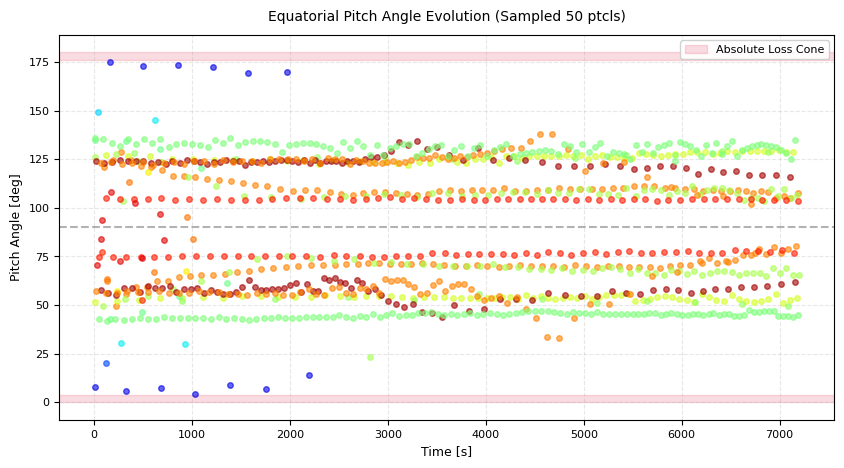

Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_Conservation.png


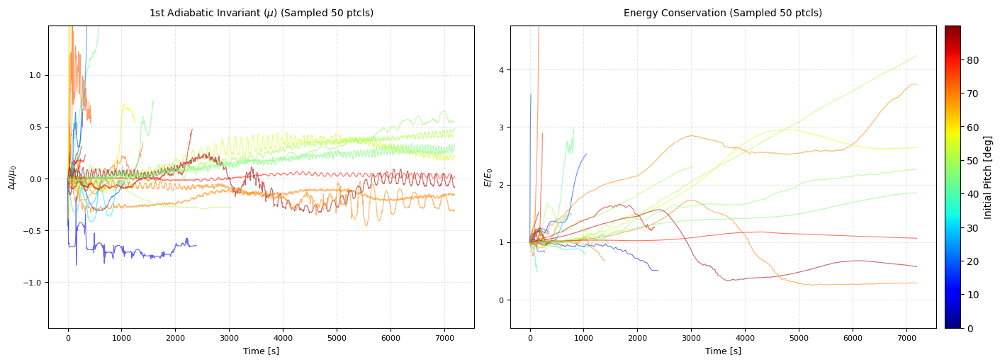

Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_Global_Trajectory.png


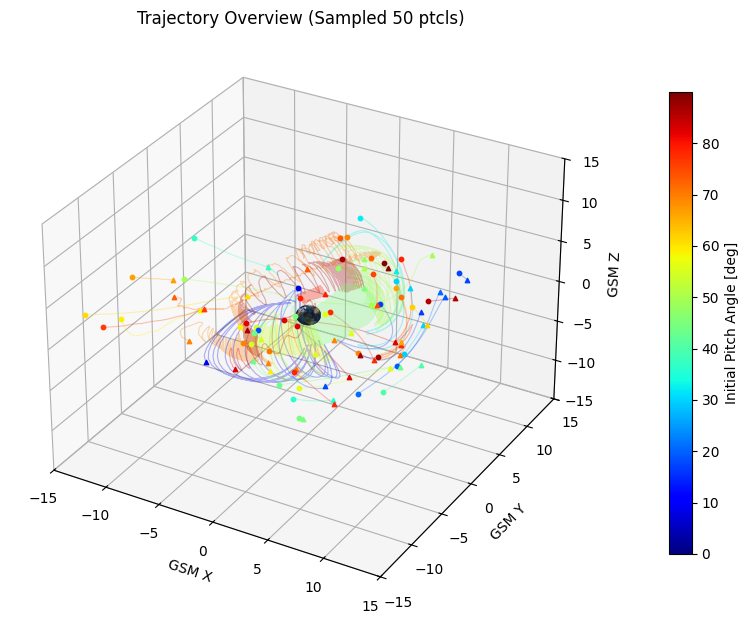

Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_Spherical_Components_Final.png


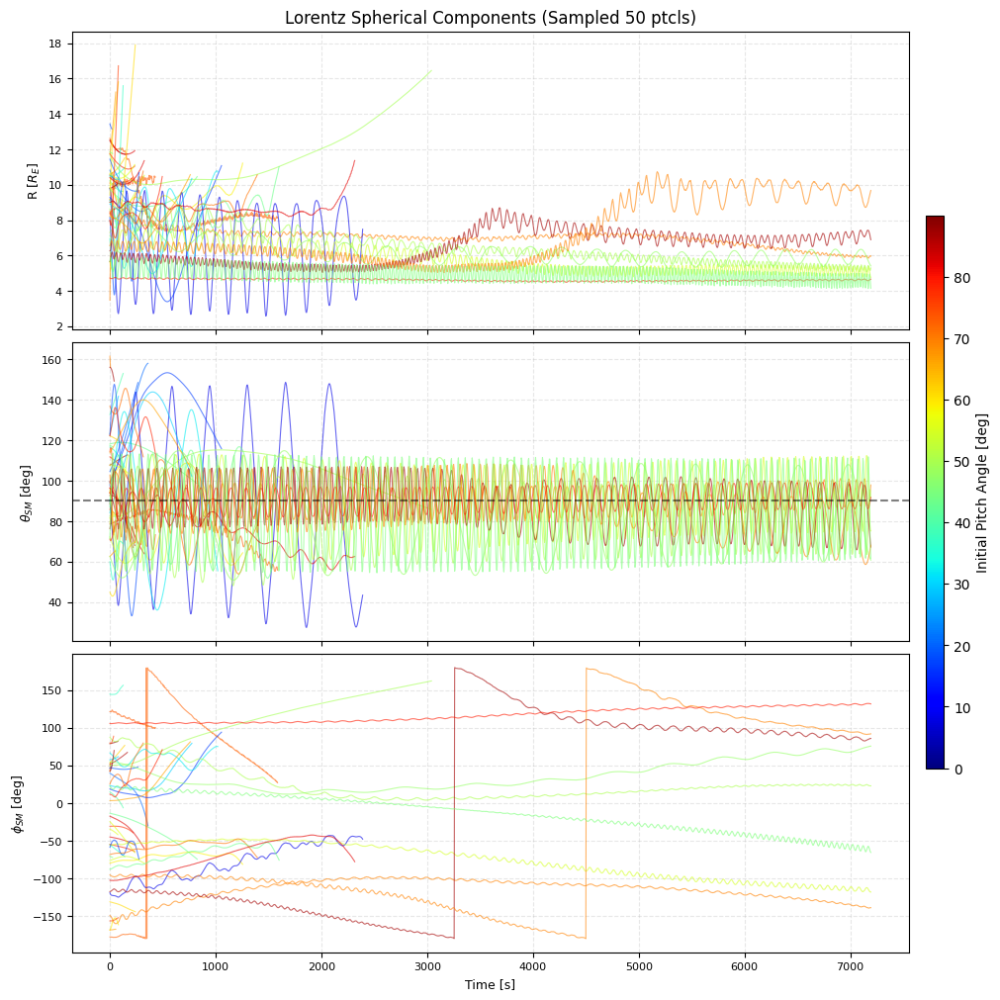

Rendering Zoomed Gyromotion (First 1440 steps)...
Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_Initial_Gyromotion_Zoom.png


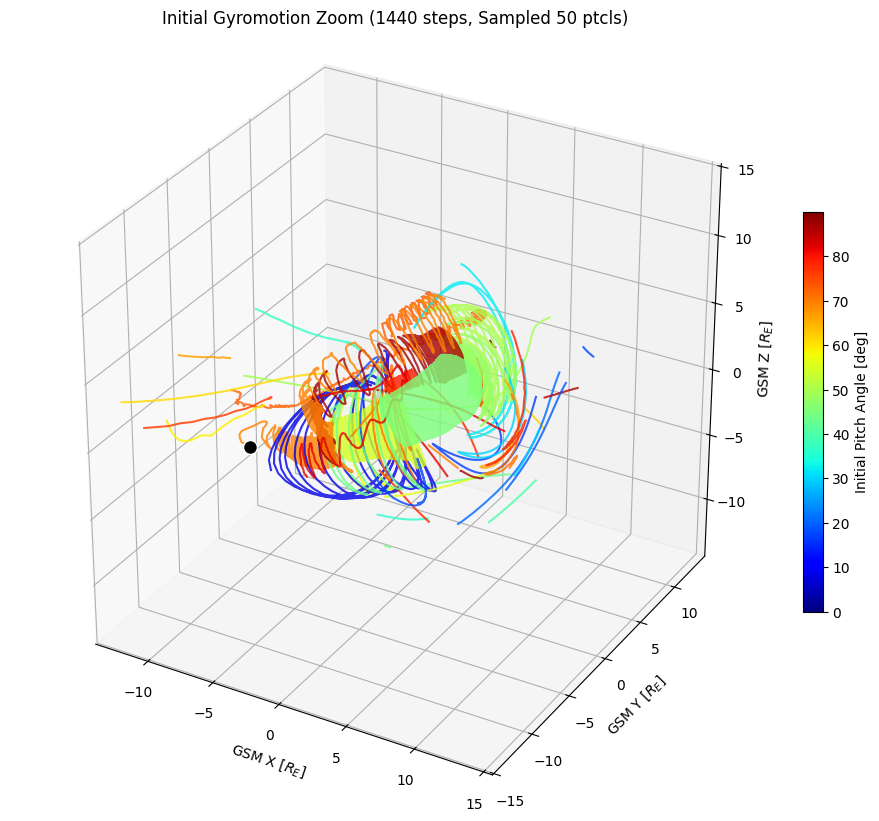

Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_E_Field_Cuts.png
Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_E_Field_Dominance_Map.png
Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_Bfield_XZ_Topology.png


Extracting E-field: 100%|██████████| 40000/40000 [00:00<00:00, 119593.29it/s]


Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_Efield_XY_Topology.png
Generating Density Evolution Plot...
Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_Lorentz_Density.png


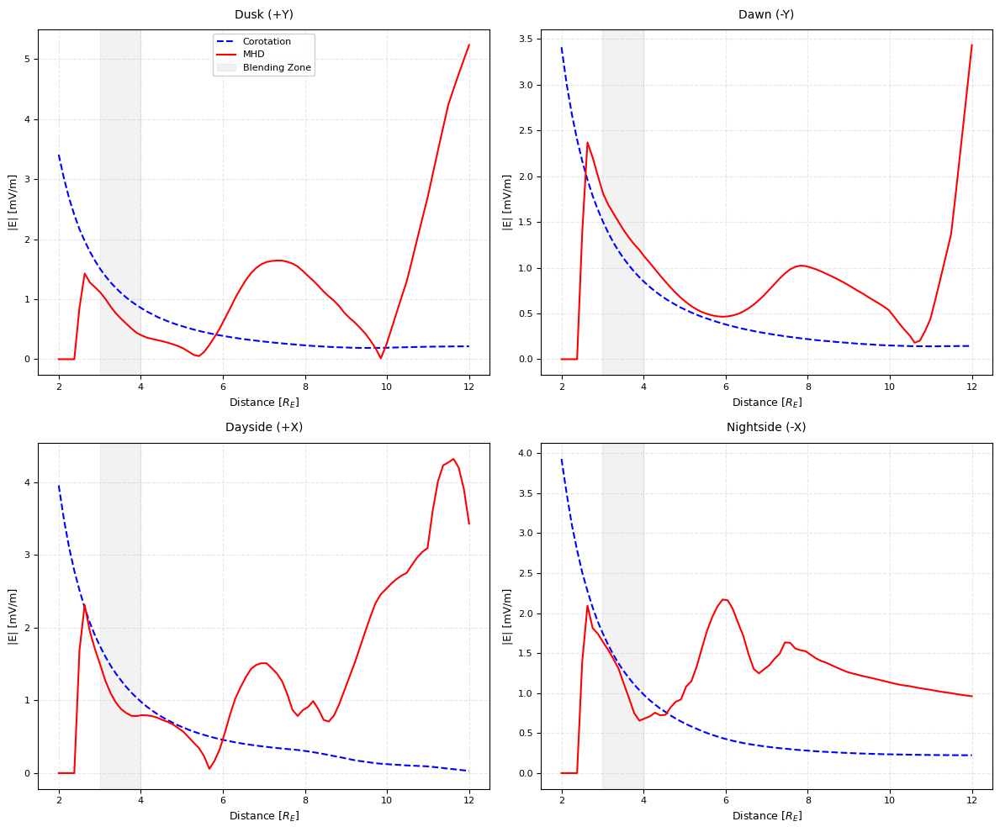

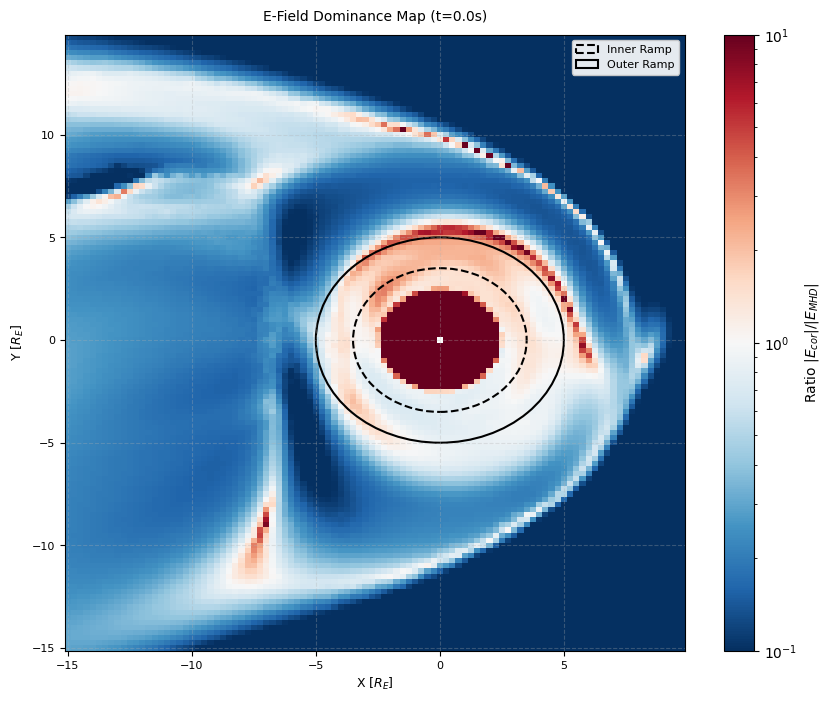

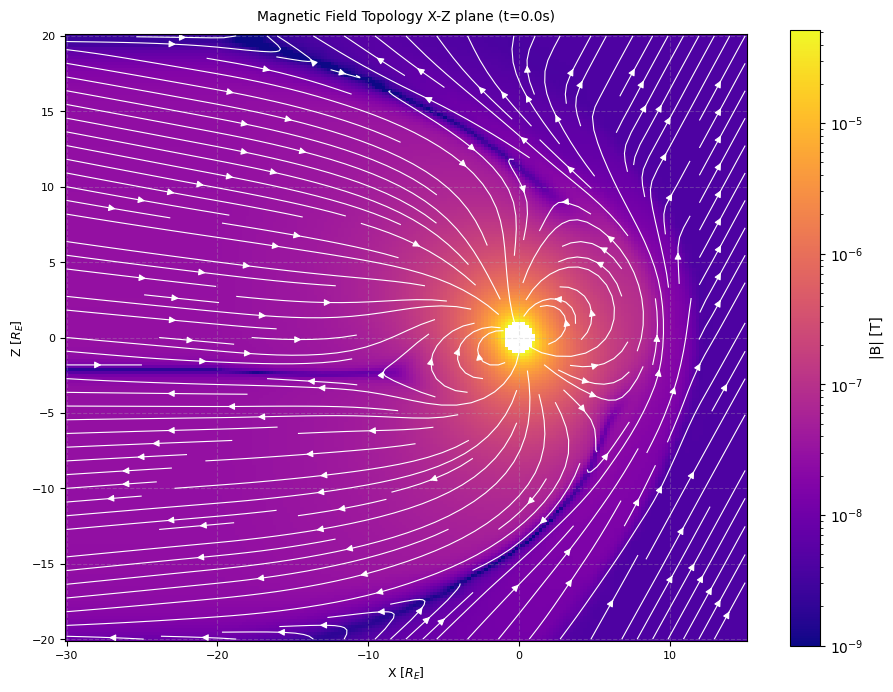

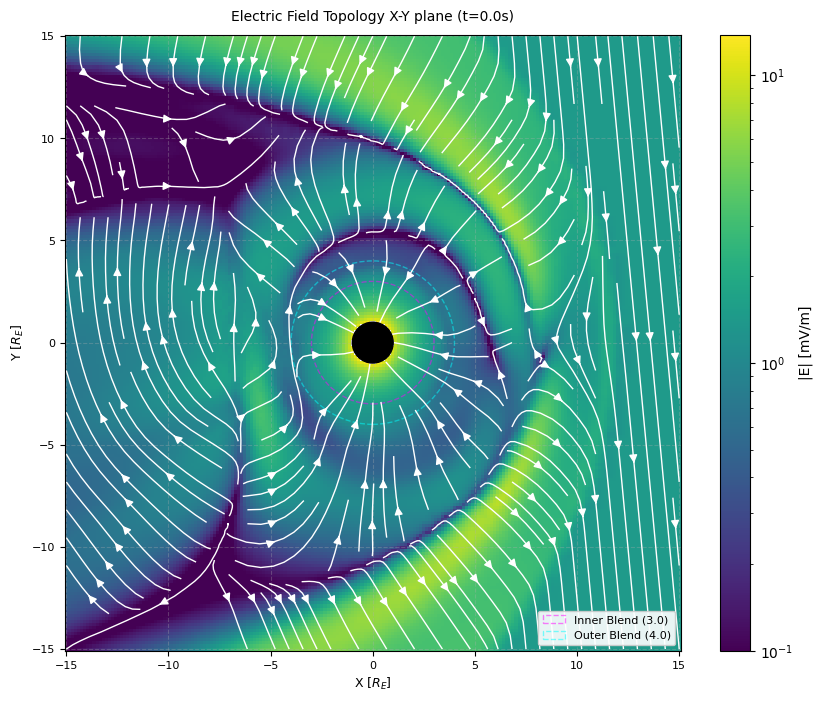



Generating 4-Panel Diagnostics from stored history...
Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_Global_4Panel_Diagnostics.png


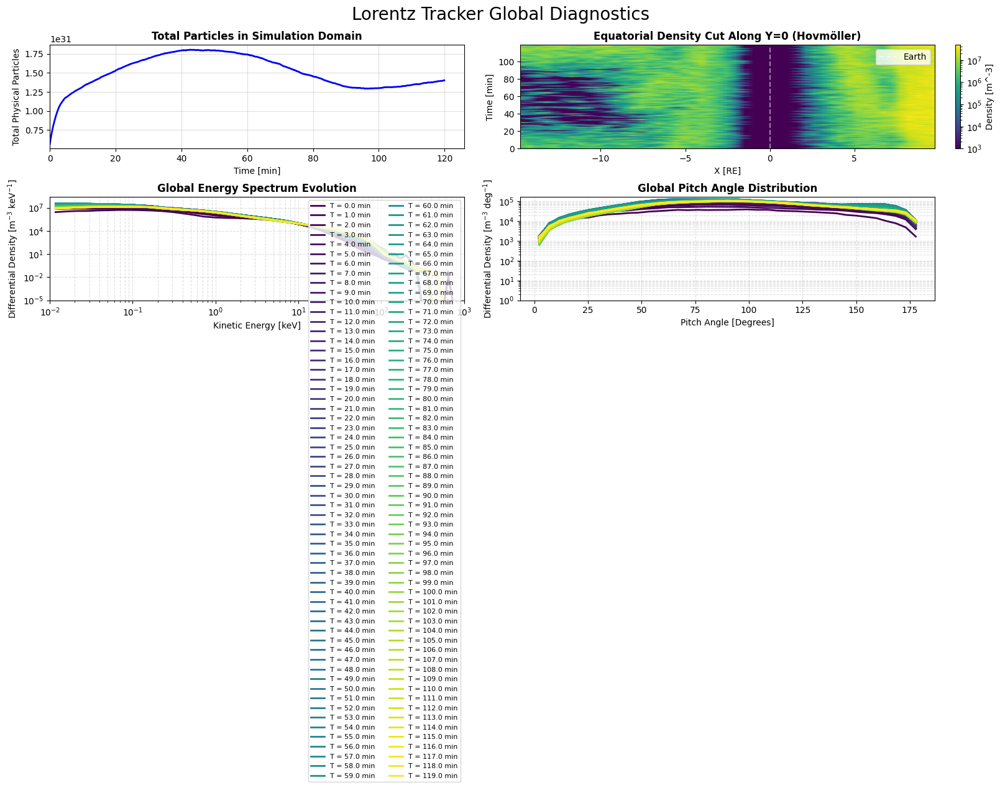

>> Median initial-Kappa fraction of all 90-keV flux: 0.9139937703230663
>> 90 keV gating (N_eff >= 5.0): 17 of 120 minutes have at least one reliable source.
--- Running GOES-18 Virtual Satellite Validation ---
Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_GOES18_Validation_Virtual_Sat_Flux.png


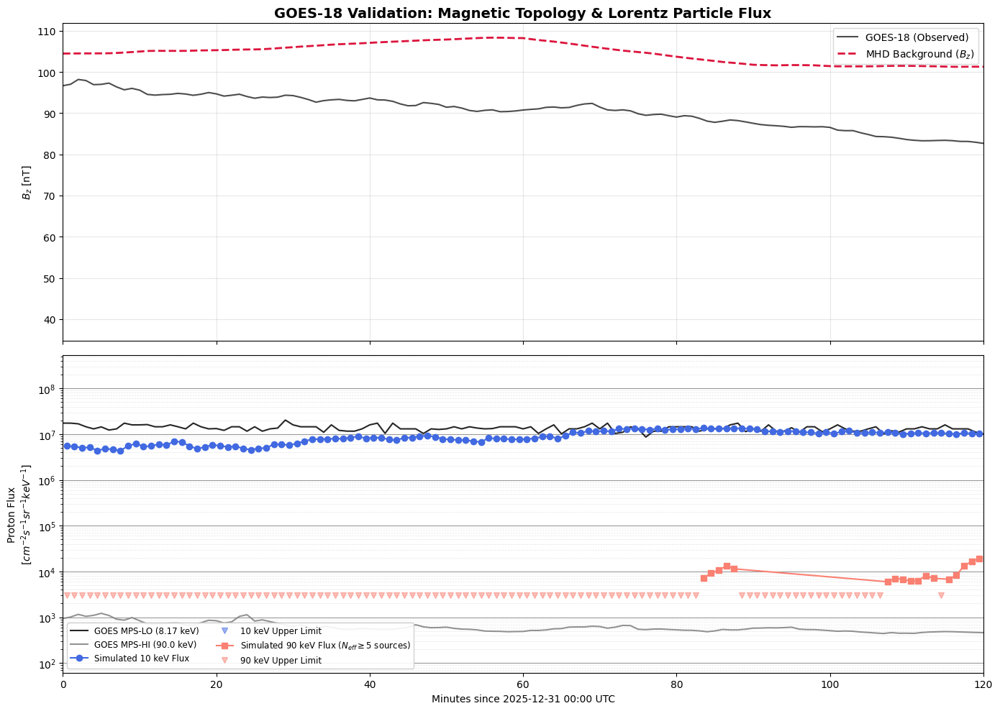

Saved: GIFs/FullLorentz/Run_20260928_103343/model_B_bz.csv
Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_GOES18_90keV_Statistical_Diagnostics.png


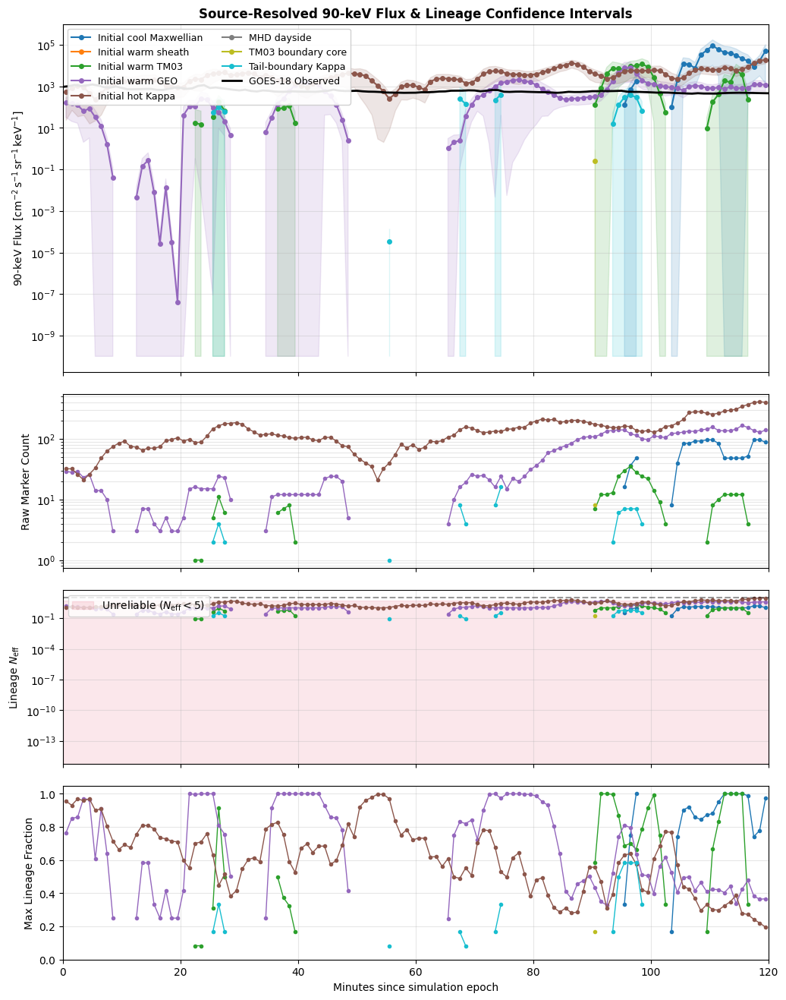

Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_GOES18_90keV_Source_Comparison_Paper.png


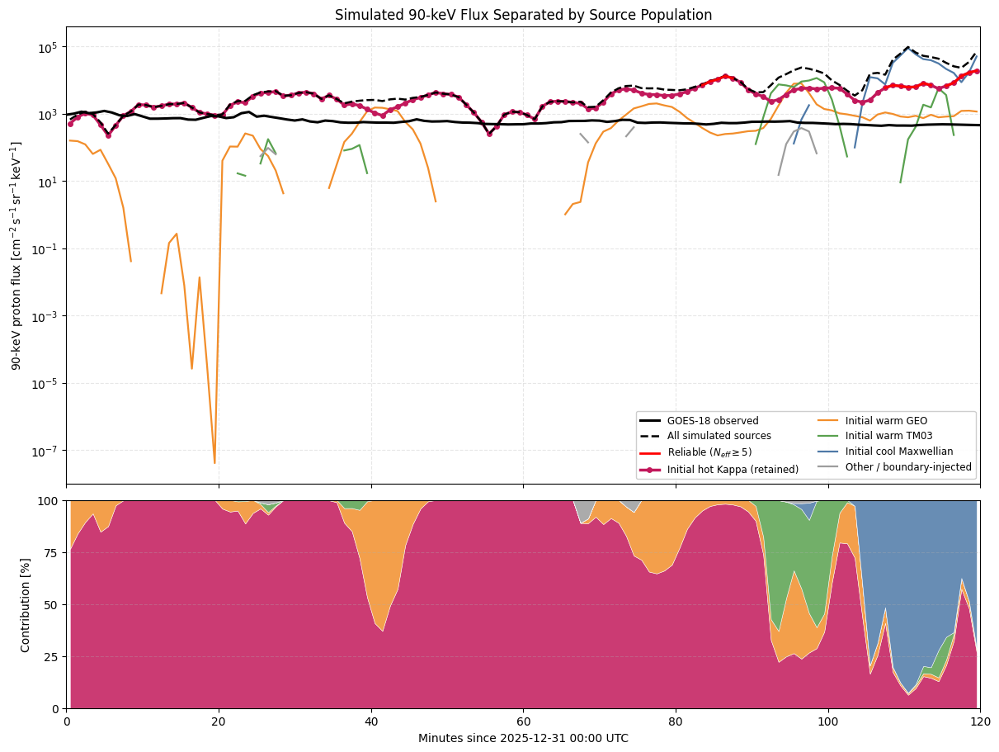

Saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_90keV_source_comparison.csv
>> Compiling final Lorentz simulation data for export...
>> Saving final Lorentz visualization data to GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_plot_data.pkl...
>> Final Lorentz pickle saved: GIFs/FullLorentz/Run_20260928_103343/ProtonSim_Lorentz_20260928_103343_plot_data.pkl
>> Pickle size: 11.25 MiB


In [2]:
# 1. HARDWARE CONFIGURATION
set_num_threads(8) # Adjust to your core count

# 2. PHYSICAL CONSTANTS (Float32)
RE = np.float64(6.371e6)
q_e = np.float64(1.602e-19)
m_p = np.float64(1.6726219e-27)

X_MIN, X_MAX = -15.0 * RE, 10.0 * RE
Y_MIN, Y_MAX = -10.0 * RE, 10.0 * RE
Z_MIN, Z_MAX = -6.5 * RE, 6.5 * RE

# =============================================================================
# BLOCK 1: DATA LOADING & UNPACKING FOR NUMBA
# =============================================================================

print("Loading and Unpacking Interpolators for Numba...")
start_t = time.time()

try:
    # 1. Load MHD (4D: t, x, y, z)
    interps = joblib.load("Interpolators_4D_Float32.pkl")
    mhd_data = {
        'Bx': interps['Bx'].values.astype(np.float32),
        'By': interps['By'].values.astype(np.float32),
        'Bz': interps['Bz'].values.astype(np.float32),
        'Vx': interps['Vx'].values.astype(np.float32),
        'Vy': interps['Vy'].values.astype(np.float32),
        'Vz': interps['Vz'].values.astype(np.float32),
        'n_bnd': interps['n_bnd'].values.astype(np.float32),     # <-- ADD THIS
        'kT_bnd': interps['kT_bnd'].values.astype(np.float32)    # <-- ADD THIS
    }
    
    # Extract 4D Grids
    grid_t = interps['Bx'].grid[0].astype(np.float32)
    grid_x = interps['Bx'].grid[1].astype(np.float32)
    grid_y = interps['Bx'].grid[2].astype(np.float32)
    grid_z = interps['Bx'].grid[3].astype(np.float32)

    # 2. Load Tsyganenko Gap (3D: x, y, z)
    gap_interps = joblib.load("IGRF_Baked_Float32.pkl")
    gap_data = {
        'Bx': gap_interps['Bx'].values.astype(np.float32),
        'By': gap_interps['By'].values.astype(np.float32),
        'Bz': gap_interps['Bz'].values.astype(np.float32)
    }
    
    # Extract 3D Grids (Assuming they share the same spatial grids as MHD)
    gap_grid_x = gap_interps['Bx'].grid[0].astype(np.float32)
    gap_grid_y = gap_interps['Bx'].grid[1].astype(np.float32)
    gap_grid_z = gap_interps['Bx'].grid[2].astype(np.float32)

    print(f"Interpolators Ready ({time.time() - start_t:.1f}s).")

except FileNotFoundError as e:
    print(f"CRITICAL ERROR: Could not find data files. {e}")
    raise e

min_dx = np.min(np.diff(grid_x))
min_dy = np.min(np.diff(grid_y))
min_dz = np.min(np.diff(grid_z))

# The finest cell across the entire 3D domain
finest_mhd_cell = min(min_dx, min_dy, min_dz)

# Output Setup
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
base_name = f"ProtonSim_Lorentz_{run_id}"  # <--- Just add this line back in!
run_folder = os.path.join("GIFs/FullLorentz", f"Run_{run_id}")
os.makedirs(run_folder, exist_ok=True)
print(f"Outputs: {run_folder}")

# =============================================================================
# BLOCK 2: BROADBAND GOES SPECTRUM FITTER
# =============================================================================
# Ingests real-time/archival GOES-18 MPS-LO and MPS-HI observations, fitting a 
# multi-component energy distribution (2 Maxwellians + 1 Kappa) to initialize phase space.

def _get_goes_time_unix(h5_file):
    """Parses timestamps from GOES NetCDF/HDF5 variables, resolving epoch offset definitions."""
    if "time" not in h5_file: return None
    raw_time = np.array(h5_file["time"][:], dtype=np.float64)
    units = h5_file["time"].attrs.get("units", "")
    if isinstance(units, (bytes, np.bytes_)): units = units.decode("utf-8", errors="ignore")

    if "since" in units:
        try:
            parts = units.split("since")[-1].strip().split()
            base_dt = datetime.fromisoformat(f"{parts[0]}T{parts[1]}").replace(tzinfo=timezone.utc).timestamp()
            return base_dt + raw_time
        except Exception: pass

    # Heuristic resolution for common standard time reference epochs
    if np.nanmean(raw_time) > 1e9: return raw_time
    elif np.nanmean(raw_time) > 5e8: return raw_time + 946728000.0  # J2000 epoch offset
    else: return datetime(2025, 12, 31, 0, 0, 0, tzinfo=timezone.utc).timestamp() + raw_time

def maxwellian_differential_flux(E_keV, n_cm3, kT_keV):
    """Computes isotropic Maxwellian differential particle flux [cm^-2 s^-1 sr^-1 keV^-1]."""
    E_J, kT_J, n_m3 = np.asarray(E_keV, dtype=np.float64) * 1000.0 * q_e, kT_keV * 1000.0 * q_e, n_cm3 * 1.0e6
    f_v = n_m3 * (m_p / (2.0 * np.pi * kT_J))**1.5 * np.exp(-E_J / kT_J)
    flux = (2.0 * E_J / m_p**2) * f_v * 1.0e-4 * (1000.0 * q_e)
    return np.maximum(flux, 1.0e-300)

def kappa_differential_flux(E_keV, n_cm3, kT_keV, kappa):
    """Computes isotropic 3D Kappa differential particle flux (Vasyliunas 1968)."""
    E_J, kT_J, n_m3 = np.asarray(E_keV, dtype=np.float64) * 1000.0 * q_e, kT_keV * 1000.0 * q_e, n_cm3 * 1.0e6
    energy_scale = (kappa - 1.5) * kT_J
    log_norm = np.log(n_m3) + 1.5 * np.log(m_p / (2.0 * np.pi * energy_scale)) + gammaln(kappa + 1.0) - gammaln(kappa - 0.5)
    log_f = log_norm - (kappa + 1.0) * np.log1p(E_J / energy_scale)
    f_v = np.exp(np.clip(log_f, -745.0, 700.0))
    flux = (2.0 * E_J / m_p**2) * f_v * 1.0e-4 * (1000.0 * q_e)
    return np.maximum(flux, 1.0e-300)

def three_population_flux(E_keV, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa):
    """Superposes Cool Maxwellian + Warm Maxwellian + Hot Kappa spectral components."""
    return (maxwellian_differential_flux(E_keV, n_cool, kT_cool) + maxwellian_differential_flux(E_keV, n_warm, kT_warm) + kappa_differential_flux(E_keV, n_hot, kT_hot, kappa))

# Reference channel energy window for GOES-18 90-keV comparison band
E90_BAND_KEV = np.linspace(72.0, 108.0, 73)
MAX_INITIAL_NONHOT_90_FRACTION = np.float64(0.01)
NONHOT_90_PENALTY_STRENGTH = np.float64(40.0)

def fit_goes_initial_spectrum_3pop(t_target_unix, mpsh_path=None, mpsl_path=None):
    """Fits satellite broadband observational data to a 3-population mixture via non-linear least squares."""
    e_lo_list, flux_lo_list, e_hi_list, flux_hi_list = [], [], [], []

    # Process GOES Low-Energy Ion Sensor (MPS-LO, ~30 eV to ~40 keV)
    if mpsl_path and os.path.exists(mpsl_path):
        try:
            with h5py.File(mpsl_path, "r") as h5_l:
                t_mpsl = _get_goes_time_unix(h5_l)
                if t_mpsl is None: t_mpsl = np.array([t_target_unix], dtype=np.float64)
                
                t_idx = int(np.argmin(np.abs(t_mpsl - t_target_unix)))
                i0, i1 = max(0, t_idx - 3), min(len(t_mpsl), t_idx + 4)
                flux_key = "DiffIonFluxes" if "DiffIonFluxes" in h5_l else "AvgDiffIonFlux"
                raw = np.asarray(h5_l[flux_key][i0:i1], dtype=np.float64)
                raw[raw <= 0.0] = np.nan

                if raw.ndim == 3: channel_flux = np.nanmedian(np.nanmax(raw, axis=1), axis=0)
                elif raw.ndim == 2: channel_flux = np.nanmedian(raw, axis=0)
                else: channel_flux = np.ravel(raw)
                
                n_channels = len(channel_flux)
                if "energy" in h5_l: energy = np.asarray(h5_l["energy"][:], dtype=np.float64).squeeze()
                elif n_channels == 15: energy = np.array([0.03, 0.05, 0.08, 0.13, 0.22, 0.37, 0.62, 1.04, 1.74, 2.91, 4.88, 8.17, 13.7, 22.9, 38.4])
                elif n_channels == 14: energy = np.array([0.045, 0.075, 0.125, 0.21, 0.35, 0.58, 0.96, 1.6, 2.7, 4.4, 7.3, 12.1, 20.1, 33.3])
                else: energy = np.geomspace(0.04, 70.0, n_channels)
                
                e_lo_list, flux_lo_list = list(np.ravel(energy)), list(channel_flux)
                print(f">> MPS-LO: {len(e_lo_list)} usable channels")
        except Exception as exc: print(f">> MPS-LO ingestion warning: {exc}")

    # Process GOES High-Energy Proton Sensor (MPS-HI, ~80 keV to ~10 MeV)
    if mpsh_path and os.path.exists(mpsh_path):
        try:
            with h5py.File(mpsh_path, "r") as h5_h:
                t_mpsh = _get_goes_time_unix(h5_h)
                if t_mpsh is None: t_mpsh = np.array([t_target_unix], dtype=np.float64)

                t_idx = int(np.argmin(np.abs(t_mpsh - t_target_unix)))
                i0, i1 = max(0, t_idx - 3), min(len(t_mpsh), t_idx + 4)
                flux_key = "DiffProtonFluxes" if "DiffProtonFluxes" in h5_h else "AvgDiffProtonFlux"
                raw = np.asarray(h5_h[flux_key][i0:i1], dtype=np.float64)
                raw[raw <= 0.0] = np.nan

                if raw.ndim == 3: channel_flux = np.nanmedian(np.nanmax(raw, axis=1), axis=0)
                elif raw.ndim == 2: channel_flux = np.nanmedian(raw, axis=0)
                else: channel_flux = np.ravel(raw)
                
                n_channels = len(channel_flux)
                if "energy" in h5_h: energy = np.asarray(h5_h["energy"][:], dtype=np.float64).squeeze()
                elif n_channels == 11: energy = np.array([90.0, 135.0, 200.0, 280.0, 400.0, 580.0, 830.0, 1300.0, 2500.0, 5500.0, 12000.0])
                elif n_channels == 7: energy = np.array([80.0, 150.0, 280.0, 580.0, 1300.0, 2500.0, 8500.0])
                else: energy = np.geomspace(80.0, 10000.0, n_channels)
                
                e_hi_list, flux_hi_list = list(np.ravel(energy)), list(channel_flux)
                print(f">> MPS-HI: {len(e_hi_list)} usable channels")
        except Exception as exc: print(f">> MPS-HI ingestion warning: {exc}")

    # Combine both low- and high-energy spectra into a single array
    energy, flux = np.asarray(e_lo_list + e_hi_list, dtype=np.float64), np.asarray(flux_lo_list + flux_hi_list, dtype=np.float64)
    valid = np.isfinite(energy) & np.isfinite(flux) & (energy > 0.0) & (flux > 0.0)
    energy, flux = energy[valid], flux[valid]

    # Fallback to empirical baseline values if satellite data is unavailable or corrupted
    if len(energy) < 7:
        print(">> Insufficient GOES channels; using baseline 3-population model.")
        return (np.float64(1.0), np.float64(1.0), np.float64(0.4), np.float64(8.0), np.float64(0.02), np.float64(25.0), np.float64(4.5))

    order = np.argsort(energy)
    energy, flux, observed_log_flux = energy[order], flux[order], np.log10(flux[order])

    p0 = np.array([0.0, np.log10(1.0), -0.4, np.log10(8.0), -1.7, np.log10(25.0), 4.5])
    lower = np.array([-3.0, np.log10(0.05), -4.0, np.log10(2.0), -7.0, np.log10(8.0), 2.05])
    upper = np.array([2.0, np.log10(4.0), 1.5, np.log10(12.0), 0.0, np.log10(150.0), 15.0])

    # Balance weights between MPS-LO and MPS-HI channels
    is_hi = energy >= 70.0
    n_lo, n_hi = max(1, np.count_nonzero(~is_hi)), max(1, np.count_nonzero(is_hi))
    residual_weight = np.empty_like(energy)
    residual_weight[~is_hi], residual_weight[is_hi] = np.sqrt(0.5 / n_lo), np.sqrt(0.5 / n_hi)

    def unpack_parameters(p): return (10.0**p[0], 10.0**p[1], 10.0**p[2], 10.0**p[3], 10.0**p[4], 10.0**p[5], p[6])
    integrate_band = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

    def residual(p):
        """Calculates least-squares residuals with penalty functions enforcing physical temperature ordering."""
        n_cool_fit, T_cool_fit, n_warm_fit, T_warm_fit, n_hot_fit, T_hot_fit, kappa_fit = unpack_parameters(p)
        modeled_flux = three_population_flux(energy, n_cool_fit, T_cool_fit, n_warm_fit, T_warm_fit, n_hot_fit, T_hot_fit, kappa_fit)
        model_log_flux = np.log10(np.maximum(modeled_flux, 1.0e-300))
        fit_residual = residual_weight * (model_log_flux - observed_log_flux)

        cool_warm_penalty = 2.0 * max(0.0, np.log10((2.0 * T_cool_fit) / max(T_warm_fit, 1.0e-300)))
        warm_hot_penalty = 2.0 * max(0.0, np.log10((1.25 * T_warm_fit) / max(T_hot_fit, 1.0e-300)))
        
        j90_cool, j90_warm, j90_hot = maxwellian_differential_flux(E90_BAND_KEV, n_cool_fit, T_cool_fit), maxwellian_differential_flux(E90_BAND_KEV, n_warm_fit, T_warm_fit), kappa_differential_flux(E90_BAND_KEV, n_hot_fit, T_hot_fit, kappa_fit)
        I90_cool, I90_warm, I90_hot = integrate_band(j90_cool, E90_BAND_KEV), integrate_band(j90_warm, E90_BAND_KEV), integrate_band(j90_hot, E90_BAND_KEV)
        I90_total = max(I90_cool + I90_warm + I90_hot, 1.0e-300)
        nonhot_90_fraction = (I90_cool + I90_warm) / I90_total        
        nonhot_90_penalty = (NONHOT_90_PENALTY_STRENGTH * max(0.0, np.log10(max(nonhot_90_fraction, 1.0e-300) / MAX_INITIAL_NONHOT_90_FRACTION)))

        penalties = np.array([cool_warm_penalty, warm_hot_penalty, nonhot_90_penalty], dtype=np.float64)
        return np.concatenate((fit_residual, penalties))

    # Perform robust bounded non-linear regression using Soft-L1 loss
    result = least_squares(residual, p0, bounds=(lower, upper), loss="soft_l1", f_scale=0.08, max_nfev=30000)
    n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot = unpack_parameters(result.x)

    # Post-fit integration of fractional contributions in the 90 keV band
    j90_cool_fit, j90_warm_fit, j90_hot_fit = maxwellian_differential_flux(E90_BAND_KEV, n_cool, kT_cool), maxwellian_differential_flux(E90_BAND_KEV, n_warm, kT_warm), kappa_differential_flux(E90_BAND_KEV, n_hot, kT_hot, kappa_hot)
    I90_total_fit = max(integrate_band(j90_cool_fit, E90_BAND_KEV) + integrate_band(j90_warm_fit, E90_BAND_KEV) + integrate_band(j90_hot_fit, E90_BAND_KEV), 1.0e-300)
    cool_90_fraction_fit, warm_90_fraction_fit, hot_90_fraction_fit = integrate_band(j90_cool_fit, E90_BAND_KEV) / I90_total_fit, integrate_band(j90_warm_fit, E90_BAND_KEV) / I90_total_fit, integrate_band(j90_hot_fit, E90_BAND_KEV) / I90_total_fit

    print(">> Three-population GOES fit:")
    print(f"   Cool Maxwellian: n={n_cool:.5f} cm^-3, kT={kT_cool:.3f} keV")
    print(f"   Warm Maxwellian: n={n_warm:.5f} cm^-3, kT={kT_warm:.3f} keV")
    print(f"   Hot Kappa      : n={n_hot:.6f} cm^-3, kT={kT_hot:.3f} keV, kappa={kappa_hot:.3f}")
    print(f"   Fit cost={result.cost:.5e}, success={result.success}, status={result.status}")

    if not result.success: raise RuntimeError(f"The constrained GOES spectral fit did not converge: {result.message}")
    if warm_90_fraction_fit > 0.075: raise RuntimeError("Fitted warm Maxwellian contributes too much to the 90 keV band.")

    return tuple(np.float64(v) for v in (n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot))

# =============================================================================
# BLOCK 3: NUMBA INTERPOLATION & KINETIC PHYSICS ENGINE
# =============================================================================
@njit(fastmath=True)
def fast_scalar_4d(t, pos, gt, gx, gy, gz, data):
    """Evaluates a 4D scalar moment (e.g., plasma density or temperature) at (t, x, y, z)."""
    it, ix, iy, iz, td, xd, yd, zd = get_interp_weights_4d(t, pos, gt, gx, gy, gz)
    return apply_interp_4d(it, ix, iy, iz, td, xd, yd, zd, data)

@njit(fastmath=True)
def fast_norm(v):
    """Euclidean norm of a 3-vector optimized with fastmath flags."""
    return np.float64(np.sqrt(v[0]*v[0] + v[1]*v[1] + v[2]*v[2]))

@njit(fastmath=True)
def get_index_piecewise(val, grid):
    """Correct index search for arbitrary monotonic spatial grids. Safer than assuming identical origins."""
    idx = np.searchsorted(grid, val) - 1
    if idx < 0: return 0
    if idx > len(grid) - 2: return len(grid) - 2
    return idx

@njit(fastmath=True)
def get_interp_weights_4d(t, pos, t_grid, x_grid, y_grid, z_grid):
    """Calculates cell index offsets and normalized fractional distances (weights) in [0, 1] for 4D interpolation."""
    x, y, z = pos[0], pos[1], pos[2]
    it = max(0, min(np.searchsorted(t_grid, t) - 1, len(t_grid) - 2))
    ix, iy, iz = get_index_piecewise(x, x_grid), get_index_piecewise(y, y_grid), get_index_piecewise(z, z_grid)
    td = max(0.0, min(1.0, (t - t_grid[it]) / (t_grid[it+1] - t_grid[it])))
    xd = max(0.0, min(1.0, (x - x_grid[ix]) / (x_grid[ix+1] - x_grid[ix])))
    yd = max(0.0, min(1.0, (y - y_grid[iy]) / (y_grid[iy+1] - y_grid[iy])))
    zd = max(0.0, min(1.0, (z - z_grid[iz]) / (z_grid[iz+1] - z_grid[iz])))
    return it, ix, iy, iz, np.float64(td), np.float64(xd), np.float64(yd), np.float64(zd)

@njit(fastmath=True)
def apply_interp_4d(it, ix, iy, iz, td, xd, yd, zd, data):
    """Executes trilinear spatial interpolation at the bounding time slices, followed by linear interpolation across time."""
    omm_td, omm_xd, omm_yd, omm_zd = np.float64(1.0) - td, np.float64(1.0) - xd, np.float64(1.0) - yd, np.float64(1.0) - zd
    
    # Trilinear spatial interpolation at time index it
    c000, c010, c100, c110 = data[it, ix, iy, iz]*omm_zd + data[it, ix, iy, iz+1]*zd, data[it, ix, iy+1, iz]*omm_zd + data[it, ix, iy+1, iz+1]*zd, data[it, ix+1, iy, iz]*omm_zd + data[it, ix+1, iy, iz+1]*zd, data[it, ix+1, iy+1, iz]*omm_zd + data[it, ix+1, iy+1, iz+1]*zd
    val0 = (c000*omm_yd + c010*yd)*omm_xd + (c100*omm_yd + c110*yd)*xd
    
    # Trilinear spatial interpolation at time index it + 1
    c001, c011, c101, c111 = data[it+1, ix, iy, iz]*omm_zd + data[it+1, ix, iy, iz+1]*zd, data[it+1, ix, iy+1, iz]*omm_zd + data[it+1, ix, iy+1, iz+1]*zd, data[it+1, ix+1, iy, iz]*omm_zd + data[it+1, ix+1, iy, iz+1]*zd, data[it+1, ix+1, iy+1, iz]*omm_zd + data[it+1, ix+1, iy+1, iz+1]*zd
    val1 = (c001*omm_yd + c011*yd)*omm_xd + (c101*omm_yd + c111*yd)*xd
    return val0 * omm_td + val1 * td

@njit(fastmath=True)
def fast_vec_4d(t, pos, gt, gx, gy, gz, d_x, d_y, d_z):
    """Evaluates a 3D vector field (e.g., B or V) at an arbitrary 4D coordinate."""
    it, ix, iy, iz, td, xd, yd, zd = get_interp_weights_4d(t, pos, gt, gx, gy, gz)
    vx, vy, vz = apply_interp_4d(it, ix, iy, iz, td, xd, yd, zd, d_x), apply_interp_4d(it, ix, iy, iz, td, xd, yd, zd, d_y), apply_interp_4d(it, ix, iy, iz, td, xd, yd, zd, d_z)
    return vx, vy, vz 

@njit(fastmath=True)
def make_perpendicular_basis(b_hat):
    """Constructs an orthonormal right-handed basis (b_hat, e1, e2) aligned with local magnetic field vector."""
    ref_x, ref_y, ref_z = (0.0, 1.0, 0.0) if abs(b_hat[1]) < 0.9 else (1.0, 0.0, 0.0)
    e1_x, e1_y, e1_z = b_hat[1]*ref_z - b_hat[2]*ref_y, b_hat[2]*ref_x - b_hat[0]*ref_z, b_hat[0]*ref_y - b_hat[1]*ref_x
    e1_mag = math.sqrt(e1_x**2 + e1_y**2 + e1_z**2) + 1.0e-30
    e1_x, e1_y, e1_z = e1_x / e1_mag, e1_y / e1_mag, e1_z / e1_mag

    # e2 = b_hat x e1
    e2_x, e2_y, e2_z = b_hat[1]*e1_z - b_hat[2]*e1_y, b_hat[2]*e1_x - b_hat[0]*e1_z, b_hat[0]*e1_y - b_hat[1]*e1_x
    return e1_x, e1_y, e1_z, e2_x, e2_y, e2_z

@njit
def boris_push(vx, vy, vz, Ex, Ey, Ez, Bx, By, Bz, t_mag):
    """Boris Pusher algorithm. t_mag = 0.5*q*dt/m. A negative dt gives the exact reverse push."""
    vm_x, vm_y, vm_z = vx + Ex*t_mag, vy + Ey*t_mag, vz + Ez*t_mag
    bx, by, bz = Bx*t_mag, By*t_mag, Bz*t_mag
    s = 2.0 / (1.0 + bx*bx + by*by + bz*bz)
    sx, sy, sz = bx*s, by*s, bz*s
    vp_x, vp_y, vp_z = vm_x + (vm_y*bz - vm_z*by), vm_y + (vm_z*bx - vm_x*bz), vm_z + (vm_x*by - vm_y*bx)
    vpl_x, vpl_y, vpl_z = vm_x + (vp_y*sz - vp_z*sy), vm_y + (vp_z*sx - vp_x*sz), vm_z + (vp_x*sy - vp_y*sx)
    return vpl_x + Ex*t_mag, vpl_y + Ey*t_mag, vpl_z + Ez*t_mag

@njit
def sample_common_boundary_velocity(v_th_selected, is_kappa, kappa_value, vx_bulk, vy_bulk, vz_bulk, E, B):
    """Draws a physical 3D particle velocity vector at injection boundaries."""
    Bmag = math.sqrt(B[0]**2 + B[1]**2 + B[2]**2) + 1.0e-30
    b_hat = (B[0] / Bmag, B[1] / Bmag, B[2] / Bmag)
    e1_x, e1_y, e1_z, e2_x, e2_y, e2_z = make_perpendicular_basis(b_hat)

    # Convective ExB drift velocity
    B_sq_inv = 1.0 / (Bmag * Bmag)
    v_exb_x, v_exb_y, v_exb_z = (E[1] * B[2] - E[2] * B[1]) * B_sq_inv, (E[2] * B[0] - E[0] * B[2]) * B_sq_inv, (E[0] * B[1] - E[1] * B[0]) * B_sq_inv
    v_parallel_bulk = (vx_bulk * b_hat[0] + vy_bulk * b_hat[1] + vz_bulk * b_hat[2])

    # Box-Muller transform
    u1, u2, u3, u4 = max(1.0e-15, np.random.random()), np.random.random(), max(1.0e-15, np.random.random()), np.random.random()
    gaussian_parallel = math.sqrt(-2.0 * math.log(u1)) * math.cos(2.0 * math.pi * u2)
    gaussian_perp_1 = math.sqrt(-2.0 * math.log(u3)) * math.cos(2.0 * math.pi * u4)
    gaussian_perp_2 = math.sqrt(-2.0 * math.log(u3)) * math.sin(2.0 * math.pi * u4)

    kappa_scale = math.sqrt((kappa_value - 1.5) / max(np.random.gamma(kappa_value - 0.5, 1.0), 1.0e-12)) if is_kappa else 1.0
    v_parallel = v_parallel_bulk + v_th_selected * kappa_scale * gaussian_parallel
    v_perp_1, v_perp_2 = v_th_selected * kappa_scale * gaussian_perp_1, v_th_selected * kappa_scale * gaussian_perp_2

    v_perp_x, v_perp_y, v_perp_z = v_perp_1 * e1_x + v_perp_2 * e2_x, v_perp_1 * e1_y + v_perp_2 * e2_y, v_perp_1 * e1_z + v_perp_2 * e2_z
    v_particle_x, v_particle_y, v_particle_z = v_parallel * b_hat[0] + v_perp_x + v_exb_x, v_parallel * b_hat[1] + v_perp_y + v_exb_y, v_parallel * b_hat[2] + v_perp_z + v_exb_z
    return (v_parallel, v_perp_1, v_perp_2, v_particle_x, v_particle_y, v_particle_z, e1_x, e1_y, e1_z, e2_x, e2_y, e2_z, v_exb_x, v_exb_y, v_exb_z)

@njit(fastmath=True)
def guiding_center_from_particle(particle_position, v_perp_1, v_perp_2, b_hat, e1, e2, Bmag, mass, charge):
    """Transforms a true physical particle coordinate into its guiding center position: R_gc = r_particle + rho_c"""
    v_perp_x, v_perp_y, v_perp_z = v_perp_1 * e1[0] + v_perp_2 * e2[0], v_perp_1 * e1[1] + v_perp_2 * e2[1], v_perp_1 * e1[2] + v_perp_2 * e2[2]
    cross_x, cross_y, cross_z = v_perp_y * b_hat[2] - v_perp_z * b_hat[1], v_perp_z * b_hat[0] - v_perp_x * b_hat[2], v_perp_x * b_hat[1] - v_perp_y * b_hat[0]
    rho_scale = mass / (charge * Bmag + 1.0e-30)
    return (particle_position[0] + rho_scale * cross_x, particle_position[1] + rho_scale * cross_y, particle_position[2] + rho_scale * cross_z)

@njit(fastmath=True)
def position_strictly_inside_box(pos):
    """Checks whether a coordinate lies strictly within the simulation domain bounds."""
    return (pos[0] > X_MIN and pos[0] < X_MAX and pos[1] > Y_MIN and pos[1] < Y_MAX and pos[2] > Z_MIN and pos[2] < Z_MAX)

@njit(parallel=True)   # fastmath off: it lets LLVM reassociate the rotation arithmetic safely
def advance_particles_block_lorentz(
    t_start, n_substeps, dt_eff, x_p, v_p, active_mask, z_dip_prev, q, m, R_lim_sq, bounds_x, bounds_y, bounds_z, M_vec_gsm,
    freeze_fields, use_loss_cone, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm
):
    """Sub-cycles all active particles by n_substeps using the Boris pusher in parallel."""
    N_total, t_mag, dt_f, B0_iono, RE_m = len(active_mask), np.float64(0.5 * q * dt_eff / m), np.float64(dt_eff), np.float64(31000.0 * 1e-9), np.float64(6.371e6)

    for i in prange(N_total):
        if not active_mask[i]: continue

        for sub in range(n_substeps):
            t_curr = t_start if freeze_fields else max(0.0, t_start + sub * dt_f)
            pos_tup = (x_p[i, 0], x_p[i, 1], x_p[i, 2])

            E, B = get_fields_numba(t_curr, pos_tup, True, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
            v_new_x, v_new_y, v_new_z = boris_push(v_p[i, 0], v_p[i, 1], v_p[i, 2], E[0], E[1], E[2], B[0], B[1], B[2], t_mag)
            x_new_x, x_new_y, x_new_z = x_p[i, 0] + v_new_x * dt_f, x_p[i, 1] + v_new_y * dt_f, x_p[i, 2] + v_new_z * dt_f

            r_sq = x_new_x*x_new_x + x_new_y*x_new_y + x_new_z*x_new_z
            if (r_sq <= R_lim_sq or x_new_x < bounds_x[0] or x_new_x > bounds_x[1] or x_new_y < bounds_y[0] or x_new_y > bounds_y[1] or x_new_z < bounds_z[0] or x_new_z > bounds_z[1]):
                active_mask[i] = False
                break

            # In-Flight Analytical Loss Cone Precipitation Check
            E_loss, B_loss = get_fields_numba(t_curr + dt_f, (x_new_x, x_new_y, x_new_z), True, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)

            B_loss_x, B_loss_y, B_loss_z = B_loss[0], B_loss[1], B_loss[2]
            Bmag_loss = math.sqrt(B_loss_x**2 + B_loss_y**2 + B_loss_z**2) + 1.0e-30
            b_loss_x, b_loss_y, b_loss_z = B_loss_x / Bmag_loss, B_loss_y / Bmag_loss, B_loss_z / Bmag_loss
            Bmag_loss_sq_inv = 1.0 / (Bmag_loss * Bmag_loss)

            v_exb_loss_x, v_exb_loss_y, v_exb_loss_z = (E_loss[1] * B_loss_z - E_loss[2] * B_loss_y) * Bmag_loss_sq_inv, (E_loss[2] * B_loss_x - E_loss[0] * B_loss_z) * Bmag_loss_sq_inv, (E_loss[0] * B_loss_y - E_loss[1] * B_loss_x) * Bmag_loss_sq_inv
            v_par_loss = (v_new_x * b_loss_x + v_new_y * b_loss_y + v_new_z * b_loss_z)
            v_pec_x, v_pec_y, v_pec_z = v_new_x - v_exb_loss_x, v_new_y - v_exb_loss_y, v_new_z - v_exb_loss_z
            v_pec_sq = (v_pec_x**2 + v_pec_y**2 + v_pec_z**2 + 1.0e-30)
            v_perp_sq = max(0.0, v_pec_sq - v_par_loss**2)
            sin2_alpha = v_perp_sq / v_pec_sq

            r_mag = math.sqrt(r_sq)
            z_mag = (x_new_x * M_vec_gsm[0] + x_new_y * M_vec_gsm[1] + x_new_z * M_vec_gsm[2])
            sin_lat_sq = min(0.999, (z_mag / r_mag) ** 2)
            L_eff = max(1.02, (r_mag / RE_m) / max(1.0e-6, 1.0 - sin_lat_sq))
            B_iono = (B0_iono * math.sqrt(4.0 - 3.0 / L_eff))

            if sin2_alpha <= Bmag_loss / B_iono:
                active_mask[i] = False
                break

            x_p[i, 0], x_p[i, 1], x_p[i, 2] = x_new_x, x_new_y, x_new_z
            v_p[i, 0], v_p[i, 1], v_p[i, 2] = v_new_x, v_new_y, v_new_z
            z_dip_prev[i] = x_new_x * M_vec_gsm[0] + x_new_y * M_vec_gsm[1] + x_new_z * M_vec_gsm[2]

# External solar wind driver parameters for T96 magnetic field model
T96_PARAM = [1.51442, 24, 4, 6, 0, 0, 0, 0, 0, 0]
PSI_RAD = 0.0 
R_IN, R_OUT = np.float64(3.0), np.float64(4.0)

@njit
def execute_boundary_injection_lorentz_constant_weight(
    t_inject, dt_inject, dt_eff, constant_weight, num_available_slots,
    gt, gx, gy, gz, N_sw, V_sw, Bz, n_core, kT_core, n_tail, kT_tail, kappa_geo, B_geo_ref,
    mhd_kT_bnd, mhd_n_bnd, mhd_Vx, mhd_Vy, mhd_Vz, mhd_Bx, mhd_By, mhd_Bz,
    gap_Bx, gap_By, gap_Bz, omega_earth_gsm, q_e, m_p, RE, start_lineage_id
):
    """Injects synthetic particle markers across the 6 domain boundaries using Monte Carlo rejection sampling."""
    A_x, A_y, A_z = (Y_MAX - Y_MIN) * (Z_MAX - Z_MIN), (X_MAX - X_MIN) * (Z_MAX - Z_MIN), (X_MAX - X_MIN) * (Y_MAX - Y_MIN)
    A_total = 2.0 * (A_x + A_y + A_z)
    p_x, p_y, p_z = A_x / A_total, A_y / A_total, A_z / A_total

    x_new, v_new, mu_new, alpha_new = np.zeros((num_available_slots, 3), dtype=np.float64), np.zeros((num_available_slots, 3), dtype=np.float64), np.zeros(num_available_slots, dtype=np.float64), np.zeros(num_available_slots, dtype=np.float64)
    w_mult_new, source_new, lineage_new = np.ones(num_available_slots, dtype=np.float64), np.full(num_available_slots, np.int8(-1), dtype=np.int8), np.zeros(num_available_slots, dtype=np.int64)
    W0_new, B0_new = np.zeros(num_available_slots, dtype=np.float64), np.zeros(num_available_slots, dtype=np.float64)

    accepted_count = 0
    n_max, vx_max = np.float64(100.0e6), np.float64(2.0e6)
    max_flux = n_max * vx_max
    max_physical_particles_in_dt = n_max * vx_max * A_total * dt_inject

    N_test_float = max_physical_particles_in_dt / constant_weight
    N_test_requested = int(N_test_float)
    if np.random.random() < (N_test_float - float(N_test_requested)): N_test_requested += 1

    N_test = min(N_test_requested, num_available_slots * 3)
    proposals_executed, slot_limited = 0, False
    proposal_weight_scale = N_test_float / float(N_test) if N_test > 0 else 0.0

    for _ in range(N_test):
        proposals_executed += 1
        if accepted_count >= num_available_slots:
            if proposals_executed <= N_test: slot_limited = True
            break

        face_roll = np.random.uniform(0.0, 1.0)
        face_id = np.int8(-1) 

        if face_roll < p_x:
            face_id = np.int8(0) 
            pos_test = (X_MIN, np.random.uniform(Y_MIN, Y_MAX), np.random.uniform(Z_MIN, Z_MAX))
            normal_in = (1.0, 0.0, 0.0)
        elif face_roll < 2.0 * p_x:
            face_id = np.int8(1) 
            pos_test = (X_MAX, np.random.uniform(Y_MIN, Y_MAX), np.random.uniform(Z_MIN, Z_MAX))
            normal_in = (-1.0, 0.0, 0.0)
        elif face_roll < 2.0 * p_x + p_y:
            face_id = np.int8(2) 
            pos_test = (np.random.uniform(X_MIN, X_MAX), Y_MIN, np.random.uniform(Z_MIN, Z_MAX))
            normal_in = (0.0, 1.0, 0.0)
        elif face_roll < 2.0 * p_x + 2.0 * p_y:
            face_id = np.int8(3) 
            pos_test = (np.random.uniform(X_MIN, X_MAX), Y_MAX, np.random.uniform(Z_MIN, Z_MAX))
            normal_in = (0.0, -1.0, 0.0)
        elif face_roll < 2.0 * p_x + 2.0 * p_y + p_z:
            face_id = np.int8(4) 
            pos_test = (np.random.uniform(X_MIN, X_MAX), np.random.uniform(Y_MIN, Y_MAX), Z_MIN)
            normal_in = (0.0, 0.0, 1.0)
        else:
            face_id = np.int8(5) 
            pos_test = (np.random.uniform(X_MIN, X_MAX), np.random.uniform(Y_MIN, Y_MAX), Z_MAX)
            normal_in = (0.0, 0.0, -1.0)

        E, B = get_fields_numba(t_inject, pos_test, True, gt, gx, gy, gz, mhd_Bx, mhd_By, mhd_Bz, mhd_Vx, mhd_Vy, mhd_Vz, gap_Bx, gap_By, gap_Bz, omega_earth_gsm)
        Bmag_loc = math.sqrt(B[0]**2 + B[1]**2 + B[2]**2) + 1e-30
        b_hat = (B[0] / Bmag_loc, B[1] / Bmag_loc, B[2] / Bmag_loc)
        adiabatic_ratio = min(1.0, Bmag_loc / B_geo_ref)

        it_4, ix_4, iy_4, iz_4, td_4, xd_4, yd_4, zd_4 = get_interp_weights_4d(t_inject, pos_test, gt, gx, gy, gz)
        vx_loc, vy_loc, vz_loc = apply_interp_4d(it_4, ix_4, iy_4, iz_4, td_4, xd_4, yd_4, zd_4, mhd_Vx) * 1e3, apply_interp_4d(it_4, ix_4, iy_4, iz_4, td_4, xd_4, yd_4, zd_4, mhd_Vy) * 1e3, apply_interp_4d(it_4, ix_4, iy_4, iz_4, td_4, xd_4, yd_4, zd_4, mhd_Vz) * 1e3
        mhd_n_loc, mhd_kT_loc = apply_interp_4d(it_4, ix_4, iy_4, iz_4, td_4, xd_4, yd_4, zd_4, mhd_n_bnd), apply_interp_4d(it_4, ix_4, iy_4, iz_4, td_4, xd_4, yd_4, zd_4, mhd_kT_bnd)

        if not math.isfinite(mhd_n_loc) or mhd_n_loc <= 0.0 or not math.isfinite(mhd_kT_loc) or mhd_kT_loc <= 0.0: continue

        v_bulk_inward = max(0.0, vx_loc * normal_in[0] + vy_loc * normal_in[1] + vz_loc * normal_in[2])
        x_re_test, y_re_test, z_re_test = pos_test[0] / RE, pos_test[1] / RE, pos_test[2] / RE
        v_th_sheath, v_th_core, v_th_tail = np.float64(0.0), np.float64(0.0), np.float64(0.0)

        if x_re_test > 9.9:
            n_sheath, kT_sheath = mhd_n_loc, mhd_kT_loc
            v_th_sheath = math.sqrt(kT_sheath / m_p)
            flux_sheath = n_sheath * max(v_bulk_inward, np.float64(0.4) * v_th_sheath)
            flux_core, flux_tail, flux_loc = np.float64(0.0), np.float64(0.0), flux_sheath
            p_sheath, p_core = np.float64(1.0), np.float64(0.0)
        else:
            _, kT_loc = get_tm03_proxy(x_re_test, y_re_test, N_sw, V_sw, Bz)
            z_decay = math.exp(-((z_re_test / np.float64(3.0)) ** 2))
            n_loc   = mhd_n_loc * z_decay
            v_th_core = math.sqrt(max(np.float64(1e-20), kT_loc) / m_p)
            flux_core = n_loc * max(v_bulk_inward, v_th_core * 0.4)

            allow_kappa = (face_id in (np.int8(0), np.int8(2), np.int8(3)) and x_re_test < 0.0 and abs(z_re_test) <= 3.0)
            if allow_kappa:
                kT_hot_tail = kT_tail * adiabatic_ratio * np.float64(1000.0) * q_e
                n_hot_tail = n_tail * 1e6 * (mhd_n_loc / max(n_core * 1e6, 1e-30)) * z_decay
                v_th_tail = math.sqrt(max(np.float64(1e-30), kT_hot_tail / m_p))
                flux_tail = n_hot_tail * max(v_bulk_inward, v_th_tail * 0.4)
            else:
                flux_tail, v_th_tail = np.float64(0.0), np.float64(0.0)

            flux_loc = flux_core + flux_tail
            p_sheath, p_core = np.float64(0.0), flux_core / (flux_loc + np.float64(1e-30))

        if not math.isfinite(flux_loc) or flux_loc <= 0.0 or flux_loc > max_flux: continue
        if np.random.uniform(0.0, max_flux) >= flux_loc: continue

        pop_roll = np.random.random()
        if pop_roll < p_sheath: v_th_selected, is_kappa, selected_source = v_th_sheath, False, SOURCE_MHD_DAYSIDE
        elif pop_roll < p_sheath + p_core: v_th_selected, is_kappa, selected_source = v_th_core, False, SOURCE_TM03_CORE
        else: v_th_selected, is_kappa, selected_source = v_th_tail, True, SOURCE_TAIL_KAPPA

        (v_par_rand, v_perp_1, v_perp_2, v_true_x, v_true_y, v_true_z, e1_x, e1_y, e1_z, e2_x, e2_y, e2_z, v_exb_x, v_exb_y, v_exb_z) = sample_common_boundary_velocity(v_th_selected, is_kappa, kappa_geo, vx_loc, vy_loc, vz_loc, E, B)

        v_ptcl_inward = (v_true_x * normal_in[0] + v_true_y * normal_in[1] + v_true_z * normal_in[2])
        if v_ptcl_inward <= 0.0: continue

        flux_weight = min(v_ptcl_inward / max(1.0e-5, v_bulk_inward + 0.5 * v_th_selected), 5.0)

        # Nudge particle slightly inward
        injection_inset = np.float64(1.0e-3) * RE
        x_particle_inside = (pos_test[0] + injection_inset * normal_in[0], pos_test[1] + injection_inset * normal_in[1], pos_test[2] + injection_inset * normal_in[2])
        x_gc_candidate = guiding_center_from_particle(x_particle_inside, v_perp_1, v_perp_2, b_hat, (e1_x, e1_y, e1_z), (e2_x, e2_y, e2_z), Bmag_loc, m_p, q_e)

        if not position_strictly_inside_box(x_gc_candidate): continue
        if (x_gc_candidate[0]**2 + x_gc_candidate[1]**2 + x_gc_candidate[2]**2) <= (2.0 * RE) ** 2: continue

        x_new[accepted_count, 0], x_new[accepted_count, 1], x_new[accepted_count, 2] = x_particle_inside[0], x_particle_inside[1], x_particle_inside[2]
        
        # Back-project velocity by -dt/2 for the staggered Boris leapfrog grid
        vb_x, vb_y, vb_z = boris_push(v_true_x, v_true_y, v_true_z, E[0], E[1], E[2], B[0], B[1], B[2], -0.25 * q_e * dt_eff / m_p)
        v_new[accepted_count, 0], v_new[accepted_count, 1], v_new[accepted_count, 2] = vb_x, vb_y, vb_z

        v_perp_sq_thermal = (v_perp_1**2 + v_perp_2**2)
        mu_new[accepted_count] = 0.5 * m_p * v_perp_sq_thermal / Bmag_loc
        alpha_new[accepted_count] = math.atan2(math.sqrt(v_perp_sq_thermal), abs(v_par_rand))

        w_mult_new[accepted_count] = flux_weight * proposal_weight_scale
        source_new[accepted_count] = selected_source
        lineage_new[accepted_count] = start_lineage_id + accepted_count

        W0_new[accepted_count] = 0.5 * m_p * (v_par_rand**2 + v_perp_sq_thermal)
        B0_new[accepted_count] = Bmag_loc
        accepted_count += 1

    return (accepted_count, x_new, v_new, mu_new, alpha_new, w_mult_new, source_new, lineage_new, W0_new, B0_new, N_test_float, N_test, proposal_weight_scale, slot_limited)

def get_ephemeris_params(time_input):
    """Computes Earth's spin axis vector and magnetic dipole axis in the GSM coordinate system."""
    d2r = np.pi / 180.0
    OMEGA_MAG = 7.2921159e-5  # Earth's angular rotation rate (rad/s)
    ut_timestamp = time_input.replace(tzinfo=timezone.utc).timestamp()
    geopack.recalc(ut_timestamp)
    global PSI_RAD
    PSI_RAD = geopack.psi 
    
    lat_rad, lon_rad = 79.6 * d2r, 280.6 * d2r
    M_geo, omega_geo = np.array([np.cos(lat_rad)*np.cos(lon_rad), np.cos(lat_rad)*np.sin(lon_rad), np.sin(lat_rad)]), np.array([0.0, 0.0, 1.0])

    y, m, d = time_input.year, time_input.month, time_input.day
    h_utc = time_input.hour + time_input.minute/60 + time_input.second/3600
    jd = 367*y - int(7*(y + int((m+9)/12))/4) + int(275*m/9) + d + 1721013.5 + h_utc/24
    T_0 = (jd - 2451545.0) / 36525.0

    L0 = (280.46646 + 36000.76983 * T_0) % 360
    M_anom = (357.52911 + 35999.05029 * T_0) % 360
    lambda_sun = (L0 + 1.914602 * np.sin(M_anom * d2r) + 0.019993 * np.sin(2 * M_anom * d2r)) * d2r
    epsilon = (23.439291 - 0.0130042 * T_0) * d2r
    S_gei = np.array([np.cos(lambda_sun), np.cos(epsilon)*np.sin(lambda_sun), np.sin(epsilon)*np.sin(lambda_sun)])

    theta_GST = (100.46061815 + 36000.77005361 * T_0 + 360.98564724 * (jd - 2451545.0)) % 360 
    th_rad = theta_GST * d2r
    cos_th, sin_th = np.cos(th_rad), np.sin(th_rad)
    S_geo = np.array([S_gei[0]*cos_th + S_gei[1]*sin_th, -S_gei[0]*sin_th + S_gei[1]*cos_th, S_gei[2]])
    S_geo /= np.sqrt(S_geo[0]**2 + S_geo[1]**2 + S_geo[2]**2)

    X_gsm = S_geo 
    Y_gsm = np.cross(M_geo, S_geo); Y_gsm /= np.sqrt(Y_gsm[0]**2 + Y_gsm[1]**2 + Y_gsm[2]**2)
    Z_gsm = np.cross(X_gsm, Y_gsm)
    basis_gsm = np.vstack([X_gsm, Y_gsm, Z_gsm])

    return OMEGA_MAG * (basis_gsm @ omega_geo), basis_gsm @ M_geo

def make_goes_telescope_vectors(sat_pos):
    """Generates the 6 directional pointing vectors for the GOES virtual telescopes."""
    r_vec = np.asarray(sat_pos, dtype=np.float64)
    r_mag = np.linalg.norm(r_vec) + 1.0e-30
    e_radial = r_vec / r_mag
    
    reference_north = np.array([0.0, 0.0, 1.0], dtype=np.float64)
    e_east = np.cross(reference_north, e_radial)
    east_mag = np.linalg.norm(e_east)
    
    if east_mag < 1.0e-12:
        reference_north = np.array([0.0, 1.0, 0.0], dtype=np.float64)
        e_east = np.cross(reference_north, e_radial)
        east_mag = np.linalg.norm(e_east)
        
    e_east /= east_mag
    e_north = np.cross(e_radial, e_east)
    e_north /= np.linalg.norm(e_north)
    return np.array([e_radial, -e_radial, e_east, -e_east, e_north, -e_north])

@njit(fastmath=True)
def get_volland_stern_E(pos, B_local, Kp):
    """Calculates the semi-empirical Volland-Stern cross-tail convection electric field (V/m)."""
    x, y, z = pos[0], pos[1], pos[2]
    r_sq_2d = x*x + y*y
    if r_sq_2d < 1e-10: return 0.0, 0.0, 0.0
        
    r_2d = np.sqrt(r_sq_2d)
    denom = 1.0 - 0.159 * Kp + 0.0093 * (Kp**2)
    A = 45.0 / (denom**3) 
    
    Ex, Ey, Ez = A * (x * y) / (RE**2 * r_2d), A * (x*x + 2.0 * y*y) / (RE**2 * r_2d), 0.0
    Bmag = np.sqrt(B_local[0]**2 + B_local[1]**2 + B_local[2]**2) + 1e-30
    bx, by, bz = B_local[0] / Bmag, B_local[1] / Bmag, B_local[2] / Bmag
    
    # Enforce ideal MHD condition (E . b_hat = 0)
    E_dot_b = Ex * bx + Ey * by + Ez * bz
    return np.float64(Ex - E_dot_b * bx), np.float64(Ey - E_dot_b * by), np.float64(Ez - E_dot_b * bz)

@njit(fastmath=True) 
def get_fields_numba(t, pos, calc_E, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """Synthesizes total electric and magnetic fields at an arbitrary coordinate. Smoothly blends analytical and outer MHD models."""
    r_sq = pos[0]*pos[0] + pos[1]*pos[1] + pos[2]*pos[2]
    r_mag = np.sqrt(r_sq)
    r_re = r_mag / 6.371e6
    
    bx, by, bz = fast_vec_4d(t, pos, gt, gx, gy, gz, mbx, mby, mbz)
    bx *= 1e-9; by *= 1e-9; bz *= 1e-9
    if not calc_E: return (0.0, 0.0, 0.0), (bx, by, bz)
    
    vx, vy, vz = fast_vec_4d(t, pos, gt, gx, gy, gz, mvx, mvy, mvz)
    vx *= 1e3; vy *= 1e3; vz *= 1e3
    
    Ex_mhd, Ey_mhd, Ez_mhd = by * vz - bz * vy, bz * vx - bx * vz, bx * vy - by * vx
    Ex_vs, Ey_vs, Ez_vs = get_volland_stern_E(pos, (bx, by, bz), np.float64(KP_INDEX))
    
    alpha_cor = max(0.0, min(1.0, (3.1855e7 - r_mag) / 9.5565e6))
    v_co_x, v_co_y, v_co_z = omega_earth_gsm[1]*pos[2] - omega_earth_gsm[2]*pos[1], omega_earth_gsm[2]*pos[0] - omega_earth_gsm[0]*pos[2], omega_earth_gsm[0]*pos[1] - omega_earth_gsm[1]*pos[0]
    
    Ex_inner, Ey_inner, Ez_inner = Ex_vs + alpha_cor * (by * v_co_z - bz * v_co_y), Ey_vs + alpha_cor * (bz * v_co_x - bx * v_co_z), Ez_vs + alpha_cor * (bx * v_co_y - by * v_co_x)

    if r_re <= R_IN:
        Ex, Ey, Ez = Ex_inner, Ey_inner, Ez_inner
    elif r_re >= R_OUT:
        Ex, Ey, Ez = Ex_mhd, Ey_mhd, Ez_mhd
    else:
        x = (r_re - R_IN) / (R_OUT - R_IN)
        w = x * x * (np.float64(3.0) - np.float64(2.0) * x)
        omm_w = 1.0 - w
        Ex, Ey, Ez = omm_w * Ex_inner + w * Ex_mhd, omm_w * Ey_inner + w * Ey_mhd, omm_w * Ez_inner + w * Ez_mhd
        
    return (Ex, Ey, Ez), (bx, by, bz)

@njit(fastmath=True)
def compute_gradients_numba(t, pos, delta_arr, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """Computes scalar magnitude gradient grad(|B|) using central finite differences."""
    dx, dy, dz = delta_arr[0], delta_arr[1], delta_arr[2]
    pos_px, pos_mx = (pos[0] + dx, pos[1], pos[2]), (pos[0] - dx, pos[1], pos[2])
    _, B_px = get_fields_numba(t, pos_px, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    _, B_mx = get_fields_numba(t, pos_mx, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    grad_x = (math.sqrt(B_px[0]**2 + B_px[1]**2 + B_px[2]**2) - math.sqrt(B_mx[0]**2 + B_mx[1]**2 + B_mx[2]**2)) / (2.0 * dx)
    
    pos_py, pos_my = (pos[0], pos[1] + dy, pos[2]), (pos[0], pos[1] - dy, pos[2])
    _, B_py = get_fields_numba(t, pos_py, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    _, B_my = get_fields_numba(t, pos_my, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    grad_y = (math.sqrt(B_py[0]**2 + B_py[1]**2 + B_py[2]**2) - math.sqrt(B_my[0]**2 + B_my[1]**2 + B_my[2]**2)) / (2.0 * dy)
    
    pos_pz, pos_mz = (pos[0], pos[1], pos[2] + dz), (pos[0], pos[1], pos[2] - dz)
    _, B_pz = get_fields_numba(t, pos_pz, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    _, B_mz = get_fields_numba(t, pos_mz, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    grad_z = (math.sqrt(B_pz[0]**2 + B_pz[1]**2 + B_pz[2]**2) - math.sqrt(B_mz[0]**2 + B_mz[1]**2 + B_mz[2]**2)) / (2.0 * dz)
    
    return (grad_x, grad_y, grad_z)

@njit(fastmath=True)
def trace_field_line_to_R_numba(t, x_start, R_target, ds, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """Traces a magnetic field line inward toward Earth from a given starting position."""
    x0, x1, x2 = x_start[0], x_start[1], x_start[2]
    R_sq, B_final = R_target**2, (0.0, 0.0, 0.0)
    
    for _ in range(1000): 
        if x0*x0 + x1*x1 + x2*x2 <= R_sq: break
        
        _, B = get_fields_numba(t, (x0, x1, x2), False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
        Bmag = math.sqrt(B[0]**2 + B[1]**2 + B[2]**2)
        bx, by, bz = B[0] / (Bmag + 1e-30), B[1] / (Bmag + 1e-30), B[2] / (Bmag + 1e-30)
        dot = x0*bx + x1*by + x2*bz
        sign = -1.0 if dot > 0 else 1.0  # Steer inward toward smaller radial distance
        x0 += sign * bx * ds; x1 += sign * by * ds; x2 += sign * bz * ds
        
    _, B_final = get_fields_numba(t, (x0, x1, x2), False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    return np.array([B_final[0], B_final[1], B_final[2]], dtype=np.float64)

@njit(parallel=True, fastmath=True)
def calculate_fields_batch(t, x_p, E_out, B_out, active_mask, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """Evaluates electric and magnetic field vectors across all active particles in parallel."""
    N_total = len(active_mask)
    for i in prange(N_total):
        if not active_mask[i]: continue 
        E, B = get_fields_numba(t, (x_p[i,0], x_p[i,1], x_p[i,2]), True, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
        E_out[i, 0], E_out[i, 1], E_out[i, 2] = E[0], E[1], E[2]
        B_out[i, 0], B_out[i, 1], B_out[i, 2] = B[0], B[1], B[2]

@njit(parallel=True, fastmath=True)
def get_initial_fields_batch(t, x_p, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """Batch-parallel wrapper to compute initial E and B fields across an ensemble of particle positions."""
    N = x_p.shape[0]
    E0, B0 = np.zeros((N, 3), dtype=np.float64), np.zeros((N, 3), dtype=np.float64)
    for i in prange(N):
        E, B = get_fields_numba(t, x_p[i], True, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
        E0[i, 0], E0[i, 1], E0[i, 2] = E[0], E[1], E[2]
        B0[i, 0], B0[i, 1], B0[i, 2] = B[0], B[1], B[2]
    return E0, B0

@njit(parallel=True, fastmath=True)
def calculate_epsilon_batch(t, x_p, v_p, B_full, active_mask, delta_array, q, m, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """Computes the adiabaticity parameter epsilon = rho_c / L_scale for all active particles."""
    N_total = len(active_mask)
    eps_arr = np.zeros(N_total, dtype=np.float64) 
    
    for i in prange(N_total):
        if not active_mask[i]: continue
        gradB = compute_gradients_numba(t, (x_p[i,0], x_p[i,1], x_p[i,2]), delta_array, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
        
        gradB_norm = math.sqrt(gradB[0]**2 + gradB[1]**2 + gradB[2]**2)
        Bmag = math.sqrt(B_full[i,0]**2 + B_full[i,1]**2 + B_full[i,2]**2)
        L_scale = Bmag / (gradB_norm + 1e-30)
        
        b_hat_x, b_hat_y, b_hat_z = B_full[i,0] / (Bmag + 1e-30), B_full[i,1] / (Bmag + 1e-30), B_full[i,2] / (Bmag + 1e-30)
        v_par_val = v_p[i,0]*b_hat_x + v_p[i,1]*b_hat_y + v_p[i,2]*b_hat_z
        v_sq = v_p[i,0]*v_p[i,0] + v_p[i,1]*v_p[i,1] + v_p[i,2]*v_p[i,2]
        v_perp_mag = math.sqrt(max(0.0, v_sq - v_par_val*v_par_val))
        
        rg = (m * v_perp_mag) / (abs(q) * Bmag + 1e-30)
        eps_arr[i] = rg / (L_scale + 1e-30)
    return eps_arr

@njit(fastmath=True)
def get_tm03_proxy(x_re, y_re, N_sw, V_sw, Bz):
    """Empirical proxy model (Tsyganenko & Mukai 2003) for plasma sheet proton density and temp."""
    r_mag = np.sqrt(x_re**2 + y_re**2)
    T_base = np.float64(1.5) * (V_sw / np.float64(400.0))**2 
    if Bz < 0.0: T_base *= np.float64(1.25)
        
    T_asy = np.float64(1.0) + np.float64(0.3) * (y_re / (r_mag + np.float64(1e-5))) 
    T_keV = min(T_base * T_asy, np.float64(12.0)) 
    
    N_base = np.float64(0.3) * N_sw
    N_spatial = N_base * (np.float64(1.0) - math.exp(np.float64(-0.2) * r_mag))
    N_flank = np.float64(1.0) + np.float64(0.5) * (abs(y_re) / (r_mag + np.float64(1e-5)))
    N_cm3 = N_spatial * N_flank
    
    return N_cm3 * 1e6, T_keV * 1000.0 * 1.602e-19

@njit
def split_high_weight_markers_lorentz(
    x_p, v_p, mu0, alphas, particle_weights, particle_time, particle_source,
    particle_generation, particle_lineage, active_mask, has_been_split, z_dip_prev,
    particle_W0, particle_B0, active_ids, available_ids, RE, r_capture_min, r_capture_max, z_capture_max,
    weight_boost_threshold, split_factor,
):
    """Adaptive Importance Splitting for full-orbit Lorentz particles."""
    n_free, free_ptr = available_ids.shape[0], 0

    for idx in range(active_ids.shape[0]):
        i = active_ids[idx]
        if has_been_split[i] or particle_weights[i] < weight_boost_threshold: continue

        r_xy = math.sqrt(x_p[i, 0]**2 + x_p[i, 1]**2) / RE
        z_re = abs(x_p[i, 2]) / RE
        if r_xy < r_capture_min or r_xy > r_capture_max or z_re > z_capture_max: continue

        k = split_factor
        if free_ptr + (k - 1) > n_free: k = (n_free - free_ptr) + 1
        if k < 2: break 

        new_weight = particle_weights[i] / k
        particle_weights[i] = new_weight
        has_been_split[i] = True

        for c in range(k - 1):
            slot = available_ids[free_ptr]
            free_ptr += 1

            x_p[slot, 0], x_p[slot, 1], x_p[slot, 2] = x_p[i, 0], x_p[i, 1], x_p[i, 2]
            v_p[slot, 0], v_p[slot, 1], v_p[slot, 2] = v_p[i, 0], v_p[i, 1], v_p[i, 2]
            
            mu0[slot], alphas[slot], z_dip_prev[slot] = mu0[i], alphas[i], z_dip_prev[i]

            particle_weights[slot]    = new_weight
            particle_time[slot]       = particle_time[i]
            particle_source[slot]     = particle_source[i]
            particle_generation[slot] = particle_generation[i] + 1
            particle_lineage[slot]    = particle_lineage[i] 
            
            particle_W0[slot], particle_B0[slot] = particle_W0[i], particle_B0[i]
            active_mask[slot], has_been_split[slot] = True, True

    return free_ptr

@njit(fastmath=True)
def populate_phase_space_empirical_3pop(
    N, x_min, x_max, y_min, y_max, Z_max, N_sw, V_sw, Bz,
    n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, RE, B_geo_ref, t,
    gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz,
    omega_earth_gsm, r_shell_min, r_shell_max, shell_mode,
):
    """Monte Carlo rejection sampler initializing 3D spatial marker distribution at t = 0."""
    valid_pos, valid_n_cool, valid_T_cool = np.zeros((N, 3), dtype=np.float64), np.zeros(N, dtype=np.float64), np.zeros(N, dtype=np.float64)
    valid_n_warm, valid_T_warm_geo, valid_T_warm_tm03, valid_T_warm_sheath = np.zeros(N, dtype=np.float64), np.zeros(N, dtype=np.float64), np.zeros(N, dtype=np.float64), np.zeros(N, dtype=np.float64)
    valid_n_hot, valid_T_hot = np.zeros(N, dtype=np.float64), np.zeros(N, dtype=np.float64)
    valid_warm_geo_fraction, valid_warm_tm03_fraction, valid_warm_sheath_fraction = np.zeros(N, dtype=np.float64), np.zeros(N, dtype=np.float64), np.zeros(N, dtype=np.float64)

    fitted_total_cm3 = n_cool + n_warm + n_hot
    max_sheath_limit, max_inner_limit, max_tail_proxy = 3.5 * N_sw, 2.0 * fitted_total_cm3, 2.0 * N_sw
    n_max_estimate = max(max_sheath_limit, max_inner_limit, max_tail_proxy) * 1.0e6
    count, attempts = 0, 0

    while count < N:
        attempts += 1
        x, y, z = np.random.uniform(x_min, x_max), np.random.uniform(y_min, y_max), np.random.uniform(-Z_max, Z_max)
        r_sq = x*x + y*y + z*z

        if r_sq < 2.5**2: continue
        r_xy = math.sqrt(x*x + y*y)
        if shell_mode == 1 and (r_xy < r_shell_min or r_xy > r_shell_max): continue
        elif shell_mode == -1 and (r_xy >= r_shell_min and r_xy <= r_shell_max): continue

        z_decay = math.exp(-((z / 3.0)**2))
        n_c_loc, T_c_loc, n_w_loc, n_h_loc, T_h_loc = 0.0, 0.0, 0.0, 0.0, 0.0
        n_w_tm03_component, n_w_geo_component, n_w_sheath_component = 0.0, 0.0, 0.0
        T_w_geo_val, T_w_tm03_val, T_w_sheath_val = 0.0, 0.0, 0.0

        if x < 0.0:
            n_tm03, T_tm03 = get_tm03_proxy(x, y, N_sw, V_sw, Bz)
            w_geo = math.exp(-((r_xy - 6.6)**2) / 8.0) if r_xy < 10.0 else 0.0

            n_c_loc, T_c_loc = n_cool * 1.0e6 * w_geo * z_decay, kT_cool * 1000.0 * q_e
            n_w_tm03_component, n_w_geo_component = n_tm03 * (1.0 - w_geo) * z_decay, n_warm * 1.0e6 * w_geo * z_decay
            n_w_loc = n_w_tm03_component + n_w_geo_component

            T_w_geo_val, T_w_tm03_val, T_w_sheath_val = kT_warm * 1000.0 * q_e, T_tm03, 0.0
            n_h_loc, T_h_loc = n_hot * 1.0e6 * w_geo * z_decay, kT_hot * 1000.0 * q_e

        elif x > 4.0 and r_xy > 8.0:
            v_sw_si = V_sw * 1000.0
            n_w_sheath_component = 3.5 * N_sw * 1.0e6 * z_decay
            n_w_loc = n_w_sheath_component
            T_w_geo_val, T_w_tm03_val, T_w_sheath_val = 0.0, 0.0, 0.18 * 0.5 * m_p * v_sw_si**2

        else:
            _, B_loc = get_fields_numba(t, (x * RE, y * RE, z * RE), False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
            Bmag_loc = fast_norm(B_loc) + 1.0e-30
            adiabatic_ratio, scale_vol = min(1.5, Bmag_loc / B_geo_ref), min(2.0, B_geo_ref / Bmag_loc)
            common_density_scale = scale_vol * z_decay

            n_c_loc, T_c_loc = n_cool * 1.0e6 * common_density_scale, kT_cool * adiabatic_ratio * 1000.0 * q_e
            n_w_geo_component = n_warm * 1.0e6 * common_density_scale
            n_w_loc = n_w_geo_component

            T_w_geo_val, T_w_tm03_val, T_w_sheath_val = kT_warm * adiabatic_ratio * 1000.0 * q_e, 0.0, 0.0
            n_h_loc, T_h_loc = n_hot * 1.0e6 * common_density_scale, kT_hot * adiabatic_ratio * 1000.0 * q_e

        n_total_loc = n_c_loc + n_w_loc + n_h_loc
        if n_total_loc <= 0.0 or n_total_loc > n_max_estimate: continue

        warm_component_sum = n_w_geo_component + n_w_tm03_component + n_w_sheath_component
        if warm_component_sum > 0.0:
            warm_geo_fraction, warm_tm03_fraction, warm_sheath_fraction = n_w_geo_component / warm_component_sum, n_w_tm03_component / warm_component_sum, n_w_sheath_component / warm_component_sum
        else:
            warm_geo_fraction, warm_tm03_fraction, warm_sheath_fraction = 0.0, 0.0, 0.0

        if np.random.uniform(0.0, n_max_estimate) < n_total_loc:
            valid_warm_geo_fraction[count], valid_warm_tm03_fraction[count], valid_warm_sheath_fraction[count] = warm_geo_fraction, warm_tm03_fraction, warm_sheath_fraction
            valid_pos[count, 0], valid_pos[count, 1], valid_pos[count, 2] = x, y, z
            valid_n_cool[count], valid_T_cool[count], valid_n_warm[count] = n_c_loc, T_c_loc, n_w_loc
            valid_T_warm_geo[count], valid_T_warm_tm03[count], valid_T_warm_sheath[count] = T_w_geo_val, T_w_tm03_val, T_w_sheath_val
            valid_n_hot[count], valid_T_hot[count] = n_h_loc, T_h_loc
            count += 1

    return (valid_pos, valid_n_cool, valid_T_cool, valid_n_warm, valid_T_warm_geo, valid_T_warm_tm03, valid_T_warm_sheath, valid_n_hot, valid_T_hot, valid_warm_geo_fraction, valid_warm_tm03_fraction, valid_warm_sheath_fraction, attempts, n_max_estimate)

# =============================================================================
# BLOCK 4: INITIALIZATION (Constants, Fits & Phase Space)
# =============================================================================
sim_start_time = datetime(2025, 12, 31, 0, 0, 0)
np.random.seed(110) 
omega_earth_gsm, M_vec_gsm = get_ephemeris_params(sim_start_time)
R_inner_limit = np.float64(2.0 * RE)
coords = [BATSRUS[ax].astype(np.float64) * RE for ax in 'xyz']
delta_array = np.array([np.median(np.diff(np.unique(c))) for c in coords], dtype=np.float64) * 0.25
KP_INDEX = 2.0 

N_INITIAL_ACTIVE = 1000000
N_MAX_CAPACITY = 5 * N_INITIAL_ACTIVE    # Allocate headroom buffer for boundary-injected & split particles
N_particles = N_MAX_CAPACITY
MAX_SIM_TIME = 7200.0   # 2 hours physical duration (seconds)
SPINUP_TIME = 0.0 
current_t = 0.0

# Marker population provenance tracking IDs
SOURCE_INITIAL_COOL          = np.int8(0)
SOURCE_INITIAL_WARM_SHEATH   = np.int8(1)
SOURCE_INITIAL_WARM_TM03     = np.int8(2)
SOURCE_INITIAL_WARM_GEO      = np.int8(3)
SOURCE_INITIAL_KAPPA         = np.int8(4)
SOURCE_MHD_DAYSIDE           = np.int8(5)
SOURCE_TM03_CORE             = np.int8(6)
SOURCE_TAIL_KAPPA            = np.int8(7)

SOURCE_NAMES = ("Initial cool Maxwellian", "Initial warm sheath", "Initial warm TM03", "Initial warm GEO", "Initial hot Kappa", "MHD dayside", "TM03 boundary core", "Tail-boundary Kappa")
N_SOURCES = len(SOURCE_NAMES)
INITIAL_WARM_SOURCE_IDS = np.array([SOURCE_INITIAL_WARM_SHEATH, SOURCE_INITIAL_WARM_TM03, SOURCE_INITIAL_WARM_GEO], dtype=np.int8)
particle_source = np.full(N_particles, np.int8(-1), dtype=np.int8)

sim_start_unix = sim_start_time.replace(tzinfo=timezone.utc).timestamp()
t_assimilation = sim_start_unix

mpsh_file = "goes_data/goes18/l2/data/mpsh-l2-avg1m/2025/12/sci_mpsh-l2-avg1m_g18_d20251231_v2-0-2.nc"
mpsl_file = "goes_data/goes18/l2/data/mpsl-l2-avg1m/2025/12/ops_seis-l1b-mpsl_g18_d20251231_v0-0-0.nc"
mag_file = "goes_data/goes18/l2/data/magn-l2-avg1m/2025/12/dn_magn-l2-avg1m_g18_d20251231_v2-0-4.nc"

# Calibrate initial phase-space distribution using observational GOES spectra
n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot = fit_goes_initial_spectrum_3pop(t_assimilation, mpsh_path=mpsh_file, mpsl_path=mpsl_file)
n_goes_total = n_cool + n_warm + n_hot
print(f">> Total fitted GEO proton density: {n_goes_total:.6f} cm^-3")

# Multi-region Probe for Empirical vs. MHD Comparison
try:
    probe_locations = {"Nightside GEO": (-6.6, 0.0, 0.0), "Magnetotail": (-12.0, 0.0, 0.0), "Solar Wind": (9.5, 0.0, 0.0)}
    N_sw_in, V_sw_in, Bz_in = np.float64(5.36), np.float64(411.0), np.float64(T96_PARAM[3])
    
    print("\n" + "="*80)
    print("📊 MULTI-REGION COMPARISON: EMPIRICAL PROXY VS RAW MHD")
    print("="*80)
    B_geo_ref = np.float64(100.0e-9)
    
    for region, pos_re in probe_locations.items():
        pos_m = (np.float64(pos_re[0] * RE), np.float64(pos_re[1] * RE), np.float64(pos_re[2] * RE))
        _, B_model = get_fields_numba(np.float64(0.0), pos_m, False, grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)
        B_mag_nT = np.sqrt(B_model[0]**2 + B_model[1]**2 + B_model[2]**2) * 1e9
        if region == "Nightside GEO": B_geo_ref = np.float64(B_mag_nT * 1e-9)
        
        mhd_n_si = fast_scalar_4d(np.float64(0.0), pos_m, grid_t, grid_x, grid_y, grid_z, mhd_data['n_bnd'])
        mhd_kT_si = fast_scalar_4d(np.float64(0.0), pos_m, grid_t, grid_x, grid_y, grid_z, mhd_data['kT_bnd'])
        mhd_n_cm3 = mhd_n_si / 1e6
        mhd_kT_kev = mhd_kT_si / (1000.0 * 1.602e-19)
        
        if region == "Nightside GEO": emp_n, emp_kT, emp_label = n_cool + n_warm + n_hot, (n_cool * kT_cool + n_warm * kT_warm + n_hot * kT_hot) / max(n_cool + n_warm + n_hot, 1.0e-30), "GOES 3-pop fit"
        elif region == "Magnetotail":
            n_si, kT_si = get_tm03_proxy(pos_re[0], pos_re[1], N_sw_in, V_sw_in, Bz_in)
            emp_n, emp_kT, emp_label = n_si / 1.0e6, kT_si / (1000.0 * q_e), "TM03 Proxy"
        elif region == "Solar Wind":
            v_sw_si = V_sw_in * 1000.0
            emp_n, emp_kT, emp_label = 3.5 * N_sw_in, (0.18 * 0.5 * m_p * v_sw_si**2) / (1000.0 * q_e), "Sheath Proxy"
            
        print(f"[{region}] (X={pos_re[0]} Re, Y={pos_re[1]} Re)")
        print(f"   -> Empirical ({emp_label[:14]:<14}) : n = {emp_n:>7.3f} cm^-3 | kT = {emp_kT:>6.3f} keV")
        print(f"   -> Raw MHD Model                    : n = {mhd_n_cm3:>7.3f} cm^-3 | kT = {mhd_kT_kev:>6.3f} keV | B = {B_mag_nT:>5.1f} nT")
        print("-" * 80)
    print("="*80 + "\n")
except Exception as e:
    print(f">> Warning: Model Mag extraction failed ({e}). Using 100 nT fallback.")
    B_geo_ref = np.float64(100.0e-9)

# Stratified Monte Carlo Phase-Space Initialization
N_sw_input, V_sw_input, Bz_input = np.float64(5.36), np.float64(411.0), np.float64(T96_PARAM[3])   
Z_max_bound = 5.0    
R_SHELL_MIN, R_SHELL_MAX, SHELL_FRACTION = 4.0, 9.0, 0.40
N_SHELL_TARGET = int(SHELL_FRACTION * N_INITIAL_ACTIVE)
N_BULK_TARGET  = N_INITIAL_ACTIVE - N_SHELL_TARGET

common_args = (-15.0, 10.0, -10.0, 10.0, Z_max_bound, N_sw_input, V_sw_input, Bz_input, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, RE, B_geo_ref, np.float64(0.0), grid_t, grid_x, grid_y, grid_z, mhd_data["Bx"], mhd_data["By"], mhd_data["Bz"], mhd_data["Vx"], mhd_data["Vy"], mhd_data["Vz"], gap_data["Bx"], gap_data["By"], gap_data["Bz"], omega_earth_gsm)

# Sample bulk domain and shell domain separately
(bulk_pos, bulk_nc, bulk_Tc, bulk_nw, bulk_Tw_geo, bulk_Tw_tm03, bulk_Tw_sheath, bulk_nh, bulk_Th, bulk_wgeo, bulk_wtm03, bulk_wsheath, bulk_attempts, n_max_est) = populate_phase_space_empirical_3pop(N_BULK_TARGET, *common_args, R_SHELL_MIN, R_SHELL_MAX, -1)
(shell_pos, shell_nc, shell_Tc, shell_nw, shell_Tw_geo, shell_Tw_tm03, shell_Tw_sheath, shell_nh, shell_Th, shell_wgeo, shell_wtm03, shell_wsheath, shell_attempts, _) = populate_phase_space_empirical_3pop(N_SHELL_TARGET, *common_args, R_SHELL_MIN, R_SHELL_MAX, +1)

x_p_raw = np.concatenate([bulk_pos, shell_pos])
n_cool_array, kT_cool_array = np.concatenate([bulk_nc, shell_nc]), np.concatenate([bulk_Tc, shell_Tc])
n_warm_array, n_hot_array, kT_hot_array = np.concatenate([bulk_nw, shell_nw]), np.concatenate([bulk_nh, shell_nh]), np.concatenate([bulk_Th, shell_Th])

T_geo_array, T_tm03_array, T_sheath_array = np.concatenate([bulk_Tw_geo, shell_Tw_geo]), np.concatenate([bulk_Tw_tm03, shell_Tw_tm03]), np.concatenate([bulk_Tw_sheath, shell_Tw_sheath])
warm_geo_fraction, warm_tm03_fraction, warm_sheath_fraction = np.concatenate([bulk_wgeo, shell_wgeo]), np.concatenate([bulk_wtm03, shell_wtm03]), np.concatenate([bulk_wsheath, shell_wsheath])
stratum_id = np.concatenate([np.zeros(N_BULK_TARGET, dtype=np.int8), np.ones(N_SHELL_TARGET, dtype=np.int8)])
x_p_init = x_p_raw * RE

# Importance sampling correction: adjust macro-marker weights to correct for proposal probability
local_total_density = n_cool_array + n_warm_array + n_hot_array + 1.0e-300
p_cool_physical, p_warm_physical, p_hot_physical = n_cool_array / local_total_density, n_warm_array / local_total_density, n_hot_array / local_total_density

available_cool, available_warm, available_hot = n_cool_array > 0.0, n_warm_array > 0.0, n_hot_array > 0.0
number_available = available_cool.astype(np.int8) + available_warm.astype(np.int8) + available_hot.astype(np.int8)
if np.any(number_available == 0): raise RuntimeError("Accepted initialization position has no available population.")

q_cool_proposal, q_warm_proposal, q_hot_proposal = available_cool.astype(np.float64)/number_available, available_warm.astype(np.float64)/number_available, available_hot.astype(np.float64)/number_available
population_rolls = np.random.random(N_INITIAL_ACTIVE)
is_cool, is_warm, is_hot = (population_rolls < q_cool_proposal), (~(population_rolls < q_cool_proposal) & (population_rolls < q_cool_proposal + q_warm_proposal)), ~( (population_rolls < q_cool_proposal) | (~(population_rolls < q_cool_proposal) & (population_rolls < q_cool_proposal + q_warm_proposal)) )

population_weight_correction = np.zeros(N_INITIAL_ACTIVE, dtype=np.float64)
population_weight_correction[is_cool] = p_cool_physical[is_cool] / np.maximum(q_cool_proposal[is_cool], 1.0e-300)
population_weight_correction[is_warm] = p_warm_physical[is_warm] / np.maximum(q_warm_proposal[is_warm], 1.0e-300)
population_weight_correction[is_hot] = p_hot_physical[is_hot] / np.maximum(q_hot_proposal[is_hot], 1.0e-300)

v_par_init, v_perp_1, v_perp_2 = np.zeros(N_INITIAL_ACTIVE, dtype=np.float64), np.zeros(N_INITIAL_ACTIVE, dtype=np.float64), np.zeros(N_INITIAL_ACTIVE, dtype=np.float64)
initial_ids = np.arange(N_INITIAL_ACTIVE)
particle_source[initial_ids[is_cool]], particle_source[initial_ids[is_hot]] = SOURCE_INITIAL_COOL, SOURCE_INITIAL_KAPPA

warm_ids = initial_ids[is_warm]
warm_roll = np.random.random(warm_ids.size)
geo_probability, tm03_probability, sheath_probability = warm_geo_fraction[is_warm], warm_tm03_fraction[is_warm], warm_sheath_fraction[is_warm]
probability_sum = geo_probability + tm03_probability + sheath_probability

is_warm_sheath = warm_roll < sheath_probability
is_warm_tm03 = (warm_roll >= sheath_probability) & (warm_roll < sheath_probability + tm03_probability)
is_warm_geo = ~(is_warm_sheath | is_warm_tm03)
particle_source[warm_ids[is_warm_sheath]], particle_source[warm_ids[is_warm_tm03]], particle_source[warm_ids[is_warm_geo]] = SOURCE_INITIAL_WARM_SHEATH, SOURCE_INITIAL_WARM_TM03, SOURCE_INITIAL_WARM_GEO

# 1. Cool core Maxwellian
if np.any(is_cool):
    count_cool = np.count_nonzero(is_cool)
    v_th_cool = np.sqrt(kT_cool_array[is_cool] / m_p)
    v_par_init[is_cool], v_perp_1[is_cool], v_perp_2[is_cool] = np.random.normal(0.0, 1.0, count_cool) * v_th_cool, np.random.normal(0.0, 1.0, count_cool) * v_th_cool, np.random.normal(0.0, 1.0, count_cool) * v_th_cool

# 2. Warm plasma sheet Maxwellian
if np.any(is_warm):
    count_warm = np.count_nonzero(is_warm)
    T_warm_exact = np.zeros(count_warm, dtype=np.float64)
    T_warm_exact[is_warm_sheath], T_warm_exact[is_warm_tm03], T_warm_exact[is_warm_geo] = T_sheath_array[is_warm][is_warm_sheath], T_tm03_array[is_warm][is_warm_tm03], T_geo_array[is_warm][is_warm_geo]
    vth_warm = np.sqrt(T_warm_exact / m_p)
    v_par_init[is_warm], v_perp_1[is_warm], v_perp_2[is_warm] = np.random.normal(0.0, 1.0, count_warm) * vth_warm, np.random.normal(0.0, 1.0, count_warm) * vth_warm, np.random.normal(0.0, 1.0, count_warm) * vth_warm

# 3. Hot suprathermal tail Kappa distribution
if np.any(is_hot):
    n_hot_markers = np.count_nonzero(is_hot)
    kappa_scale = np.sqrt((kappa_hot - 1.5) / np.maximum(np.random.gamma(kappa_hot - 0.5, 1.0, n_hot_markers), 1.0e-12))
    v_th_hot = np.sqrt(kT_hot_array[is_hot] / m_p)
    v_par_init[is_hot], v_perp_1[is_hot], v_perp_2[is_hot] = np.random.normal(0.0, 1.0, n_hot_markers) * v_th_hot * kappa_scale, np.random.normal(0.0, 1.0, n_hot_markers) * v_th_hot * kappa_scale, np.random.normal(0.0, 1.0, n_hot_markers) * v_th_hot * kappa_scale

v_perp_mag = np.sqrt(v_perp_1**2 + v_perp_2**2)
if np.any(particle_source[:N_INITIAL_ACTIVE] < 0): raise RuntimeError("At least one initial marker has no source.")

domain_volume_m3 = 25.0 * 20.0 * 10.0 * RE**3
total_physical_particles_bulk  = n_max_est * domain_volume_m3 * (N_BULK_TARGET  / bulk_attempts)
total_physical_particles_shell = n_max_est * domain_volume_m3 * (N_SHELL_TARGET / shell_attempts)

# Calculate statistical macro-marker physical weights (real protons represented per marker)
base_weight_bulk, base_weight_shell = total_physical_particles_bulk / N_BULK_TARGET, total_physical_particles_shell / N_SHELL_TARGET
base_initial_weight_array = np.where(stratum_id == 1, base_weight_shell, base_weight_bulk)
weight_per_particle = np.float64(base_weight_bulk)
particle_weights = np.full(N_particles, weight_per_particle, dtype=np.float64)
particle_weights[:N_INITIAL_ACTIVE] = base_initial_weight_array * population_weight_correction

N_cool_markers, N_warm_markers, N_hot_markers = np.count_nonzero(is_cool), np.count_nonzero(is_warm), np.count_nonzero(is_hot)
W_cool_physical, W_warm_physical, W_hot_physical = np.sum(particle_weights[:N_INITIAL_ACTIVE][is_cool]), np.sum(particle_weights[:N_INITIAL_ACTIVE][is_warm]), np.sum(particle_weights[:N_INITIAL_ACTIVE][is_hot])
W_initial_total = W_cool_physical + W_warm_physical + W_hot_physical

print(">> Initial stratified source populations:")
print(f"   Cool Maxwellian : {N_cool_markers:>8d} markers | represented fraction = {W_cool_physical / W_initial_total:.6f}")
print(f"   Warm Maxwellian : {N_warm_markers:>8d} markers | represented fraction = {W_warm_physical / W_initial_total:.6f}")
print(f"   Hot Kappa       : {N_hot_markers:>8d} markers | represented fraction = {W_hot_physical / W_initial_total:.6f}")

# Transform to Lorentz Field State:
x_p, v_p, mu0 = np.zeros((N_particles, 3), dtype=np.float64), np.zeros((N_particles, 3), dtype=np.float64), np.zeros(N_particles, dtype=np.float64)
E0, B0 = get_initial_fields_batch(0.0, x_p_init, grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)

B0_mag = np.sqrt(np.sum(B0**2, axis=1)).astype(np.float64)
b_hat0 = (B0 / (B0_mag[:, None] + 1.0e-30))

# Construct perpendicular basis vectors e1, e2
reference_vectors = np.zeros_like(b_hat0)
use_y_reference = (np.abs(b_hat0[:, 1]) < 0.9)
reference_vectors[use_y_reference, 1], reference_vectors[~use_y_reference, 0] = 1.0, 1.0

e1 = np.cross(b_hat0, reference_vectors)
e1 /= (np.sqrt(np.sum(e1**2, axis=1))[:, None] + 1.0e-30)
e2 = np.cross(b_hat0, e1)

v_par_vec = (v_par_init[:, None] * b_hat0)
v_perp_vector_for_transform = (v_perp_1[:, None] * e1 + v_perp_2[:, None] * e2)
rho_vector_for_transform = (np.cross(v_perp_vector_for_transform, b_hat0) * m_p / (q_e * B0_mag[:, None] + 1.0e-30))

initial_gc_candidate = (x_p_init + rho_vector_for_transform)
initial_gc_r2 = np.sum(initial_gc_candidate**2, axis=1)

initial_common_valid = ((initial_gc_candidate[:, 0] > X_MIN) & (initial_gc_candidate[:, 0] < X_MAX) & (initial_gc_candidate[:, 1] > Y_MIN) & (initial_gc_candidate[:, 1] < Y_MAX) & (initial_gc_candidate[:, 2] > Z_MIN) & (initial_gc_candidate[:, 2] < Z_MAX) & (initial_gc_r2 > (2.0 * RE)**2))
particle_weights[:N_INITIAL_ACTIVE][~initial_common_valid] = 0.0
v_drift_init = (np.cross(E0, B0) / (B0_mag[:, None]**2 + 1.0e-30))

x_p[:N_INITIAL_ACTIVE] = x_p_init
v_p[:N_INITIAL_ACTIVE] = (v_par_vec + v_perp_vector_for_transform + v_drift_init)
mu0[:N_INITIAL_ACTIVE] = (0.5 * m_p * (v_perp_1**2 + v_perp_2**2) / (B0_mag + 1.0e-30))

particle_W0, particle_B0 = np.zeros(N_particles, dtype=np.float64), np.zeros(N_particles, dtype=np.float64)
particle_W0[:N_INITIAL_ACTIVE], particle_B0[:N_INITIAL_ACTIVE] = 0.5 * m_p * (v_par_init**2 + v_perp_mag**2), B0_mag

active_mask, original_alive_mask, alphas = np.zeros(N_particles, dtype=bool), np.zeros(N_particles, dtype=bool), np.zeros(N_particles, dtype=np.float64)
active_mask[:N_INITIAL_ACTIVE] = initial_common_valid
alphas[:N_INITIAL_ACTIVE] = np.arctan2(v_perp_mag, np.abs(v_par_init))

# Time Step Determination
BLOCK_DT = np.float64(5.0)
assert abs(MAX_SIM_TIME / BLOCK_DT - round(MAX_SIM_TIME / BLOCK_DT)) < 1e-9, "MAX_SIM_TIME must be an integer multiple of BLOCK_DT so every block uses the same dt."

B_max = 31000e-9 / 8 # value of the magnetic field at 2 R_E
dt_gyro = (2.0 * np.pi * m_p) / (q_e * B_max) / 3.0
V_MAX_CAP = np.sqrt(2.0 * (1000.0 * 1000.0 * q_e) / m_p)   # 1 MeV proton, fixed cap
dt_spat = finest_mhd_cell / V_MAX_CAP
N_SUBSTEPS_PER_BLOCK = int(np.ceil(BLOCK_DT / min(dt_gyro, dt_spat)))
DT_FIXED = np.float64(BLOCK_DT / N_SUBSTEPS_PER_BLOCK)
dt_eff = DT_FIXED

FREEZE_FIELDS, USE_LOSS_CONE = False, True

# Half-step velocity back-projection for Boris leapfrog alignment
tm = 0.5 * q_e * (-0.5 * dt_eff) / m_p
v0 = v_p[:N_INITIAL_ACTIVE]
vm = v0 + E0 * tm
tvec = B0 * tm
svec = 2.0 * tvec / (1.0 + np.sum(tvec**2, axis=1)[:, None])
vpr = vm + np.cross(vm, tvec)
v_p[:N_INITIAL_ACTIVE] = vm + np.cross(vpr, svec) + E0 * tm

DIAG_INTERVAL, STORE_INTERVAL, MAX_TRACKED_CROSSINGS = 1000, 500, N_INITIAL_ACTIVE
TRACK_STRIDE = max(1, N_INITIAL_ACTIVE // MAX_TRACKED_CROSSINGS)

# =============================================================================
# STORAGE DIAGNOSTICS KERNEL
# =============================================================================
@njit(fastmath=True)
def calculate_storage_diagnostics(v_p, E_full, B_full, mu0, plot_indices, active_mask, m):
    """Computes kinetic energy and magnetic moment variation relative to peculiar motion: v_pec = v - v_ExB"""
    N_tracked = len(plot_indices)
    KE_out, mu_rel_out = np.full(N_tracked, np.nan, dtype=np.float64), np.full(N_tracked, np.nan, dtype=np.float64)
    
    for local_idx in range(N_tracked):
        g_idx = plot_indices[local_idx]
        if not active_mask[g_idx]: continue
        
        vx, vy, vz = v_p[g_idx, 0], v_p[g_idx, 1], v_p[g_idx, 2]
        Ex, Ey, Ez = E_full[g_idx, 0], E_full[g_idx, 1], E_full[g_idx, 2]
        Bx, By, Bz = B_full[g_idx, 0], B_full[g_idx, 1], B_full[g_idx, 2]
        
        Bmag = math.sqrt(Bx*Bx + By*By + Bz*Bz) + 1e-30
        bx_hat, by_hat, bz_hat = Bx/Bmag, By/Bmag, Bz/Bmag
        
        vE_x, vE_y, vE_z = (Ey * bz_hat - Ez * by_hat) / Bmag, (Ez * bx_hat - Ex * bz_hat) / Bmag, (Ex * by_hat - Ey * bx_hat) / Bmag
        v_par_val = vx*bx_hat + vy*by_hat + vz*bz_hat
        v_perp_x, v_perp_y, v_perp_z = vx - v_par_val*bx_hat - vE_x, vy - v_par_val*by_hat - vE_y, vz - v_par_val*bz_hat - vE_z
        v_perp_sq = v_perp_x*v_perp_x + v_perp_y*v_perp_y + v_perp_z*v_perp_z
        
        KE_out[local_idx] = 0.5 * m * (v_par_val*v_par_val + v_perp_sq)
        mu_now = 0.5 * m * v_perp_sq / Bmag
        mu_rel_out[local_idx] = (mu_now - mu0[g_idx]) / (mu0[g_idx] + 1e-30)
        
    return KE_out, mu_rel_out

@njit(fastmath=True)
def check_equator_crossings_batch(x_p, v_p, active_mask, z_dip_prev, M_vec_gsm, step, current_t, track_stride, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """Detects equatorial plane transits by monitoring sign changes in magnetic dipole coordinate."""
    N_total, max_c, count = len(active_mask), 50, 0
    out_data = np.zeros((max_c, 14), dtype=np.float64)
    
    for i in range(N_total):
        if not active_mask[i]: continue
            
        z_curr = x_p[i, 0]*M_vec_gsm[0] + x_p[i, 1]*M_vec_gsm[1] + x_p[i, 2]*M_vec_gsm[2]
        
        # Sign inversion indicates equatorial plane crossing
        if z_dip_prev[i] * z_curr < 0.0:
            if i % track_stride == 0 and count < max_c:
                pos_tup = (x_p[i, 0], x_p[i, 1], x_p[i, 2])
                _, B = get_fields_numba(current_t, pos_tup, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
                
                vx, vy, vz = v_p[i, 0], v_p[i, 1], v_p[i, 2]
                Bx, By, Bz = B[0], B[1], B[2]
                Bmag = math.sqrt(Bx*Bx + By*By + Bz*Bz) + 1e-30
                
                out_data[count, 0], out_data[count, 1], out_data[count, 2:5] = step, i, x_p[i]
                out_data[count, 5:8], out_data[count, 8], out_data[count, 9] = v_p[i], Bx/Bmag, By/Bmag
                out_data[count, 10], out_data[count, 11], out_data[count, 12] = Bz/Bmag, Bmag, current_t
                out_data[count, 13] = vx*vx + vy*vy + vz*vz
                count += 1
                
        z_dip_prev[i] = z_curr 
        
    return count, out_data

# Storage Management (Dynamic Chunking)
original_alive = np.where(active_mask[:N_INITIAL_ACTIVE])[0]
MAX_PLOT_PARTICLES = 50
plot_indices = original_alive[np.linspace(0, len(original_alive)-1, min(len(original_alive), MAX_PLOT_PARTICLES), dtype=int)]
N_tracked, CHUNK_SIZE = len(plot_indices), 50000 
current_capacity = CHUNK_SIZE

trajectory, velocity = np.full((current_capacity, N_tracked, 3), np.nan, dtype=np.float64), np.full((current_capacity, N_tracked, 3), np.nan, dtype=np.float64)
KE, mu_rel = np.full((current_capacity, N_tracked), np.nan, dtype=np.float64), np.full((current_capacity, N_tracked), np.nan, dtype=np.float64)
t_array, weight_history = np.zeros(current_capacity, dtype=np.float64), np.zeros((current_capacity, N_tracked), dtype=np.float64)

store_idx = 0  
z_dip_prev = np.dot(x_p, M_vec_gsm)
equator_crossings = [] 
max_eps = 0.0

# =============================================================================
# BLOCK 5: PRE-LOAD SATELLITE ORBIT
# =============================================================================
orbit_file = "goes_data/goes18/orbit/2025/goes18_ephemeris_ssc_20250101_v01.cdf"
print(f">> Pre-loading GOES-18 Orbit for Virtual Probe from {orbit_file}...")
try:
    cdf_orbit = cdflib.CDF(orbit_file)
    sat_times_unix = cdflib.epochs.CDFepoch.unixtime(cdf_orbit.varget("Epoch"))
    sat_pos_m = cdf_orbit.varget("XYZ_GSM") * 6371000.0 
    sat_t_sync = sat_times_unix - sim_start_unix
    sat_pos_sync = sat_pos_m
    print(">> Satellite orbit successfully pre-loaded for simulation loop.")
except Exception as e:
    print(f"⚠️ Warning: Could not pre-load orbit file ({e}). Creating stationary fallback at 6.6 RE.")
    sat_t_sync = np.linspace(-SPINUP_TIME, MAX_SIM_TIME, 1000)
    sat_pos_sync = np.zeros((1000, 3), dtype=np.float64)
    sat_pos_sync[:, 0] = 6.6 * RE

# =============================================================================
# BLOCK 6: MAIN LOOP (Block-Synchronized Sub-Cycling)
# =============================================================================
bounds_x, bounds_y, bounds_z = np.array([X_MIN, X_MAX]), np.array([Y_MIN, Y_MAX]), np.array([Z_MIN, Z_MAX])
R_lim_sq = np.float64((2.0 * RE)**2) 

# Equatorial plane spatial binning grid for 2D density maps
dens_x_edges, dens_y_edges = np.linspace(-15 * RE, 10 * RE, 50, dtype=np.float64), np.linspace(-10 * RE, 10 * RE, 50, dtype=np.float64)
cell_area = (dens_x_edges[1] - dens_x_edges[0]) * (dens_y_edges[1] - dens_y_edges[0])
cell_volume = cell_area * (1.0 * RE)

x_range_re, y_range_re, z_range_re = 25.0, 20.0, Z_max_bound * 2.0
sampling_vol_m3 = (x_range_re * y_range_re * z_range_re) * (RE**3)

MINUTE_BINS = int(np.ceil(MAX_SIM_TIME / 60.0))
min_times_axis = np.arange(MINUTE_BINS) + 0.5 

# Diagnostic accumulators for virtual satellite validation
goes_1min_flux_10, goes_1min_flux_90, goes_samples_per_bin = np.zeros(MINUTE_BINS, dtype=np.float64), np.zeros(MINUTE_BINS, dtype=np.float64), np.zeros(MINUTE_BINS, dtype=np.float64)
goes_1min_flux_90_all_sources = np.zeros(MINUTE_BINS, dtype=np.float64)
book_spatial, book_E_10, book_pitch_10, book_neff_10 = np.zeros(MINUTE_BINS, dtype=np.int64), np.zeros(MINUTE_BINS, dtype=np.int64), np.zeros(MINUTE_BINS, dtype=np.int64), np.zeros(MINUTE_BINS, dtype=np.float64)
book_E_90, book_pitch_90, book_neff_90 = np.zeros(MINUTE_BINS, dtype=np.int64), np.zeros(MINUTE_BINS, dtype=np.int64), np.zeros(MINUTE_BINS, dtype=np.float64)

goes_flux_10_by_source, goes_flux_90_by_source, goes_density_by_source = np.zeros((MINUTE_BINS, N_SOURCES), dtype=np.float64), np.zeros((MINUTE_BINS, N_SOURCES), dtype=np.float64), np.zeros((MINUTE_BINS, N_SOURCES), dtype=np.float64)
goes_neff_10_by_source, goes_neff_90_by_source = np.zeros((MINUTE_BINS, N_SOURCES), dtype=np.float64), np.zeros((MINUTE_BINS, N_SOURCES), dtype=np.float64)
goes_maxfrac_10_by_source, goes_maxfrac_90_by_source = np.zeros((MINUTE_BINS, N_SOURCES), dtype=np.float64), np.zeros((MINUTE_BINS, N_SOURCES), dtype=np.float64)
goes_raw_count_10_by_source, goes_raw_count_90_by_source = np.zeros((MINUTE_BINS, N_SOURCES), dtype=np.int64), np.zeros((MINUTE_BINS, N_SOURCES), dtype=np.int64)

top_90_contributors = [[[] for _ in range(N_SOURCES)] for _ in range(MINUTE_BINS)]

# 3D Gaussian kernel smoothing parameters for virtual detector accumulation
sigma_r, norm_r = np.float64(0.75 * RE), np.float64((2.0 * np.pi * (0.75 * RE)**2)**(-1.5))
sigma_alpha_lo, norm_alpha_lo = np.float64(np.radians(7.5)), np.float64(1.0 / (np.sqrt(2.0 * np.pi) * np.radians(7.5)))
sigma_alpha_hi, norm_alpha_hi = np.float64(np.radians(15.0)), np.float64(1.0 / (np.sqrt(2.0 * np.pi) * np.radians(15.0)))

# Velocity factors converting phase-space density into directional differential flux
E_10k_J = 8.17 * 1000.0 * q_e
factor_10k = np.sqrt(2.0 * E_10k_J / m_p) * 1e-4
E_90k_J = 90.0 * 1000.0 * q_e
factor_90k = np.sqrt(2.0 * E_90k_J / m_p) * 1e-4

e_bins, alpha_bins = np.logspace(-2, 3, 40), np.linspace(0, 180, 40)
num_snaps = MINUTE_BINS
density_snapshots = []
energy_spectra, pitch_spectra = np.zeros((num_snaps, len(e_bins)-1), dtype=np.float64), np.zeros((num_snaps, len(alpha_bins)-1), dtype=np.float64)
minute_recorded = np.zeros(MINUTE_BINS, dtype=bool) 
global_time_history, global_mass_history = [], []

def lineage_ess_and_max_frac(contributions, lineages):
    """Computes Kish's Effective Sample Size (ESS / N_eff) and the largest individual lineage contribution fraction."""
    valid = (contributions > 0.0) & np.isfinite(contributions)
    if not np.any(valid): return 0.0, 0.0
    c_val, l_val = np.asarray(contributions)[valid], np.asarray(lineages)[valid]
    unique_lins, inverse_idx = np.unique(l_val, return_inverse=True)
    lin_sums = np.bincount(inverse_idx, weights=c_val)
    sum_w = np.sum(lin_sums)
    if sum_w <= 0.0: return 0.0, 0.0
    sum_w2 = np.sum(lin_sums * lin_sums)
    return float((sum_w * sum_w) / sum_w2 if sum_w2 > 0.0 else 0.0), float(np.max(lin_sums) / sum_w)

print(f"Starting Block-Synchronized Lorentz Simulation (Block DT = {BLOCK_DT}s)...")

E_full, B_full = np.zeros((N_particles, 3), dtype=np.float64), np.zeros((N_particles, 3), dtype=np.float64)
z_dip_prev = np.sum(x_p * M_vec_gsm, axis=1)

particle_time = np.full(N_particles, -SPINUP_TIME, dtype=np.float64) 
particle_generation = np.zeros(N_particles, dtype=int)
has_been_split = np.zeros(N_particles, dtype=bool)

particle_lineage = np.full(N_particles, -1, dtype=np.int64)
particle_lineage[:N_INITIAL_ACTIVE] = np.arange(N_INITIAL_ACTIVE, dtype=np.int64)
next_lineage_id = np.int64(N_INITIAL_ACTIVE)

warm_trace_ids = np.flatnonzero(np.isin(particle_source, INITIAL_WARM_SOURCE_IDS))
warm_trace_generations = particle_generation[warm_trace_ids].copy()
warm_history_blocks = []

with tqdm(total=MAX_SIM_TIME, desc="Sim Time (s)", colour="blue") as pbar:
    while current_t < MAX_SIM_TIME - 1e-5:

        block_start_time = current_t
        if not np.any(active_mask):
            print("\nAll particles exited.")
            break

        effective_time = max(0.0, current_t)
        calculate_fields_batch(effective_time, x_p, E_full, B_full, active_mask, grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)

        # -----------------------------------------------------------------
        # HISTORY BUFFER RECORDING & MASS TRACKING
        # -----------------------------------------------------------------
        global_time_history.append(current_t)
        global_mass_history.append(np.sum(particle_weights[active_mask]))

        if current_t >= 0.0:
            if store_idx == 0:
                alive_indices = np.where(active_mask)[0]
                if len(alive_indices) > 0:
                    stride = max(1, len(alive_indices) // MAX_PLOT_PARTICLES)
                    plot_indices = alive_indices[::stride][:MAX_PLOT_PARTICLES]
                else:
                    plot_indices = np.array([], dtype=int)
                
                N_tracked = len(plot_indices)
                original_alive_mask = np.zeros(N_particles, dtype=bool)
                original_alive_mask[plot_indices] = True

                trajectory = np.full((current_capacity, N_tracked, 3), np.nan, dtype=np.float64)
                velocity   = np.full((current_capacity, N_tracked, 3), np.nan, dtype=np.float64)
                KE         = np.full((current_capacity, N_tracked), np.nan, dtype=np.float64)
                mu_rel     = np.full((current_capacity, N_tracked), np.nan, dtype=np.float64)
                t_array    = np.zeros(current_capacity, dtype=np.float64)
                weight_history = np.zeros((current_capacity, N_tracked), dtype=np.float64)

            # Dynamically allocate larger chunks if tracking buffer fills
            if store_idx >= current_capacity:
                trajectory = np.concatenate((trajectory, np.full((CHUNK_SIZE, N_tracked, 3), np.nan, dtype=np.float64)), axis=0)
                velocity   = np.concatenate((velocity, np.full((CHUNK_SIZE, N_tracked, 3), np.nan, dtype=np.float64)), axis=0)
                KE         = np.concatenate((KE, np.full((CHUNK_SIZE, N_tracked), np.nan, dtype=np.float64)), axis=0)
                mu_rel     = np.concatenate((mu_rel, np.full((CHUNK_SIZE, N_tracked), np.nan, dtype=np.float64)), axis=0)
                t_array    = np.concatenate((t_array, np.zeros(CHUNK_SIZE, dtype=np.float64)), axis=0)
                weight_history = np.concatenate((weight_history, np.zeros((CHUNK_SIZE, N_tracked), dtype=np.float64)), axis=0)
                current_capacity += CHUNK_SIZE

            t_active = original_alive_mask[plot_indices]
            g_active = plot_indices[t_active]
            idx_in_tracked = np.where(t_active)[0]

            trajectory[store_idx, idx_in_tracked]     = x_p[g_active]
            velocity[store_idx, idx_in_tracked]       = v_p[g_active]
            t_array[store_idx]                        = current_t
            weight_history[store_idx, idx_in_tracked] = particle_weights[g_active]

            # Compute peculiar kinetic energy and magnetic moment invariant variation
            KE_new, mu_rel_new = calculate_storage_diagnostics(v_p, E_full, B_full, mu0, plot_indices, original_alive_mask, m_p)
            KE[store_idx, :], mu_rel[store_idx, :] = KE_new, mu_rel_new
            store_idx += 1

        # =================================================================
        # CONTINUOUS 1-MINUTE GOES SATELLITE ACCUMULATION (WITH N-SOURCES)
        # =================================================================
        current_min_idx = int(current_t // 60.0)
        
        if current_min_idx >= 0 and current_min_idx < MINUTE_BINS and np.any(active_mask):
            goes_samples_per_bin[current_min_idx] += 1
            
            alive_ids = np.flatnonzero(active_mask)
            alive_pos, alive_vel, alive_weights = x_p[alive_ids], v_p[alive_ids], particle_weights[alive_ids]
            alive_B, alive_E, alive_source = B_full[alive_ids], E_full[alive_ids], particle_source[alive_ids]
            
            # Decompose full velocity into parallel and perpendicular components
            alive_Bmag = np.sqrt(np.sum(alive_B**2, axis=1)) + 1e-30
            alive_b_hat = alive_B / alive_Bmag[:, None]
            v_ExB = np.cross(alive_E, alive_B) / (alive_Bmag[:, None]**2)

            v_par_active = np.sum(alive_vel * alive_b_hat, axis=1)
            v_perp_vec = alive_vel - v_par_active[:, None]*alive_b_hat - v_ExB
            v_perp_sq = np.sum(v_perp_vec**2, axis=1)

            KE_active = 0.5 * m_p * (v_par_active**2 + v_perp_sq)
            ke_kev = KE_active / (1000.0 * q_e)

            v_mag_pec = np.sqrt(v_par_active**2 + v_perp_sq) + 1e-30
            alpha_rad = np.arccos(np.clip(v_par_active / v_mag_pec, -1.0, 1.0))

            # Once per minute, record global snapshot distributions
            if not minute_recorded[current_min_idx]:
                hist_E, _ = np.histogram(ke_kev, bins=e_bins, weights=alive_weights)
                hist_alpha, _ = np.histogram(np.degrees(alpha_rad), bins=alpha_bins, weights=alive_weights)
                dE, dAlpha = np.diff(e_bins), np.diff(alpha_bins)
                energy_spectra[current_min_idx], pitch_spectra[current_min_idx] = hist_E / (sampling_vol_m3 * dE), hist_alpha / (sampling_vol_m3 * dAlpha)

                z_mask = np.abs(alive_pos[:, 2]) < (0.5 * RE)
                if np.any(z_mask):
                    eq_pos, eq_weights = alive_pos[z_mask], alive_weights[z_mask]
                    counts, _, _ = np.histogram2d(eq_pos[:, 0], eq_pos[:, 1], bins=[dens_x_edges, dens_y_edges], weights=eq_weights)
                    
                    try: smoothed_counts = gaussian_filter(counts, sigma=0.5)
                    except ImportError: smoothed_counts = counts
                        
                    density_grid = np.clip(smoothed_counts / cell_volume, a_min=1e2, a_max=None)
                    density_snapshots.append({"time": current_t, "density": density_grid})
                minute_recorded[current_min_idx] = True

            # Query satellite ephemeris
            if current_t >= 0.0: sat_x, sat_y, sat_z = np.interp(current_t, sat_t_sync, sat_pos_sync[:, 0]), np.interp(current_t, sat_t_sync, sat_pos_sync[:, 1]), np.interp(current_t, sat_t_sync, sat_pos_sync[:, 2])
            else: sat_x, sat_y, sat_z = sat_pos_sync[0, 0], sat_pos_sync[0, 1], sat_pos_sync[0, 2]

            sat_pos = np.array([sat_x, sat_y, sat_z], dtype=np.float64)
            dr_sq = (alive_pos[:, 0] - sat_x)**2 + (alive_pos[:, 1] - sat_y)**2 + (alive_pos[:, 2] - sat_z)**2
            near_mask = dr_sq < (3.5 * sigma_r)**2

            # Accumulate flux contributions for particles near the satellite
            if np.any(near_mask):
                book_spatial[current_min_idx] += np.count_nonzero(near_mask)
                w_sub = alive_weights[near_mask] * np.exp(-0.5 * dr_sq[near_mask] / (sigma_r**2)) * norm_r
                source_sub, lineage_sub = alive_source[near_mask], particle_lineage[alive_ids][near_mask] 
                ke_sub, alpha_rad_sub = ke_kev[near_mask], alpha_rad[near_mask]
                
                # Synthetic detector response functions: 20% energy passband window
                in_E_10, in_E_90_all = (np.abs(ke_sub - 8.17) <= 0.20 * 8.17), (np.abs(ke_sub - 90.0) <= 0.20 * 90.0)
                initial_kappa_gate = source_sub == SOURCE_INITIAL_KAPPA
                in_E_90_initial_kappa = in_E_90_all & initial_kappa_gate
                book_E_10[current_min_idx] += np.count_nonzero(in_E_10)
                book_E_90[current_min_idx] += np.count_nonzero(in_E_90_initial_kappa)
                
                K_E_10 = np.where(in_E_10, 1.0 / (2.0 * 0.20 * 8.17), 0.0)
                K_E_90_all = np.where(in_E_90_all, 1.0 / (2.0 * 0.20 * 90.0), 0.0)
                K_E_90_initial_kappa = np.where(in_E_90_initial_kappa, 1.0 / (2.0 * 0.20 * 90.0), 0.0)

                # Telescope pitch-angle collimator response
                _, B_sat_tup = get_fields_numba(current_t, tuple(sat_pos), False, grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)
                B_sat_mag = np.linalg.norm(B_sat_tup) + 1.0e-30
                b_hat_sat = np.array(B_sat_tup) / B_sat_mag

                telescopes = make_goes_telescope_vectors(sat_pos)
                velocity_directions = -telescopes  # Particles arrive from the opposite of look direction
                cos_pitch = np.clip(velocity_directions @ b_hat_sat, -1.0, 1.0)
                telescope_pitch_angles = np.arccos(cos_pitch)

                peak_flux_10, peak_flux_90, peak_flux_90_all = 0.0, 0.0, 0.0
                best_c10, best_c90_all = np.zeros_like(w_sub), np.zeros_like(w_sub)
                solid_angle = 2.0 * np.pi 

                for t_pitch in telescope_pitch_angles:
                    d_alpha = np.abs(alpha_rad_sub - t_pitch)
                    
                    K_alpha_lo = np.exp(-0.5 * (d_alpha / sigma_alpha_lo)**2) * norm_alpha_lo
                    K_alpha_hi = np.exp(-0.5 * (d_alpha / sigma_alpha_hi)**2) * norm_alpha_hi
                    
                    c10_t, c90_all_t, c90_initial_kappa_t = w_sub * K_E_10 * K_alpha_lo, w_sub * K_E_90_all * K_alpha_hi, w_sub * K_E_90_initial_kappa * K_alpha_hi
                    
                    flux_10_t = np.sum(c10_t) * factor_10k / solid_angle
                    flux_90_all_t = np.sum(c90_all_t) * factor_90k / solid_angle
                    flux_90_init_t = np.sum(c90_initial_kappa_t) * factor_90k / solid_angle
                    
                    if flux_10_t > peak_flux_10: peak_flux_10, best_c10 = flux_10_t, c10_t
                    if flux_90_all_t > peak_flux_90_all: peak_flux_90_all, peak_flux_90, best_c90_all = flux_90_all_t, flux_90_init_t, c90_all_t

                goes_1min_flux_10[current_min_idx] += peak_flux_10
                goes_1min_flux_90[current_min_idx] += peak_flux_90
                goes_1min_flux_90_all_sources[current_min_idx] += peak_flux_90_all

                c10, c90_all = best_c10, best_c90_all
                
                for source_id in range(N_SOURCES):
                    src_mask = (source_sub == source_id)
                    if not np.any(src_mask): continue
                    
                    w_src, c10_src, c90_src, lin_src = w_sub[src_mask], c10[src_mask], c90_all[src_mask], lineage_sub[src_mask]
                    ess10, maxfrac10 = lineage_ess_and_max_frac(c10_src, lin_src)
                    ess90, maxfrac90 = lineage_ess_and_max_frac(c90_src, lin_src)
                    
                    goes_density_by_source[current_min_idx, source_id]      += np.sum(w_src)
                    goes_flux_10_by_source[current_min_idx, source_id]      += np.sum(c10_src) * factor_10k / solid_angle
                    goes_flux_90_by_source[current_min_idx, source_id]      += np.sum(c90_src) * factor_90k / solid_angle
                    goes_neff_10_by_source[current_min_idx, source_id]      += ess10
                    goes_neff_90_by_source[current_min_idx, source_id]      += ess90
                    goes_maxfrac_10_by_source[current_min_idx, source_id]   += maxfrac10
                    goes_maxfrac_90_by_source[current_min_idx, source_id]   += maxfrac90
                    goes_raw_count_10_by_source[current_min_idx, source_id] += np.count_nonzero(c10_src > 0.0)
                    goes_raw_count_90_by_source[current_min_idx, source_id] += np.count_nonzero(c90_src > 0.0)

        # # Log detailed evolutionary properties of initial warm markers
        # trace_identity_is_current = (particle_generation[warm_trace_ids] == warm_trace_generations)
        # trace_ids_now = warm_trace_ids[trace_identity_is_current & active_mask[warm_trace_ids]]

        # if trace_ids_now.size:
        #     trace_E, trace_B = get_initial_fields_batch(max(0.0, current_t), x_p[trace_ids_now], grid_t, grid_x, grid_y, grid_z, mhd_data["Bx"], mhd_data["By"], mhd_data["Bz"], mhd_data["Vx"], mhd_data["Vy"], mhd_data["Vz"], gap_data["Bx"], gap_data["By"], gap_data["Bz"], omega_earth_gsm)
        #     trace_Bmag = np.linalg.norm(trace_B, axis=1) + 1.0e-30
        #     trace_b_hat = (trace_B / trace_Bmag[:, None])
        #     trace_v_exb = (np.cross(trace_E, trace_B) / trace_Bmag[:, None]**2)
        #     trace_v_parallel = np.sum(v_p[trace_ids_now] * trace_b_hat, axis=1)
        #     trace_v_perp_vec = (v_p[trace_ids_now] - trace_v_parallel[:, None] * trace_b_hat - trace_v_exb)
        #     trace_v_perp_sq = np.sum(trace_v_perp_vec**2, axis=1)

        #     trace_energy_J = 0.5 * m_p * (trace_v_parallel**2 + trace_v_perp_sq)
        #     trace_energy_keV = trace_energy_J / (1000.0 * q_e)
        #     trace_pitch_deg = np.degrees(np.arctan2(np.sqrt(trace_v_perp_sq), np.abs(trace_v_parallel)))
        #     trace_mu = 0.5 * m_p * trace_v_perp_sq / trace_Bmag

        #     warm_history_blocks.append({
        #         "time_s":          np.full(trace_ids_now.size, current_t),
        #         "particle_id":     trace_ids_now.copy(),
        #         "generation":      particle_generation[trace_ids_now].copy(),
        #         "source_id":       particle_source[trace_ids_now].copy(),
        #         "energy_keV":      trace_energy_keV,
        #         "pitch_angle_deg": trace_pitch_deg,
        #         "B_nT":            trace_Bmag * 1e9,
        #         "mu":              trace_mu,
        #         "v_parallel_mps":  trace_v_parallel,
        #         "x_re":            x_p[trace_ids_now, 0] / RE,
        #         "y_re":            x_p[trace_ids_now, 1] / RE,
        #         "z_re":            x_p[trace_ids_now, 2] / RE,
        #     })

        # =================================================================
        # ADVANCE PARTICLES
        # =================================================================
        if current_t >= MAX_SIM_TIME - 1e-5: break
        t_block_target = min(MAX_SIM_TIME, current_t + BLOCK_DT)
        actual_block_dt = (t_block_target - block_start_time)
        n_substeps, dt_substep = N_SUBSTEPS_PER_BLOCK, DT_FIXED
        z_dip_before = z_dip_prev.copy()

        # Step particle positions and velocities through the Boris pusher
        advance_particles_block_lorentz(block_start_time, n_substeps, dt_substep, x_p, v_p, active_mask, z_dip_prev,
            q_e, m_p, R_lim_sq, bounds_x, bounds_y, bounds_z, M_vec_gsm, FREEZE_FIELDS, USE_LOSS_CONE,
            grid_t, grid_x, grid_y, grid_z, mhd_data["Bx"], mhd_data["By"], mhd_data["Bz"], mhd_data["Vx"], mhd_data["Vy"], mhd_data["Vz"], gap_data["Bx"], gap_data["By"], gap_data["Bz"], omega_earth_gsm)

        current_t = t_block_target
        pbar.update(float(actual_block_dt))
        original_alive_mask &= active_mask

        # =================================================================
        # EQUATOR CROSSING CHECK FOR TRACKED PARTICLES
        # =================================================================
        if current_t >= 0.0:
            for pid in plot_indices:
                if original_alive_mask[pid] and active_mask[pid]:
                    if z_dip_before[pid] * z_dip_prev[pid] < 0.0:
                        pos_tup = (x_p[pid, 0], x_p[pid, 1], x_p[pid, 2])
                        _, B = get_fields_numba(current_t, pos_tup, False, grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)
                        Bmag = math.sqrt(B[0]**2 + B[1]**2 + B[2]**2) + 1e-30
                        v_sq = v_p[pid, 0]**2 + v_p[pid, 1]**2 + v_p[pid, 2]**2
                        
                        equator_crossings.append({
                            'step': store_idx, 'id': pid, 'pos': x_p[pid].copy(), 'v_curr': v_p[pid].copy(), 'b_hat': np.array([B[0]/Bmag, B[1]/Bmag, B[2]/Bmag], dtype=np.float64), 'Bmag': Bmag, 'time': current_t, 'v_sq': v_sq
                        })

        # =================================================================
        # SYNCHRONIZED BOUNDARY REPLENISHMENT (Every BLOCK_DT)
        # =================================================================
        available_slots = ~active_mask
        available_slots[plot_indices] = False
        dead_indices = np.where(available_slots)[0]

        SPLIT_SLOT_BUDGET, R_CAPTURE_MIN, R_CAPTURE_MAX, Z_CAPTURE_MAX, SPLIT_FACTOR, WEIGHT_BOOST_THRESHOLD = 2000, 4.0, 9.0, 4.0, 4, 3.0 * weight_per_particle
        n_reserved  = min(len(dead_indices), SPLIT_SLOT_BUDGET)
        split_pool  = dead_indices[:n_reserved]
        active_ids_now = np.where(active_mask)[0]

        used = split_high_weight_markers_lorentz(x_p, v_p, mu0, alphas, particle_weights, particle_time, particle_source, particle_generation, particle_lineage, active_mask, has_been_split, z_dip_prev, particle_W0, particle_B0, active_ids_now, split_pool, RE, R_CAPTURE_MIN, R_CAPTURE_MAX, Z_CAPTURE_MAX, WEIGHT_BOOST_THRESHOLD, SPLIT_FACTOR)
        dead_indices = np.concatenate((split_pool[used:], dead_indices[n_reserved:]))
        num_available = len(dead_indices)
        
        if num_available > 0:
            (acc_count, x_new, v_new, mu_new, alpha_new, w_mult_new, source_new, lineage_new, W0_new, B0_new, N_test_float_diag, N_test_diag, proposal_scale_diag, slot_limited) = execute_boundary_injection_lorentz_constant_weight(max(0.0, current_t), actual_block_dt, dt_substep, weight_per_particle, num_available, grid_t, grid_x, grid_y, grid_z, np.float64(5.36), np.float64(411.0), np.float64(T96_PARAM[3]), n_warm, kT_warm, n_hot, kT_hot, kappa_hot, B_geo_ref, mhd_data["kT_bnd"], mhd_data["n_bnd"], mhd_data["Vx"], mhd_data["Vy"], mhd_data["Vz"], mhd_data["Bx"], mhd_data["By"], mhd_data["Bz"], gap_data["Bx"], gap_data["By"], gap_data["Bz"], omega_earth_gsm, q_e, m_p, RE, next_lineage_id)
            
            if slot_limited: raise RuntimeError("Lorentz boundary injection was truncated by marker capacity. Increase N_MAX_CAPACITY or disable splitting.")
            
            if acc_count > 0:
                inject_idx = dead_indices[:acc_count]
                x_p[inject_idx], v_p[inject_idx], mu0[inject_idx], alphas[inject_idx] = x_new[:acc_count], v_new[:acc_count], mu_new[:acc_count], alpha_new[:acc_count]
                active_mask[inject_idx] = True
                z_dip_prev[inject_idx] = np.sum(x_p[inject_idx] * M_vec_gsm, axis=1)
                
                particle_source[inject_idx], particle_lineage[inject_idx] = source_new[:acc_count], lineage_new[:acc_count] 
                particle_W0[inject_idx], particle_B0[inject_idx] = W0_new[:acc_count], B0_new[:acc_count]
                
                next_lineage_id += acc_count
                particle_time[inject_idx] = current_t
                particle_generation[inject_idx] += 1
                has_been_split[inject_idx] = False
                particle_weights[inject_idx] = weight_per_particle * w_mult_new[:acc_count]
            
        pbar.set_postfix({"Alive": np.sum(active_mask), "Dead": np.sum(~active_mask)})

# Truncate arrays to executed steps
trajectory, velocity, KE, mu_rel, t_array = trajectory[:store_idx], velocity[:store_idx], KE[:store_idx], mu_rel[:store_idx], t_array[:store_idx]
print(f"Done. Integrated physics steps up to t={current_t:.1f}s. Saved {store_idx} data points.")

# Post-process equatorial crossings by tracing field lines to evaluate footpoint loss cone
print("Post-processing Equator Loss Cones...")
final_crossings = []
for event in tqdm(equator_crossings, desc="Tracing Loss Cones"):
    B_foot = trace_field_line_to_R_numba(event['time'], event['pos'], R_inner_limit, np.float64(5e4), grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)
    
    B_loc_mag, B_foot_mag = event['Bmag'], fast_norm(B_foot)
    ratio = B_loc_mag / (B_foot_mag + 1e-30)
    
    if ratio < 1.0:
        base_LC = np.degrees(np.arcsin(np.sqrt(ratio)))  # Loss cone half-angle
        v_dot, v_tot = np.sum(event['v_curr'] * event['b_hat']), np.sqrt(event['v_sq'])
        alpha_cr = np.degrees(np.arccos(np.clip(v_dot/v_tot, -1, 1)))
        
        final_crossings.append({
            'step': event['step'], 'id': event['id'], 'pitch': alpha_cr, 'lc': base_LC, 'time': event['time'] 
        })
equator_crossings = final_crossings

if warm_history_blocks:
    warm_history = {key: np.concatenate([block[key] for block in warm_history_blocks]) for key in warm_history_blocks[0]}
    warm_history_csv = os.path.join(run_folder, "initial_warm_marker_history.csv")
    history_matrix = np.column_stack([warm_history["time_s"], warm_history["particle_id"], warm_history["generation"], warm_history["source_id"], warm_history["energy_keV"], warm_history["pitch_angle_deg"], warm_history["B_nT"], warm_history["mu"], warm_history["v_parallel_mps"], warm_history["x_re"], warm_history["y_re"], warm_history["z_re"]])
    np.savetxt(warm_history_csv, history_matrix, delimiter=",", header=("time_s,particle_id,generation,source_id,energy_keV,pitch_angle_deg,B_nT,mu,v_parallel_mps,x_re,y_re,z_re"), comments="")
    print(f"Saved: {warm_history_csv}")

# Identify peak flux times for the 90 keV energetic band
warm_90_flux = np.sum(goes_flux_90_by_source[:, INITIAL_WARM_SOURCE_IDS], axis=1)
if np.any(warm_90_flux > 0.0):
    spike_snap = int(np.nanargmax(warm_90_flux))
    spike_time_min = min_times_axis[spike_snap]

    print("\n>> Largest initial-warm 90-keV snapshot:")
    print(f"   Time = {spike_time_min:.3f} min")
    print(f"   Flux = {warm_90_flux[spike_snap]:.6e}")

    for source_id in INITIAL_WARM_SOURCE_IDS:
        print(f"   {SOURCE_NAMES[source_id]}: raw count={goes_raw_count_90_by_source[spike_snap, source_id]}, N_eff={goes_neff_90_by_source[spike_snap, source_id]:.3f}, flux={goes_flux_90_by_source[spike_snap, source_id]:.6e}")
        for record in top_90_contributors[spike_snap][source_id]:
            print(f"       id={record['particle_id']}, gen={record['generation']}, E={record['energy_keV']:.2f} keV, alpha={record['pitch_angle_deg']:.1f} deg, contribution={record['contribution']:.4e}")

# =============================================================================
# DATA VISUALIZATION & ANALYSIS
# =============================================================================
print(f">> Saving simulation CSV data to {run_folder}...")
flux_output = np.column_stack((min_times_axis, goes_1min_flux_10, goes_1min_flux_90))
flux_csv_path = os.path.join(run_folder, f"{base_name}_fluxes.csv")
np.savetxt(flux_csv_path, flux_output, delimiter=",", header="time_min,flux_10keV,flux_90keV", comments="")
print(f"Saved: {flux_csv_path}")

print("Starting Visualization...")

# --- Plotting Utilities ---
def apply_fmt(ax, title="", x="", ylabel="", grid=True, legend=False):
    """Applies standardized font sizes, grid lines, and labels across matplotlib axes."""
    ax.set_title(title, fontsize=10, pad=10)
    ax.set_xlabel(x, fontsize=9); ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(labelsize=8)
    if grid: ax.grid(True, linestyle='--', alpha=0.3)
    if legend: ax.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best', fontsize=8)

def save_plot(fig, descriptive_name):
    """Saves figure to run_folder with consistent naming and 200 DPI resolution."""
    path = os.path.join(run_folder, f"{base_name}_{descriptive_name}.png")
    fig.savefig(path, dpi=200, bbox_inches='tight')
    print(f"Saved: {path}")

try: pitch_vals = np.degrees(alphas)
except Exception: pitch_vals = np.linspace(0, 90, N_particles)
norm = Normalize(vmin=np.min(pitch_vals), vmax=np.max(pitch_vals))
cmap, sm = cm.jet, cm.ScalarMappable(cmap=cm.jet, norm=norm)
sm.set_array([])

# =============================================================================
# 4.2 Equator Crossings
# =============================================================================
if equator_crossings:
    print(f"Plotting equator crossings for {len(equator_crossings)} events...")
    crossings_by_id = defaultdict(list)
    for c in equator_crossings: crossings_by_id[c['id']].append(c)

    fig_eq, ax = plt.subplots(figsize=(10, 5))
    all_lc = [c['lc'] for c in equator_crossings]
    if all_lc:
        absolute_lc = np.min(all_lc)
        ax.axhspan(0, absolute_lc, color='crimson', alpha=0.15, label='Absolute Loss Cone')
        ax.axhspan(180-absolute_lc, 180, color='crimson', alpha=0.15)

    pids_to_plot = [pid for pid in plot_indices if pid in crossings_by_id]
    for pid in pids_to_plot:
        events = crossings_by_id[pid]
        events.sort(key=lambda x: x['time'])
        times, pitch = [x['time'] for x in events], [x['pitch'] for x in events]
        
        # Break lines across prolonged non-crossing gaps
        for j in range(len(times)-1, 0, -1):
            if times[j] - times[j-1] > 200.0:  
                times.insert(j, np.nan); pitch.insert(j, np.nan)
        
        c = cmap(norm(pitch_vals[pid])) 
        ax.plot(times, pitch, marker='o', linestyle='none', color=c, markersize=4, alpha=0.6)

    ax.axhline(90, color='k', ls='--', alpha=0.3)
    apply_fmt(ax, f"Equatorial Pitch Angle Evolution (Sampled {len(plot_indices)} ptcls)", "Time [s]", "Pitch Angle [deg]", legend=True)
    save_plot(fig_eq, "Equator_Crossings")
    plt.show()

# =============================================================================
# 4.3 Conservation & Dynamics
# =============================================================================
if trajectory.shape[0] > 1:
    fig_cons, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    KE_norm = np.zeros_like(KE)
    safe_E0 = np.where(KE[0, :] > 0, KE[0, :], 1.0)
    KE_norm = KE / safe_E0

    valid_mu_vals, valid_ke_vals = [], []

    for tracked_idx, original_idx in enumerate(plot_indices):
        dead_indices = np.where(np.isnan(KE[:, tracked_idx]))[0]
        death_step = dead_indices[0] if len(dead_indices) > 0 else len(t_array)
        if death_step < 2: continue 
        
        t_plot = t_array[:death_step, tracked_idx] if t_array.ndim == 2 else t_array[:death_step]
        mu_line, ke_line = mu_rel[:death_step, tracked_idx], KE_norm[:death_step, tracked_idx]
        
        c = cmap(norm(pitch_vals[original_idx]))
        axes[0].plot(t_plot, mu_line, color=c, lw=0.8, alpha=0.6)
        axes[1].plot(t_plot, ke_line, color=c, lw=0.8, alpha=0.6)

        valid_mu_vals.append(mu_line[::10])
        valid_ke_vals.append(ke_line[::10])

    if valid_mu_vals:
        all_mu = np.concatenate(valid_mu_vals)
        sane_mu = all_mu[np.abs(all_mu) < 2.0] 
        if len(sane_mu) > 10:
            vmin, vmax = np.percentile(sane_mu, [1, 99])
            span = vmax - vmin if vmax - vmin > 0 else 0.1
            axes[0].set_ylim(vmin - 0.5*span, vmax + 0.5*span)
        else: axes[0].set_ylim(-1, 1)

    if valid_ke_vals:
        all_ke = np.concatenate(valid_ke_vals)
        sane_ke = all_ke[(all_ke > 0.1) & (all_ke < 5.0)]
        if len(sane_ke) > 10:
            kmin, kmax = np.percentile(sane_ke, [0.5, 99.5])
            if kmax == kmin: kmin -= 1e-5; kmax += 1e-5
            span = kmax - kmin
            axes[1].set_ylim(kmin - 0.2*span, kmax + 0.2*span)

    axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0), useOffset=False)
    apply_fmt(axes[0], f"1st Adiabatic Invariant ($\mu$) (Sampled {len(plot_indices)} ptcls)", "Time [s]", r"$\Delta \mu / \mu_0$")
    apply_fmt(axes[1], f"Energy Conservation (Sampled {len(plot_indices)} ptcls)", "Time [s]", r"$E / E_0$")

    fig_cons.colorbar(sm, ax=axes, label='Initial Pitch [deg]', pad=0.01)
    save_plot(fig_cons, "Conservation")
    plt.show()

# =============================================================================
# 4.4 3D Global Trajectory (Color Matched Dots)
# =============================================================================
if trajectory.shape[0] > 1:
    from matplotlib.cm import ScalarMappable

    def render_earth(ax, tilt=0.0):
        img_path = "/Users/nfurioso/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/MHD_test_files/EarthSurfacePlots/Earth.jpg"
        try:
            img = np.array(Image.open(img_path).resize((200,100)).convert("RGBA"))/255.0
            lats, lons = np.linspace(np.pi/2, -np.pi/2, img.shape[0]), np.linspace(-np.pi, np.pi, img.shape[1])
            lon, lat = np.meshgrid(lons, lats)
            x, y, z = np.cos(lat)*np.cos(lon), np.cos(lat)*np.sin(lon), np.sin(lat)
            xr, zr = x*np.cos(tilt) + z*np.sin(tilt), -x*np.sin(tilt) + z*np.cos(tilt)
            ax.plot_surface(xr, y, zr, rstride=2, cstride=2, facecolors=img, shade=False, lw=0)
        except Exception:
            u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
            ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v), color="blue", alpha=0.3)

    fig_3d = plt.figure(figsize=(10, 10))
    ax3d = fig_3d.add_subplot(111, projection='3d')
    tilt = -1.0 * BATSRUS.attrs.get('th', 0.0) if 'th' in BATSRUS.attrs else 0.0
    render_earth(ax3d, tilt)

    for tracked_idx, original_idx in enumerate(plot_indices):
        dead_indices = np.where(np.isnan(KE[:, tracked_idx]))[0]
        death_step = dead_indices[0] if len(dead_indices) > 0 else len(t_array)
        if death_step < 2: continue
        
        sl = slice(0, death_step, 1) 
        x, y, z = trajectory[sl, tracked_idx, 0] / RE, trajectory[sl, tracked_idx, 1] / RE, trajectory[sl, tracked_idx, 2] / RE
        c = cmap(norm(pitch_vals[original_idx]))
        
        ax3d.plot(x, y, z, color=c, lw=0.8, alpha=0.3)
        if len(x) > 0:
            ax3d.scatter(x[0], y[0], z[0], color=c, marker='^', s=10) 
            ax3d.scatter(x[-1], y[-1], z[-1], color=c, marker='o', s=10)

    ax3d.set(xlabel='GSM X', ylabel='GSM Y', zlabel='GSM Z', title=f'Trajectory Overview (Sampled {len(plot_indices)} ptcls)', xlim=(-15, 15), ylim=(-15, 15), zlim=(-15, 15))
    sm_3d = ScalarMappable(cmap=cmap, norm=norm); sm_3d.set_array([]) 
    fig_3d.colorbar(sm_3d, ax=ax3d, shrink=0.6, aspect=20, pad=0.1).set_label('Initial Pitch Angle [deg]')

    save_plot(fig_3d, "Global_Trajectory")
    plt.show()

# =============================================================================
# 4.5 Spherical Components
# =============================================================================
if trajectory.shape[0] > 1:
    z_sm = M_vec_gsm / fast_norm(M_vec_gsm)
    y_sm = np.array([0.0, 1.0, 0.0])
    x_sm = np.cross(y_sm, z_sm); x_sm /= fast_norm(x_sm)

    xt_sm, yt_sm, zt_sm = np.tensordot(trajectory, x_sm, axes=([2],[0])), np.tensordot(trajectory, y_sm, axes=([2],[0])), np.tensordot(trajectory, z_sm, axes=([2],[0]))
    r_sm = np.sqrt(xt_sm**2 + yt_sm**2 + zt_sm**2) / RE
    th_sm = np.degrees(np.arccos(np.clip(zt_sm / (r_sm*RE + 1e-5), -1, 1)))
    ph_sm = np.degrees(np.arctan2(yt_sm, xt_sm))

    fig_sm, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True, constrained_layout=True)
    labels, data_list = [r'R [$R_E$]', r'$\theta_{SM}$ [deg]', r'$\phi_{SM}$ [deg]'], [r_sm, th_sm, ph_sm]

    for ax_idx, (ax, data, lbl) in enumerate(zip(axes, data_list, labels)):
        for tracked_idx, original_idx in enumerate(plot_indices):
            dead_indices = np.where(np.isnan(KE[:, tracked_idx]))[0]
            death_step = dead_indices[0] if len(dead_indices) > 0 else len(t_array)
            if death_step < 2: continue
                
            t_plot = t_array[:death_step, tracked_idx] if t_array.ndim == 2 else t_array[:death_step]
            line_plot = data[:death_step, tracked_idx].copy()
            ax.plot(t_plot, line_plot, color=cmap(norm(pitch_vals[original_idx])), lw=0.8, alpha=0.6)
        apply_fmt(ax, ylabel=lbl)

    axes[0].set_title(f"Lorentz Spherical Components (Sampled {len(plot_indices)} ptcls)", fontsize=12)
    axes[1].axhline(90, color='k', ls='--', alpha=0.5, label='Mag. Equator')
    axes[-1].set_xlabel("Time [s]")
    fig_sm.colorbar(sm, ax=axes, shrink=0.6, aspect=30, pad=0.02).set_label('Initial Pitch Angle [deg]')

    save_plot(fig_sm, "Spherical_Components_Final")
    plt.show()

# =============================================================================
# 4.6 Initial Motion Detail (Zoomed Gyromotion) 
# =============================================================================
if trajectory.shape[0] > 1:
    fig_zoom = plt.figure(figsize=(10, 10))
    ax_z = fig_zoom.add_subplot(111, projection='3d')

    zoom_steps = 1500  
    z_end = min(zoom_steps, trajectory.shape[0])
    print(f"Rendering Zoomed Gyromotion (First {z_end} steps)...")

    all_x, all_y, all_z = [], [], []
    for tracked_idx, original_idx in enumerate(plot_indices):
        dead_indices = np.where(np.isnan(KE[:, tracked_idx]))[0]
        death_step = dead_indices[0] if len(dead_indices) > 0 else len(t_array)
        if death_step < 2: continue
        
        end_idx = min(z_end, death_step)
        x, y, z = trajectory[:end_idx, tracked_idx, 0] / RE, trajectory[:end_idx, tracked_idx, 1] / RE, trajectory[:end_idx, tracked_idx, 2] / RE
        
        ax_z.plot(x, y, z, color=cmap(norm(pitch_vals[original_idx])), lw=1.5, alpha=0.8)
        all_x.append(x); all_y.append(y); all_z.append(z)

    start_pos = trajectory[0, 0] / RE
    if not np.isnan(start_pos[0]):
        ax_z.scatter(start_pos[0], start_pos[1], start_pos[2], color='black', s=100, edgecolors='white', label='Injection Center', zorder=10)

    if all_x:
        flat_x, flat_y, flat_z = np.concatenate(all_x), np.concatenate(all_y), np.concatenate(all_z)
        valid_mask = ~np.isnan(flat_x)
        flat_x, flat_y, flat_z = flat_x[valid_mask], flat_y[valid_mask], flat_z[valid_mask]
        
        if len(flat_x) > 0:
            mid_x, mid_y, mid_z = np.mean(flat_x), np.mean(flat_y), np.mean(flat_z)
            max_range = max(np.max(flat_x) - np.min(flat_x), np.max(flat_y) - np.min(flat_y), np.max(flat_z) - np.min(flat_z)) * 1.2 
            half_span = max(max_range / 2.0, 0.05) 
            ax_z.set(xlim=(mid_x - half_span, mid_x + half_span), ylim=(mid_y - half_span, mid_y + half_span), zlim=(mid_z - half_span, mid_z + half_span))

    ax_z.set(xlabel='GSM X [$R_E$]', ylabel='GSM Y [$R_E$]', zlabel='GSM Z [$R_E$]', title=f'Initial Gyromotion Zoom ({z_end} steps, Sampled {len(plot_indices)} ptcls)')
    ax_z.set_box_aspect([1, 1, 1])

    cbar_ax = fig_zoom.add_axes([0.92, 0.3, 0.02, 0.4])
    fig_zoom.colorbar(sm, cax=cbar_ax, label='Initial Pitch Angle [deg]')

    save_plot(fig_zoom, "Initial_Gyromotion_Zoom")
    plt.show()

# =============================================================================
# 4.7-4.10 Local Field & Topology Mapping (MHD + Corotation)
# =============================================================================
@njit(parallel=True, fastmath=True)
def get_diagnostic_grid_fields(t, pos_arr, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """Fast batch extraction of analytical fields for diagnostic plotting (Topology & Dominance Maps)."""
    N = pos_arr.shape[0]
    B_tot, B_mhd, V_mhd = np.zeros((N, 3), dtype=np.float64), np.zeros((N, 3), dtype=np.float64), np.zeros((N, 3), dtype=np.float64)
    for i in prange(N):
        pos = pos_arr[i]
        _, B_t = get_fields_numba(t, pos, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
        B_tot[i] = B_t
        bx, by, bz = fast_vec_4d(t, pos, gt, gx, gy, gz, mbx, mby, mbz)
        vx, vy, vz = fast_vec_4d(t, pos, gt, gx, gy, gz, mvx, mvy, mvz)
        B_mhd[i, 0], B_mhd[i, 1], B_mhd[i, 2] = bx * 1e-9, by * 1e-9, bz * 1e-9
        V_mhd[i, 0], V_mhd[i, 1], V_mhd[i, 2] = vx * 1e3, vy * 1e3, vz * 1e3
    return B_tot, B_mhd, V_mhd

def plot_field_cuts(t=0.0): 
    directions = {'Dusk (+Y)': [0,1,0], 'Dawn (-Y)': [0,-1,0], 'Dayside (+X)': [1,0,0], 'Nightside (-X)': [-1,0,0]}
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    r_range = np.linspace(2, 12, 80).astype(np.float64)
    for ax, (label, vec) in zip(axes.flat, directions.items()):
        positions = np.outer(r_range * RE, vec).astype(np.float64)
        _, B_vecs, V_vecs = get_diagnostic_grid_fields(t, positions, grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)
        Em_vecs, v_cor = -np.cross(V_vecs, B_vecs), np.cross(omega_earth_gsm, positions)
        Ec_vecs = -np.cross(v_cor, B_vecs)
        Ec_norms, Em_norms = np.sqrt(Ec_vecs[:,0]**2 + Ec_vecs[:,1]**2 + Ec_vecs[:,2]**2), np.sqrt(Em_vecs[:,0]**2 + Em_vecs[:,1]**2 + Em_vecs[:,2]**2)
            
        ax.plot(r_range, Ec_norms*1e3, 'b--', label='Corotation')
        ax.plot(r_range, Em_norms*1e3, 'r-', label='MHD')
        ax.axvspan(R_IN, R_OUT, color='gray', alpha=0.1, label='Blending Zone')
        apply_fmt(ax, label, "Distance [$R_E$]", "|E| [mV/m]", legend=(label=='Dusk (+Y)'))
    plt.tight_layout(); save_plot(fig, "E_Field_Cuts")

def plot_dominance_map(t=0.0):
    res_re = 0.25 
    x_range, y_range = np.arange(-15, 10, res_re).astype(np.float64) * RE, np.arange(-15, 15, res_re).astype(np.float64) * RE
    Xg, Yg = np.meshgrid(x_range, y_range)
    pos_3d = np.column_stack([Xg.ravel(), Yg.ravel(), np.zeros_like(Xg).ravel()]).astype(np.float64)
    _, B_grid, V_grid = get_diagnostic_grid_fields(t, pos_3d, grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)
    Em_grid, v_cor = -np.cross(V_grid, B_grid), np.cross(omega_earth_gsm, pos_3d)
    Ec_grid = -np.cross(v_cor, B_grid)
    Ec_mag, Em_mag = np.sqrt(np.einsum('ij,ij->i', Ec_grid, Ec_grid)), np.sqrt(np.einsum('ij,ij->i', Em_grid, Em_grid))
    ratio_map = (Ec_mag / (Em_mag + 1e-12)).reshape(Xg.shape)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.pcolormesh(Xg/RE, Yg/RE, ratio_map, cmap='RdBu_r', norm=LogNorm(0.1, 10), shading='auto')
    ax.add_patch(plt.Circle((0,0), 3.5, color='black', fill=False, ls='--', lw=1.5, label='Inner Ramp'))
    ax.add_patch(plt.Circle((0,0), 5.0, color='black', fill=False, ls='-', lw=1.5, label='Outer Ramp'))
    plt.colorbar(im, ax=ax, label=r"Ratio $|E_{cor}| / |E_{MHD}|$")
    apply_fmt(ax, f"E-Field Dominance Map (t={t}s)", "X [$R_E$]", "Y [$R_E$]", legend=True)
    save_plot(fig, "E_Field_Dominance_Map")

def plot_b_field_topology(t=0.0):
    Xg, Zg = np.meshgrid(np.linspace(-30, 15, 200).astype(np.float64), np.linspace(-20, 20, 200).astype(np.float64))
    pos_3d = np.column_stack([Xg.ravel()*RE, np.zeros_like(Xg).ravel()*RE, Zg.ravel()*RE]).astype(np.float64)
    B_tot_flat, _, _ = get_diagnostic_grid_fields(t, pos_3d, grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)
    bx, bz = B_tot_flat[:, 0], B_tot_flat[:, 2]
    Bmg, Bxg, Bzg = np.sqrt(bx**2 + bz**2).reshape(Xg.shape), bx.reshape(Xg.shape), bz.reshape(Xg.shape)
    Bmg[np.sqrt(Xg**2 + Zg**2) < 1.0] = np.nan

    fig, ax = plt.subplots(figsize=(11, 8))
    pcm = ax.pcolormesh(Xg, Zg, Bmg, cmap='plasma', norm=LogNorm(vmin=1e-9, vmax=np.nanmax(Bmg)), shading='auto')
    ax.streamplot(Xg, Zg, Bxg, Bzg, color='white', linewidth=0.8, density=1.5, arrowsize=1.0)
    plt.colorbar(pcm, ax=ax, label='|B| [T]')
    apply_fmt(ax, f'Magnetic Field Topology X-Z plane (t={t}s)', 'X [$R_E$]', 'Z [$R_E$]')
    ax.set_aspect('equal')
    save_plot(fig, "Bfield_XZ_Topology")

def plot_e_field_topology_xy(t=0.0): 
    Xg, Yg = np.meshgrid(np.linspace(-15, 15, 200).astype(np.float64), np.linspace(-15, 15, 200).astype(np.float64))
    pos_3d = np.column_stack([Xg.ravel()*RE, Yg.ravel()*RE, np.zeros_like(Xg).ravel()*RE]).astype(np.float64)
    E_tot_flat = np.zeros((len(pos_3d), 3), dtype=np.float64)
    for i in tqdm(range(len(pos_3d)), desc="Extracting E-field"):
        E_tot_flat[i], _ = get_fields_numba(np.float64(t), pos_3d[i], True, grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)
    
    ex, ey = E_tot_flat[:, 0], E_tot_flat[:, 1]
    Emg, Exg, Eyg = (np.sqrt(ex**2 + ey**2) * 1000.0).reshape(Xg.shape), ex.reshape(Xg.shape), ey.reshape(Xg.shape)
    Emg[np.sqrt(Xg**2 + Yg**2) < 1.0] = np.nan

    fig, ax = plt.subplots(figsize=(10, 8))
    pcm = ax.pcolormesh(Xg, Yg, Emg, cmap='viridis', norm=LogNorm(vmin=0.1, vmax=np.nanmax(Emg)), shading='auto')
    ax.streamplot(Xg, Yg, Exg, Eyg, color='white', linewidth=1.0, density=1.5, arrowsize=1.2)
    ax.add_patch(plt.Circle((0,0), 1.0, color='black', zorder=10))
    ax.add_patch(plt.Circle((0,0), R_IN, color='magenta', ls='--', fill=False, alpha=0.5, label=f'Inner Blend ({R_IN})'))
    ax.add_patch(plt.Circle((0,0), R_OUT, color='cyan', ls='--', fill=False, alpha=0.5, label=f'Outer Blend ({R_OUT})'))
    plt.colorbar(pcm, ax=ax, label='|E| [mV/m]')
    apply_fmt(ax, f'Electric Field Topology X-Y plane (t={t}s)', 'X [$R_E$]', 'Y [$R_E$]', legend=True)
    ax.set_aspect('equal')
    save_plot(fig, "Efield_XY_Topology")

plot_field_cuts(t=0.0)
plot_dominance_map(t=0.0)
plot_b_field_topology(t=0.0)
plot_e_field_topology_xy(t=0.0)

# =============================================================================
# Density Reconstruction
# =============================================================================
if len(density_snapshots) > 0:
    print("Generating Density Evolution Plot...")
    total_compute_time = time.time() - start_t
    compute_str = f"Simulation Compute Time: {total_compute_time/60.0:.1f} minutes"
    
    n_snaps, cols = len(density_snapshots), 4
    rows = int(np.ceil(n_snaps / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows), constrained_layout=True)
    if rows == 1: axes = np.expand_dims(axes, axis=0)
    ax_flat = axes.flatten()
    
    x_centers, y_centers = (dens_x_edges[:-1] + dens_x_edges[1:]) / 2.0 / RE, (dens_y_edges[:-1] + dens_y_edges[1:]) / 2.0 / RE
    max_val = max(1e3, np.max([s['density'].max() for s in density_snapshots]))
    
    for i in range(rows * cols):
        ax = ax_flat[i]
        if i < n_snaps:
            snap = density_snapshots[i]
            im = ax.pcolormesh(x_centers, y_centers, snap['density'].T, shading='gouraud', cmap='plasma', norm=LogNorm(vmin=1e2, vmax=max_val))
            ax.add_patch(plt.Circle((0, 0), 1.0, color='black', zorder=10))
            ax.add_patch(plt.Circle((0, 0), 1.0, color='white', fill=False, linestyle='--', linewidth=1.5, zorder=11))
            ax.add_patch(plt.Circle((0, 0), 6.61, color='pink', fill=False, linestyle='--', linewidth=1.5, zorder=11))
            
            ax.set(title=f"T = {snap['time'] / 60.0:.1f} min", xlabel="X [RE]", ylabel="Y [RE]", aspect='equal', ylim=(-10, 10), xlim=(-15, 10))
            ax.title.set_fontsize(14); ax.title.set_fontweight('bold')
            ax.grid(True, alpha=0.3)
        else: ax.set_visible(False)

    cbar = fig.colorbar(im, ax=axes, location='right', shrink=0.5)
    cbar.set_label("Number Density [m^-3]", fontsize=14)
    plt.suptitle("Lorentz Equatorial Plane Density Reconstruction", fontsize=20, y=1.02)
    fig.text(0.99, 1.02, compute_str, ha='right', va='top', fontsize=12, color='dimgray', style='italic', weight='bold')
    save_plot(fig, "Lorentz_Density")
    plt.show()

# =============================================================================
# 4.11 Comparison Diagnostic Plot (4-Panel Lorentz Post-Processed)
# =============================================================================
if len(density_snapshots) > 0:
    print("Generating 4-Panel Diagnostics from stored history...")
    fig2, axs = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)

    times_min = np.array([s['time'] / 60.0 for s in density_snapshots])
    t_plot_mass, true_total_mass = np.array(global_time_history) / 60.0, np.array(global_mass_history)

    axs[0,0].plot(t_plot_mass, true_total_mass, 'b-', linewidth=2) 
    axs[0,0].set(title="Total Particles in Simulation Domain", xlabel="Time [min]", ylabel="Total Physical Particles", xlim=(-SPINUP_TIME / 60.0, None))
    axs[0,0].title.set_fontweight('bold'); axs[0,0].grid(True, alpha=0.4)

    y_mid_idx = np.argmin(np.abs(y_centers)) 
    hov_masked = np.ma.masked_invalid(np.array([snap['density'][:, y_mid_idx] for snap in density_snapshots]))
    max_dens = np.max(hov_masked) if len(hov_masked) > 0 else 1e6

    im_hov = axs[0,1].pcolormesh(x_centers, times_min, hov_masked, shading='gouraud', cmap='viridis', norm=LogNorm(vmin=1e3, vmax=max_dens))
    axs[0,1].axvline(x=0.0, color='w', linestyle='--', alpha=0.5, label='Earth')
    axs[0,1].set(title="Equatorial Density Cut Along Y=0 (Hovmöller)", xlabel="X [RE]", ylabel="Time [min]")
    axs[0,1].title.set_fontweight('bold')
    fig2.colorbar(im_hov, ax=axs[0,1], label='Density [m^-3]')
    axs[0,1].legend()

    e_centers, alpha_centers = (e_bins[:-1] + e_bins[1:]) / 2.0, (alpha_bins[:-1] + alpha_bins[1:]) / 2.0
    colors = plt.cm.viridis(np.linspace(0, 1, len(density_snapshots)))

    for k, (snap, color) in enumerate(zip(density_snapshots, colors)):
        t_label = f"T = {snap['time']/60.0:.1f} min"
        axs[1,0].plot(e_centers, energy_spectra[k] + 1e-10, color=color, label=t_label, linewidth=2)
        axs[1,1].plot(alpha_centers, pitch_spectra[k] + 1e-10, color=color, label=t_label, linewidth=2)

    axs[1,0].set(xscale='log', yscale='log', title="Global Energy Spectrum Evolution", xlabel="Kinetic Energy [keV]", ylabel="Differential Density [m$^{-3}$ keV$^{-1}$]", xlim=(0.01, 1000), ylim=(1e-5, None))
    axs[1,0].title.set_fontweight('bold'); axs[1,0].grid(True, which="both", ls="--", alpha=0.4)
    axs[1,0].legend(fontsize=8, loc='upper right', ncol=2 if len(density_snapshots) > 10 else 1)

    axs[1,1].set(yscale='log', title="Global Pitch Angle Distribution", xlabel="Pitch Angle [Degrees]", ylabel="Differential Density [m$^{-3}$ deg$^{-1}$]", ylim=(1, None))
    axs[1,1].title.set_fontweight('bold'); axs[1,1].grid(True, which="both", ls="--", alpha=0.4)
    if len(density_snapshots) <= 10: axs[1,1].legend(fontsize=8)

    plt.suptitle("Lorentz Tracker Global Diagnostics", fontsize=20, y=1.03)
    save_plot(fig2, "Global_4Panel_Diagnostics")
    plt.show()

# =============================================================================
# 4.12 VIRTUAL SATELLITE VALIDATION (GOES-18 vs Lorentz Particles)
# =============================================================================
valid_bins = goes_samples_per_bin > 0
goes_1min_flux_10[valid_bins] /= goes_samples_per_bin[valid_bins]
goes_1min_flux_90[valid_bins] /= goes_samples_per_bin[valid_bins]
goes_1min_flux_90_all_sources[valid_bins] /= goes_samples_per_bin[valid_bins]

initial_kappa_fraction_90 = np.full(MINUTE_BINS, np.nan, dtype=np.float64)
positive_all_90 = (valid_bins & np.isfinite(goes_1min_flux_90_all_sources)& (goes_1min_flux_90_all_sources > 0.0))
initial_kappa_fraction_90[positive_all_90] = (goes_1min_flux_90[positive_all_90] / goes_1min_flux_90_all_sources[positive_all_90])

if np.any(positive_all_90): print(">> Median initial-Kappa fraction of all 90-keV flux:", np.nanmedian(initial_kappa_fraction_90[positive_all_90]))

for s in range(N_SOURCES):
    goes_flux_10_by_source[valid_bins, s] /= goes_samples_per_bin[valid_bins]
    goes_flux_90_by_source[valid_bins, s] /= goes_samples_per_bin[valid_bins]
    goes_neff_10_by_source[valid_bins, s] /= goes_samples_per_bin[valid_bins]
    goes_neff_90_by_source[valid_bins, s] /= goes_samples_per_bin[valid_bins]
    goes_maxfrac_10_by_source[valid_bins, s] /= goes_samples_per_bin[valid_bins]
    goes_maxfrac_90_by_source[valid_bins, s] /= goes_samples_per_bin[valid_bins]

NEFF_MIN_RELIABLE = 5.0 
goes_1min_flux_90_ungated = goes_1min_flux_90_all_sources.copy()
if 'goes_1min_flux_90_initial_kappa' not in globals(): goes_1min_flux_90_initial_kappa = goes_1min_flux_90.copy()

reliable_90 = ((goes_neff_90_by_source >= NEFF_MIN_RELIABLE) & (goes_flux_90_by_source > 0.0))
goes_1min_flux_90 = np.sum(np.where(reliable_90, goes_flux_90_by_source, 0.0), axis=1)
goes_1min_flux_90[~valid_bins] = 0.0

n_reliable_sources_90 = reliable_90.sum(axis=1) 
print(f">> 90 keV gating (N_eff >= {NEFF_MIN_RELIABLE}): {np.count_nonzero(goes_1min_flux_90 > 0)} of {np.count_nonzero(valid_bins)} minutes have at least one reliable source.")

print("--- Running GOES-18 Virtual Satellite Validation ---")
ds_mpsh, ds_mpsl, ds_mag = xr.open_dataset(mpsh_file, engine="h5netcdf"), xr.open_dataset(mpsl_file, engine="h5netcdf"), xr.open_dataset(mag_file, engine="h5netcdf")

obs_times_unix = ds_mag["time"].values.astype("datetime64[s]").astype(np.float64) if "time" in ds_mag else (ds_mag["t"].values.astype("datetime64[s]").astype(np.float64) if "t" in ds_mag else np.array([sim_start_unix], dtype=np.float64))
t_sync_norm, obs_bz = obs_times_unix - sim_start_unix, ds_mag["b_gsm"].values[:, 2]

flux_hi_raw = ds_mpsh["AvgDiffProtonFlux"].values if "AvgDiffProtonFlux" in ds_mpsh else (ds_mpsh["DiffProtonFluxes"].values if "DiffProtonFluxes" in ds_mpsh else np.zeros((1, 11)))
obs_flux_hi = (np.nanmax(flux_hi_raw, axis=1) if flux_hi_raw.ndim == 3 else flux_hi_raw)[:, 0]
obs_flux_hi_times_unix = ds_mpsh["time"].values.astype("datetime64[s]").astype(np.float64) if "time" in ds_mpsh.coords else (ds_mpsh["t"].values.astype("datetime64[s]").astype(np.float64) if "t" in ds_mpsh.coords else sim_start_unix + np.arange(len(obs_flux_hi), dtype=np.float64))

flux_lo_raw = ds_mpsl["AvgDiffIonFlux"].values if "AvgDiffIonFlux" in ds_mpsl else (ds_mpsl["DiffIonFluxes"].values if "DiffIonFluxes" in ds_mpsl else np.zeros((1, 15)))
flux_lo_peak = np.nanmax(flux_lo_raw, axis=1) if flux_lo_raw.ndim == 3 else flux_lo_raw
raw_lo_times = ds_mpsl["time"].values.astype("datetime64[s]") if "time" in ds_mpsl.coords else (ds_mpsl["t"].values.astype("datetime64[s]") if "t" in ds_mpsl.coords else np.datetime64("2025-12-31T00:00:00") + np.arange(flux_lo_peak.shape[0]) * np.timedelta64(1, "s"))

da_flux_lo = xr.DataArray(flux_lo_peak, coords={"time": raw_lo_times}, dims=["time", "energy"])
da_flux_lo_1min = da_flux_lo.resample(time="1Min").max()
obs_flux_lo = da_flux_lo_1min.values[:, 11] if da_flux_lo_1min.values.shape[1] > 10 else np.zeros_like(da_flux_lo_1min.values[:, 0])
obs_flux_lo_times_unix = da_flux_lo_1min["time"].values.astype("datetime64[s]").astype(np.float64)

valid_orbit_mask = sat_pos_m[:, 0] > -1e30
clean_sat_times, clean_sat_pos = sat_times_unix[valid_orbit_mask], sat_pos_m[valid_orbit_mask]
sat_pos_at_obs = np.column_stack([np.interp(obs_times_unix, clean_sat_times, clean_sat_pos[:, i]) for i in range(3)])

def probe_4d(t_query, pos_query, sim_t, sim_x, sim_y, sim_z, data_cube):
    interp = RegularGridInterpolator((sim_t, sim_x, sim_y, sim_z), data_cube, bounds_error=False, fill_value=np.nan)
    return interp(np.column_stack((t_query, pos_query[:, 0], pos_query[:, 1], pos_query[:, 2])))

model_bz = probe_4d(t_sync_norm, sat_pos_at_obs, grid_t, grid_x, grid_y, grid_z, mhd_data["Bz"])

fig_v, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
t_axis_min = t_sync_norm / 60.0

ax1.plot(t_axis_min, obs_bz, "k", label="GOES-18 (Observed)", alpha=0.7)
ax1.plot(t_axis_min, model_bz, "crimson", ls="--", label="MHD Background ($B_z$)", lw=2)
ax1.set(ylabel="$B_z$ [nT]", title="GOES-18 Validation: Magnetic Topology & Lorentz Particle Flux")
ax1.title.set_fontweight('bold'); ax1.title.set_fontsize(14)
ax1.legend(loc="upper right"); ax1.grid(True, alpha=0.3)

ax2.plot((obs_flux_lo_times_unix - sim_start_unix) / 60.0, obs_flux_lo, "k", label="GOES MPS-LO (8.17 keV)", alpha=0.85, lw=1.5)
ax2.plot((obs_flux_hi_times_unix - sim_start_unix) / 60.0, obs_flux_hi, "gray", ls="-", label="GOES MPS-HI (90.0 keV)", alpha=0.85, lw=1.5)

positive_10, positive_90 = (valid_bins & np.isfinite(goes_1min_flux_10) & (goes_1min_flux_10 > 0.0)), (valid_bins & np.isfinite(goes_1min_flux_90) & (goes_1min_flux_90 > 0.0))
upper_10, upper_90 = valid_bins & ~positive_10, valid_bins & ~positive_90
floor_10 = (0.5 * np.min(goes_1min_flux_10[positive_10]) if np.any(positive_10) else 1.0e-2)
floor_90 = (0.5 * np.min(goes_1min_flux_90[positive_90]) if np.any(positive_90) else 1.0e-4)

ax2.plot(min_times_axis[positive_10], goes_1min_flux_10[positive_10], color="royalblue", linestyle="-", marker="o", label="Simulated 10 keV Flux", linewidth=1.5)
ax2.plot(min_times_axis[upper_10],np.full(np.count_nonzero(upper_10), floor_10),color="royalblue",linestyle="none",marker="v",alpha=0.5,label="10 keV Upper Limit")
ax2.plot(min_times_axis[positive_90],goes_1min_flux_90[positive_90],color="salmon",linestyle="-",marker="s",label=rf"Simulated 90 keV Flux ($N_{{eff}}\geq{NEFF_MIN_RELIABLE:.0f}$ sources)",linewidth=1.5)
ax2.plot(min_times_axis[upper_90],np.full(np.count_nonzero(upper_90), floor_90),color="salmon",linestyle="none",marker="v",alpha=0.5,label="90 keV Upper Limit")

ax2.set(ylabel="Proton Flux\n$[cm^{-2} s^{-1} sr^{-1} keV^{-1}]$", yscale="log", xlabel="Minutes since 2025-12-31 00:00 UTC", xlim=(0, MAX_SIM_TIME / 60.0))
ax2.legend(loc="lower left", ncol=2, fontsize=8.5, framealpha=0.9)
ax2.grid(True, axis="y", which="major", color="black", alpha=0.4, linestyle="-", linewidth=0.8)
ax2.grid(True, axis="y", which="minor", color="gray", alpha=0.2, linestyle="--", linewidth=0.5)

plt.tight_layout()
save_plot(fig_v, "GOES18_Validation_Virtual_Sat_Flux")
plt.show()

bz_output = np.column_stack((t_axis_min, model_bz))
bz_csv_path = os.path.join(run_folder, "model_B_bz.csv")
np.savetxt(bz_csv_path, bz_output, delimiter=",", header="time_min,model_bz_nT", comments="")
print(f"Saved: {bz_csv_path}")

# =============================================================================
# 4-PANEL SOURCE FLUX & CONFIDENCE DIAGNOSTICS
# =============================================================================
fig_diag, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1, 1]})
fig_diag.subplots_adjust(hspace=0.1)
ax_flux, ax_count, ax_ess, ax_frac = axes
positive_time = min_times_axis >= 0.0
source_time_min = min_times_axis[positive_time]
source_colors = plt.cm.tab10(np.linspace(0, 1, N_SOURCES))

for source_id, (source_name, color) in enumerate(zip(SOURCE_NAMES, source_colors)):
    source_flux, source_raw, source_ess, source_frac = goes_flux_90_by_source[positive_time, source_id].copy(), goes_raw_count_90_by_source[positive_time, source_id], goes_neff_90_by_source[positive_time, source_id], goes_maxfrac_90_by_source[positive_time, source_id]
    
    zeros = source_flux <= 0.0
    source_flux[zeros] = np.nan
    ax_flux.plot(source_time_min, source_flux, marker="o", markersize=4, linewidth=1.5, color=color, label=source_name)
    
    valid_err = (~zeros) & (source_ess > 0)
    rel_err = np.zeros_like(source_flux)
    rel_err[valid_err] = 1.0 / np.sqrt(source_ess[valid_err])
    lower_bound, upper_bound = source_flux * (1.0 - rel_err), source_flux * (1.0 + rel_err)
    lower_bound[lower_bound <= 0] = 1e-10 
    ax_flux.fill_between(source_time_min, lower_bound, upper_bound, color=color, alpha=0.15)
    
    source_raw_plot = source_raw.astype(float)
    source_raw_plot[source_raw_plot == 0] = np.nan
    ax_count.plot(source_time_min, source_raw_plot, marker=".", linewidth=1, color=color)
    
    source_ess_plot = source_ess.copy()
    source_ess_plot[zeros] = np.nan
    ax_ess.plot(source_time_min, source_ess_plot, marker=".", linewidth=1, color=color)
    
    source_frac_plot = source_frac.copy()
    source_frac_plot[zeros] = np.nan
    ax_frac.plot(source_time_min, source_frac_plot, marker=".", linewidth=1, color=color)

ax_flux.plot((obs_flux_hi_times_unix - sim_start_unix) / 60.0, obs_flux_hi, color="black", linewidth=2.0, label="GOES-18 Observed")
ax_flux.set(yscale="log", ylabel=r"90-keV Flux [$\mathrm{cm^{-2}\,s^{-1}\,sr^{-1}\,keV^{-1}}$]", title="Source-Resolved 90-keV Flux & Lineage Confidence Intervals")
ax_flux.title.set_fontweight("bold"); ax_flux.grid(True, which="both", alpha=0.3)
ax_flux.legend(fontsize=9, loc='upper left', ncol=2, framealpha=0.9)

ax_count.set(yscale="log", ylabel="Raw Marker Count"); ax_count.grid(True, which="both", alpha=0.3)
ax_ess.axhspan(0.0, NEFF_MIN_RELIABLE, color="crimson", alpha=0.1, label=rf"Unreliable ($N_{{\mathrm{{eff}}}} < {NEFF_MIN_RELIABLE:.0f}$)")
ax_ess.axhline(10.0, color="black", linestyle="--", alpha=0.4)
ax_ess.set(yscale="log", ylabel=r"Lineage $N_{\mathrm{eff}}$")
ax_ess.grid(True, which="both", alpha=0.3); ax_ess.legend(loc="upper left")

ax_frac.set(ylabel="Max Lineage Fraction", ylim=(0, 1.05), xlabel="Minutes since simulation epoch"); ax_frac.grid(True, alpha=0.3)
plt.xlim(0.0, MAX_SIM_TIME / 60.0) 

if np.any(np.isfinite(goes_flux_90_by_source)& (goes_flux_90_by_source > 0.0)):
    save_plot(fig_diag,"GOES18_90keV_Statistical_Diagnostics")
    plt.show()
else:
    print("Skipped GOES18_90keV plot: No source produced positive 90-keV flux.")
    plt.close(fig_diag)

# =============================================================================
# PAPER FIGURE: SOURCE COMPOSITION OF THE SIMULATED 90-keV FLUX
# =============================================================================
PAPER_SOURCE_GROUPS = (
    ("Initial hot Kappa (retained)", (SOURCE_INITIAL_KAPPA,), "#C2185B"),
    ("Initial warm GEO", (SOURCE_INITIAL_WARM_GEO,), "#F28E2B"),
    ("Initial warm TM03", (SOURCE_INITIAL_WARM_TM03,), "#59A14F"),
    ("Initial cool Maxwellian", (SOURCE_INITIAL_COOL,), "#4E79A7"),
    ("Other / boundary-injected", (SOURCE_INITIAL_WARM_SHEATH, SOURCE_MHD_DAYSIDE, SOURCE_TM03_CORE, SOURCE_TAIL_KAPPA), "#9D9D9D"),
)

paper_source_names, paper_source_colors = tuple(g[0] for g in PAPER_SOURCE_GROUPS), tuple(g[2] for g in PAPER_SOURCE_GROUPS)
paper_flux_90_by_group = np.column_stack([np.sum(goes_flux_90_by_source[:, np.asarray(group_ids, dtype=int)], axis=1) for _, group_ids, _ in PAPER_SOURCE_GROUPS])
paper_flux_90_total = np.sum(paper_flux_90_by_group, axis=1)

kappa_group_flux = paper_flux_90_by_group[:, 0]
comparison_mask = (valid_bins & np.isfinite(kappa_group_flux) & np.isfinite(goes_1min_flux_90_initial_kappa))

if np.any(comparison_mask) and not np.allclose(kappa_group_flux[comparison_mask], goes_1min_flux_90_initial_kappa[comparison_mask], rtol=1.0e-10, atol=0.0):
    print(">> Warning: grouped initial-Kappa flux does not match the initial-Kappa 90-keV flux.")

fig_sources, (ax_abs, ax_frac) = plt.subplots(2, 1, figsize=(12, 9), sharex=True, gridspec_kw={"height_ratios": [2.2, 1.0]}, constrained_layout=True)

obs_time_min = (obs_flux_hi_times_unix - sim_start_unix) / 60.0
obs_valid = (np.isfinite(obs_time_min) & np.isfinite(obs_flux_hi) & (obs_flux_hi > 0.0))

ax_abs.plot(obs_time_min[obs_valid], obs_flux_hi[obs_valid], color="black", linewidth=2.2, label="GOES-18 observed", zorder=10)
total_plot = np.where(valid_bins & (paper_flux_90_total > 0.0), paper_flux_90_total, np.nan)

ax_abs.plot(min_times_axis, total_plot, color="black", linestyle="--", linewidth=1.8, label="All simulated sources", zorder=9)
ax_abs.plot(min_times_axis, np.where(goes_1min_flux_90 > 0, goes_1min_flux_90, np.nan), color="red", lw=2.0, ls="-", label=rf"Reliable ($N_{{eff}}\geq{NEFF_MIN_RELIABLE:.0f}$)", zorder=9)

for group_index, (group_name, _, group_color) in enumerate(PAPER_SOURCE_GROUPS):
    group_flux = paper_flux_90_by_group[:, group_index]
    group_plot = np.where(valid_bins & np.isfinite(group_flux) & (group_flux > 0.0), group_flux, np.nan)
    ax_abs.plot(min_times_axis, group_plot, color=group_color, linewidth=2.5 if group_index == 0 else 1.6, marker="o" if group_index == 0 else None, markersize=4, label=group_name, zorder=8 if group_index == 0 else 4)

ax_abs.set_yscale("log")
ax_abs.set_ylabel(r"90-keV proton flux [$\mathrm{cm^{-2}\,s^{-1}\,sr^{-1}\,keV^{-1}}$]")
ax_abs.set_title("Simulated 90-keV Flux Separated by Source Population")
ax_abs.grid(True, which="both", linestyle="--", alpha=0.3)
ax_abs.legend(loc="best", fontsize=8.5, ncol=2, frameon=True, framealpha=0.95)

positive_total = (valid_bins & np.isfinite(paper_flux_90_total) & (paper_flux_90_total > 0.0))
paper_fraction_90_by_group = np.zeros_like(paper_flux_90_by_group)
np.divide(paper_flux_90_by_group, paper_flux_90_total[:, None], out=paper_fraction_90_by_group, where=paper_flux_90_total[:, None] > 0.0)

if np.any(positive_total):
    ax_frac.stackplot(min_times_axis[positive_total], 100.0 * paper_fraction_90_by_group[positive_total].T, labels=paper_source_names, colors=paper_source_colors, alpha=0.85, edgecolor="white", linewidth=0.4)

ax_frac.set(ylabel="Contribution [%]", xlabel="Minutes since 2025-12-31 00:00 UTC", ylim=(0.0, 100.0), xlim=(0.0, MAX_SIM_TIME / 60.0))
ax_frac.set_yticks([0, 25, 50, 75, 100])
ax_frac.grid(True, axis="y", linestyle="--", alpha=0.3)

save_plot(fig_sources, "GOES18_90keV_Source_Comparison_Paper")
plt.show()

# Export grouped values
paper_source_csv = os.path.join(run_folder, f"{base_name}_90keV_source_comparison.csv")
paper_source_output = np.column_stack((min_times_axis, paper_flux_90_total, paper_flux_90_by_group, 100.0 * paper_fraction_90_by_group))
paper_source_header = "time_min,all_sources_flux,initial_kappa_flux,warm_geo_flux,warm_tm03_flux,cool_maxwellian_flux,other_sources_flux,initial_kappa_percent,warm_geo_percent,warm_tm03_percent,cool_maxwellian_percent,other_sources_percent"
np.savetxt(paper_source_csv, paper_source_output, delimiter=",", header=paper_source_header, comments="")
print(f"Saved: {paper_source_csv}")

# =============================================================================
# FINAL LORENTZ PICKLE EXPORT
# =============================================================================
print(">> Compiling final Lorentz simulation data for export...")

total_compute_time_minutes = (time.time() - start_t) / 60.0
snapshot_times_seconds = min_times_axis * 60.0

goes_snap_flux_10keV_90, goes_snap_flux_90keV_90 = goes_1min_flux_10.copy(), goes_1min_flux_90.copy()
goes_snap_flux_10keV_peak, goes_snap_flux_90keV_peak = goes_1min_flux_10.copy(), goes_1min_flux_90.copy()

sim_data_export = {
    "schema_version": 2, "simulation_type": "FullLorentz", "time_units": "seconds", "flux_units": "cm^-2 s^-1 sr^-1 keV^-1",
    "N_particles": N_particles, "N_INITIAL_ACTIVE": N_INITIAL_ACTIVE, "plot_indices": plot_indices, "dt_eff": dt_eff, "alphas": alphas, "SPINUP_TIME": SPINUP_TIME, "MAX_SIM_TIME": MAX_SIM_TIME, "compute_time_minutes": total_compute_time_minutes,
    "equator_crossings": equator_crossings, "t_array": t_array, "trajectory": trajectory, "velocity": velocity, "KE": KE, "mu_rel": mu_rel, "weight_history": weight_history[:store_idx],
    "snapshot_times": snapshot_times_seconds, "density_snapshots": density_snapshots, "dens_x_edges": dens_x_edges, "dens_y_edges": dens_y_edges, "global_time_history": np.asarray(global_time_history, dtype=np.float64), "global_mass_history": np.asarray(global_mass_history, dtype=np.float64), "energy_spectra": energy_spectra, "pitch_spectra": pitch_spectra, "e_bins": e_bins, "alpha_bins": alpha_bins,
    "goes_1min_flux_10": goes_1min_flux_10, "goes_1min_flux_90": goes_1min_flux_90, "goes_1min_flux_90_all_sources": goes_1min_flux_90_all_sources, "goes_samples_per_bin": goes_samples_per_bin, "initial_kappa_fraction_90": initial_kappa_fraction_90,
    "goes_snap_flux_10keV_90": goes_snap_flux_10keV_90, "goes_snap_flux_90keV_90": goes_snap_flux_90keV_90, "goes_snap_flux_10keV_peak": goes_snap_flux_10keV_peak, "goes_snap_flux_90keV_peak": goes_snap_flux_90keV_peak,
    "SOURCE_NAMES": SOURCE_NAMES, "goes_flux_10_by_source": goes_flux_10_by_source, "goes_flux_90_by_source": goes_flux_90_by_source, "goes_density_by_source": goes_density_by_source, "goes_neff_10_by_source": goes_neff_10_by_source, "goes_neff_90_by_source": goes_neff_90_by_source, "goes_maxfrac_10_by_source": goes_maxfrac_10_by_source, "goes_maxfrac_90_by_source": goes_maxfrac_90_by_source, "goes_raw_count_10_by_source": goes_raw_count_10_by_source, "goes_raw_count_90_by_source": goes_raw_count_90_by_source, "top_90_contributors": top_90_contributors,
    "paper_source_names": paper_source_names, "paper_flux_90_by_group": paper_flux_90_by_group, "paper_fraction_90_by_group": paper_fraction_90_by_group, "paper_flux_90_total": paper_flux_90_total,
}

dump_path = os.path.join(run_folder, f"{base_name}_plot_data.pkl")
temporary_path = dump_path + ".tmp"
print(f">> Saving final Lorentz visualization data to {dump_path}...")

with open(temporary_path, "wb") as file_handle:
    pickle.dump(sim_data_export, file_handle, protocol=pickle.HIGHEST_PROTOCOL)
os.replace(temporary_path, dump_path)

required_plot_keys = {
    "N_particles", "N_INITIAL_ACTIVE", "plot_indices", "dt_eff", "alphas", "SPINUP_TIME", "MAX_SIM_TIME", "equator_crossings", "t_array", "trajectory", "KE", "mu_rel", "snapshot_times", "density_snapshots", "dens_x_edges", "dens_y_edges", "global_time_history", "global_mass_history", "energy_spectra", "pitch_spectra", "e_bins", "alpha_bins", "goes_snap_flux_10keV_90", "goes_snap_flux_90keV_90", "goes_snap_flux_10keV_peak", "goes_snap_flux_90keV_peak",
}

missing_keys = required_plot_keys.difference(sim_data_export)
if missing_keys: raise RuntimeError(f"Final Lorentz pickle is missing required keys: {sorted(missing_keys)}")

print(f">> Final Lorentz pickle saved: {dump_path}")
print(f">> Pickle size: {os.path.getsize(dump_path) / 1024**2:.2f} MiB")

In [3]:
# # =============================================================================
# # JSON DATA EXPORT: Initial 50 Particles
# # =============================================================================
# import json

# print("\nExporting initial 50 particle data to JSON...")

# export_data = {}

# # Convert the alphas array (calculated at initialization) to degrees
# initial_pitch_angles_deg = np.degrees(alphas)

# # plot_indices accurately tracks the IDs of the first N_INITIAL_ACTIVE (50) particles
# for tracked_idx, particle_id in enumerate(plot_indices):
#     # Find death step (KE drops to exactly 0 when particle exits bounds)
#     dead_indices = np.where(np.isnan(KE[:, tracked_idx]))[0]
#     death_step = dead_indices[0] if len(dead_indices) > 0 else len(t_array)

#     # Slice data to remove flatlines after particle death. 
#     # If death_step is 0, they died in spin-up and will return empty lists.
#     if death_step > 0:
#         p_time = t_array[:death_step].tolist()
#         p_pos = trajectory[:death_step, tracked_idx, :].tolist()
#     else:
#         p_time = []
#         p_pos = []

#     export_data[f"particle_{particle_id}"] = {
#         "particle_id": int(particle_id),
#         "dt_physics": float(dt_eff),
#         "dt_saved": float(dt_eff * STORE_INTERVAL), 
#         "initial_energy_keV": float(Ek_keV_init[particle_id]), # <--- Added here
#         "initial_pitch_angle": float(initial_pitch_angles_deg[particle_id]),
#         "time": p_time,
#         "position": p_pos
#     }

# # Write to JSON
# json_path = os.path.join(run_folder, f"{base_name}_particle_tracks.json")
# with open(json_path, "w") as f:
#     json.dump(export_data, f, indent=4)

# print(f"Successfully saved tracking data to: {json_path}")